# Práctico 1 — Análisis y Visualización de Datos de Fútbol
## DiploDatos 2026 · Ciencia de Datos Aplicada al Fútbol

**Objetivos de aprendizaje**
- Cargar y explorar datos de eventos de fútbol (Wyscout)
- Construir visualizaciones estándar de análisis táctico: shot maps, heat maps, redes de pases
- Implementar Expected Goals (xG) como primera métrica avanzada
- Crear visualizaciones tipo radar para comparar jugadores
- Construir un dashboard básico interactivo
---

## 0. Instalación y setup del entorno

In [3]:
# Ejecutar en colab
# ! pip install mplsoccer

In [ ]:
import json
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import gaussian_kde
from mplsoccer import Pitch, VerticalPitch, FontManager, Radar
from mplsoccer.utils import FontManager
import sys
import time
from pathlib import Path
from typing import List, Dict, Callable, Optional, Union
import pyarrow.parquet as pq
from io import BytesIO
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score, brier_score_loss
import matplotlib.patches as patches


from itertools import combinations
from matplotlib.lines import Line2D
import codecs
import matplotlib.patheffects as pe

# Configuración de estilo global
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

# Paleta de colores del proyecto
COLOR_FIELD   = '#1a472a'
COLOR_LINES   = '#ffffff'
COLOR_SHOT    = '#FFD700'
COLOR_GOAL    = '#FF4500'
COLOR_PASS    = '#00BFFF'

# -- CONFIGURACION DE RUTAS --
# Ruta en colab:
#DATA_DIR = Path('data')
DATA_DIR = Path('../data')
DATASET_DIR = DATA_DIR / 'events'
print(f'Data dir: {DATA_DIR}')
print(f'Dataset dir: {DATASET_DIR}')
print('✓ Librerías importadas correctamente')

Data dir: data
Dataset dir: data/events
✓ Librerías importadas correctamente


## 1. Carga y exploración de datos

El dataset de contiene archivos PARQUET con los eventos:
- `events_{competition}.parquet`: eventos por liga (el más importante para este práctico)

Y los archivos JSON con distintas entidades:
- `players.json`: metadata de jugadores
- `teams.json`: metadata de equipos
- `matches_{competition}.json`: información de partidos

Competiciones incluidas en el dataset

In [5]:
#La siguiente celda enumera las competiciones que se incluirán en el conjunto de datos.
#Descomente las competiciones que desee incluir en su conjunto de datos.

competitions = [
#    'England',
#    'France',
#    'Germany',
#    'Italy',
    'Spain',
#    'European Championship',
#    'World Cup'
]

### 1.1 Lectura Optimizada de eventos desde Parquet

In [6]:
def load_events_parquet(
    parquet_path: Path, 
    columns: Optional[List[str]] = None, 
    filters: Optional[List[tuple]] = None
) -> pd.DataFrame:
    """
    Carga eventos desde un archivo Parquet de forma optimizada.
    
    Parametros
    ----------
    parquet_path : Path al archivo .parquet.
    columns : Subconjunto de columnas a leer (None = todas).
    filters : Lista de tuplas para filtrar antes de cargar.
              Ejemplo: [('eventName', '==', 'Shot')]
    """
    print(f'[INFO] Cargando {parquet_path.name}...')
    t0 = time.time()
    
    # Leer con pyarrow + pandas para mejor rendimiento y control de tipos
    df = pd.read_parquet(
        parquet_path, 
        columns=columns, 
        filters=filters, 
        engine='pyarrow'
    )
    
    elapsed = time.time() - t0
    print(f'[INFO] Cargado en {elapsed:.2f}s | Filas: {len(df):,} | Columnas: {len(df.columns)}')
    return df


In [7]:
dfs=[]
for competition in competitions:
    competition_name = competition.replace(' ', '_')
    file_events = f'events_{competition_name}.parquet'
    print(f"file: {file_events}")
    FILE_PATH=DATASET_DIR / file_events
    print(f"file path: {FILE_PATH}")
    #json_events = read_json_file(file_events)
    data = load_events_parquet(
                            FILE_PATH,
                            columns= ['eventId', 'subEventName', 'tags', 'playerId', 'positions', 'matchId', 'eventName', 'teamId', 'matchPeriod', 'eventSec', 'subEventId', 'id']
                        )
    #df_all = pd.DataFrame(data)
    
    dfs.append(data)#df_all)
    print(f'  {competition}: {len(data):>8,} eventos')
    del data
df_events = pd.concat(dfs)
del dfs
df_events 

file: events_Spain.parquet
file path: data/events/events_Spain.parquet
[INFO] Cargando events_Spain.parquet...
[INFO] Cargado en 2.35s | Filas: 628,659 | Columnas: 12
  Spain:  628,659 eventos


,eventId,subEventName,tags,playerId,positions,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id
0,8,Simple pass,[{'id': 1801}],3542,"[{'x': 37, 'y': 61}, {'x': 50, 'y': 50}]",2565548,Pass,682,1H,2.994582,85,180864419
1,8,Simple pass,[{'id': 1801}],274435,"[{'x': 50, 'y': 50}, {'x': 45, 'y': 30}]",2565548,Pass,682,1H,3.137020,85,180864418
2,8,Simple pass,[{'id': 1801}],364860,"[{'x': 45, 'y': 30}, {'x': 38, 'y': 12}]",2565548,Pass,682,1H,6.709668,85,180864420
3,8,Simple pass,[{'id': 1801}],3534,"[{'x': 38, 'y': 12}, {'x': 32, 'y': 69}]",2565548,Pass,682,1H,8.805497,85,180864421
4,8,Simple pass,[{'id': 1801}],3695,"[{'x': 32, 'y': 69}, {'x': 31, 'y': 37}]",2565548,Pass,682,1H,14.047492,85,180864422
...,...,...,...,...,...,...,...,...,...,...,...,...
628654,8,Simple pass,[{'id': 1801}],20623,"[{'x': 66, 'y': 25}, {'x': 88, 'y': 2}]",2565927,Pass,682,2H,2939.077491,85,253302671
628655,7,Acceleration,[{'id': 1801}],122832,"[{'x': 88, 'y': 2}, {'x': 97, 'y': 21}]",2565927,Others on the ball,682,2H,2940.515560,70,253302673
628656,8,Cross,"[{'id': 401}, {'id': 1802}]",122832,"[{'x': 97, 'y': 21}, {'x': 92, 'y': 26}]",2565927,Pass,682,2H,2942.098761,80,253302674
628657,8,Simple pass,[{'id': 1801}],40756,"[{'x': 8, 'y': 74}, {'x': 9, 'y': 56}]",2565927,Pass,675,2H,2943.089232,85,253302698


In [8]:
# Exploración inicial del schema de eventos
print('=== ESTRUCTURA DE UN EVENTO ===')
event_sample = df_events.iloc[0]
for col, val in event_sample.items():
    print(f'  {col}: {val}')

=== ESTRUCTURA DE UN EVENTO ===
  eventId: 8
  subEventName: Simple pass
  tags: [{'id': 1801}]
  playerId: 3542
  positions: [{'x': 37, 'y': 61} {'x': 50, 'y': 50}]
  matchId: 2565548
  eventName: Pass
  teamId: 682
  matchPeriod: 1H
  eventSec: 2.9945820000000083
  subEventId: 85
  id: 180864419


### 1.2 Lectura de archivos de partidos

In [9]:

def read_json_file(filename):
    with open(filename, 'rb') as json_file:
        return BytesIO(json_file.read()).getvalue().decode('unicode_escape')

def load_json(path: str) -> pd.DataFrame:
    data=read_json_file(path)
    return pd.read_json(data)


In [10]:
dfs_matches = []
for competition in competitions:
    competition_name = competition.replace(' ', '_')
    file_matches = f'matches/matches_{competition_name}.json'
    #print(f"file: {file_matches}")
    FILE_PATH=DATA_DIR / file_matches
    #print(f"file path: {FILE_PATH}")
    #json_matches = read_json_file(FILE_PATH)
    data = load_json(FILE_PATH)#pd.read_json(json_matches)
    dfs_matches.append(data)
    del data
df_matches = pd.concat(dfs_matches)
del dfs_matches
df_matches.head(3)

,status,roundId,gameweek,teamsData,seasonId,dateutc,winner,venue,wyId,label,date,referees,duration,competitionId
0,Played,4406122,38,"{'676': {'scoreET': 0, 'coachId': 92894, 'side...",181144,2018-05-20 18:45:00,676,Camp Nou,2565922,"Barcelona - Real Sociedad, 1 - 0","May 20, 2018 at 8:45:00 PM GMT+2","[{'refereeId': 398931, 'role': 'referee'}, {'r...",Regular,795
1,Played,4406122,38,"{'679': {'scoreET': 0, 'coachId': 3427, 'side'...",181144,2018-05-20 16:30:00,0,Estadio Wanda Metropolitano,2565925,"Atlético Madrid - Eibar, 2 - 2","May 20, 2018 at 6:30:00 PM GMT+2","[{'refereeId': 395056, 'role': 'referee'}, {'r...",Regular,795
2,Played,4406122,38,"{'678': {'scoreET': 0, 'coachId': 292972, 'sid...",181144,2018-05-20 14:15:00,691,San Mamés Barria,2565919,"Athletic Club - Espanyol, 0 - 1","May 20, 2018 at 4:15:00 PM GMT+2","[{'refereeId': 384957, 'role': 'referee'}, {'r...",Regular,795


### 1.3 Lectura de archivos de jugadores y equipos

In [11]:
# Carga de metadata de equipos
teams = load_json(DATA_DIR / 'teams.json')
teams

,city,name,wyId,officialName,area,type
0,Newcastle upon Tyne,Newcastle United,1613,Newcastle United FC,"{'name': 'England', 'id': '0', 'alpha3code': '...",club
1,Vigo,Celta de Vigo,692,Real Club Celta de Vigo,"{'name': 'Spain', 'id': '724', 'alpha3code': '...",club
2,Barcelona,Espanyol,691,Reial Club Deportiu Espanyol,"{'name': 'Spain', 'id': '724', 'alpha3code': '...",club
3,Vitoria-Gasteiz,Deportivo Alavés,696,Deportivo Alavés,"{'name': 'Spain', 'id': '724', 'alpha3code': '...",club
4,Valencia,Levante,695,Levante UD,"{'name': 'Spain', 'id': '724', 'alpha3code': '...",club
...,...,...,...,...,...,...
137,Las Rozas,Spain,1598,Spain,"{'name': 'Spain', 'id': 724, 'alpha3code': 'ES...",national
138,Beograd,Serbia,17322,Serbia,"{'name': 'Serbia', 'id': 688, 'alpha3code': 'S...",national
139,Bern,Switzerland,6697,Switzerland,"{'name': 'Switzerland', 'id': 756, 'alpha3code...",national
140,Warszawa,Poland,13869,Poland,"{'name': 'Poland', 'id': 616, 'alpha3code': 'P...",national


In [12]:
# Carga de metadata de jugadores
players = load_json(DATA_DIR / 'players.json')
players

,passportArea,weight,firstName,middleName,lastName,currentTeamId,birthDate,height,role,birthArea,wyId,foot,shortName,currentNationalTeamId
0,"{'name': 'Turkey', 'id': '792', 'alpha3code': ...",78,Harun,,Tekin,4502,1989-06-17,187,"{'code2': 'GK', 'code3': 'GKP', 'name': 'Goalk...","{'name': 'Turkey', 'id': '792', 'alpha3code': ...",32777,right,H. Tekin,4687
1,"{'name': 'Senegal', 'id': '686', 'alpha3code':...",73,Malang,,Sarr,3775,1999-01-23,182,"{'code2': 'DF', 'code3': 'DEF', 'name': 'Defen...","{'name': 'France', 'id': '250', 'alpha3code': ...",393228,left,M. Sarr,4423
2,"{'name': 'France', 'id': '250', 'alpha3code': ...",72,Over,,Mandanda,3772,1998-10-26,176,"{'code2': 'GK', 'code3': 'GKP', 'name': 'Goalk...","{'name': 'France', 'id': '250', 'alpha3code': ...",393230,,O. Mandanda,null
3,"{'name': 'Senegal', 'id': '686', 'alpha3code':...",82,Alfred John Momar,,N'Diaye,683,1990-03-06,187,"{'code2': 'MD', 'code3': 'MID', 'name': 'Midfi...","{'name': 'France', 'id': '250', 'alpha3code': ...",32793,right,A. N'Diaye,19314
4,"{'name': 'France', 'id': '250', 'alpha3code': ...",84,Ibrahima,,Konaté,2975,1999-05-25,192,"{'code2': 'DF', 'code3': 'DEF', 'name': 'Defen...","{'name': 'France', 'id': '250', 'alpha3code': ...",393247,right,I. Konaté,null
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3598,"{'name': 'Tunisia', 'id': 788, 'alpha3code': '...",72,Ali,,Maâloul,16041,1990-01-01,175,"{'code2': 'DF', 'code3': 'DEF', 'name': 'Defen...","{'name': 'Tunisia', 'id': 788, 'alpha3code': '...",120839,left,A. Maâloul,null
3599,"{'name': 'Peru', 'id': 604, 'alpha3code': 'PER...",76,Carlos Alberto,,Cáceda Oyaguez,15591,1991-09-27,183,"{'code2': 'GK', 'code3': 'GKP', 'name': 'Goalk...","{'name': 'Peru', 'id': 604, 'alpha3code': 'PER...",114736,right,C. Cáceda,null
3600,"{'name': 'Peru', 'id': 604, 'alpha3code': 'PER...",78,Miguel Gianpierre,,Araujo Blanco,12072,1994-10-24,179,"{'code2': 'DF', 'code3': 'DEF', 'name': 'Defen...","{'name': 'Peru', 'id': 604, 'alpha3code': 'PER...",114908,right,M. Araujo,null
3601,"{'name': 'Morocco', 'id': 504, 'alpha3code': '...",70,Ahmed Reda,,Tagnaouti,16183,1996-04-05,182,"{'code2': 'GK', 'code3': 'GKP', 'name': 'Goalk...","{'name': 'Morocco', 'id': 504, 'alpha3code': '...",285583,right,A. Tagnaouti,null


---

### 1.4 Distribución de tipos de eventos

In [13]:
# Utilidad: transforma los datos "crudos" de Wyscout en columnas, que serán coordenadas del campo
# de 100m*68m. Hay coordenadas de inicio y fin (son duplas). Algunos eventos no tienen 2da componente, como
# duelos ganados. En esos casos, esa componente en un nan. 

def parse_positions(pos_list):
    """Extrae coordenadas x,y del campo (0-100) desde el campo 'positions'."""
    if isinstance(pos_list, list) and len(pos_list) >= 1:
        return pos_list[0].get('x', np.nan), pos_list[0].get('y', np.nan)
    return np.nan, np.nan

def parse_end_positions(pos_list):
    """Extrae posición final de la acción."""
    if isinstance(pos_list, list) and len(pos_list) >= 2:
        return pos_list[1].get('x', np.nan), pos_list[1].get('y', np.nan)
    return np.nan, np.nan

def parse_tags(tag_list):
    """Extrae lista de IDs de tags."""
    if isinstance(tag_list.tolist(), list):
        return [t.get('id') for t in tag_list.tolist()]
    return []

# Aplicamos parseo vectorizado. Define acá el df_events
df_events[['x', 'y']] = df_events['positions'].apply(
    lambda p: pd.Series(parse_positions(p.tolist()))
)
df_events[['end_x', 'end_y']] = df_events['positions'].apply(
    lambda p: pd.Series(parse_end_positions(p.tolist()))
)
df_events['tag_ids'] = df_events['tags'].apply(parse_tags)

# Mapeamos coordenadas Wyscout (0-100) al sistema mplsoccer (campo 105x68)
df_events['x_m']     = df_events['x']     / 100 * 105
df_events['y_m']     = df_events['y']     / 100 * 68
df_events['end_x_m'] = df_events['end_x'] / 100 * 105
df_events['end_y_m'] = df_events['end_y'] / 100 * 68

# IDs de tags relevantes (documentados en el paper de Wyscout)
TAG_GOAL       = 101
TAG_ON_TARGET  = 1801
TAG_ACCURATE   = 1801  # pase preciso

df_events['is_goal']      = df_events['tag_ids'].apply(lambda t: TAG_GOAL in t)
df_events['is_on_target'] = df_events['tag_ids'].apply(lambda t: TAG_ON_TARGET in t)

print(f'Eventos con coordenadas: {df_events.dropna(subset=["x","y"]).shape[0]:,}')
print(df_events[['eventId','subEventName','x_m','y_m','is_goal']].head())

Eventos con coordenadas: 628,659
   eventId subEventName    x_m    y_m  is_goal
0        8  Simple pass  38.85  41.48    False
1        8  Simple pass  52.50  34.00    False
2        8  Simple pass  47.25  20.40    False
3        8  Simple pass  39.90   8.16    False
4        8  Simple pass  33.60  46.92    False


In [14]:
df_events

,eventId,subEventName,tags,playerId,positions,matchId,eventName,teamId,matchPeriod,eventSec,...,y,end_x,end_y,tag_ids,x_m,y_m,end_x_m,end_y_m,is_goal,is_on_target
0,8,Simple pass,[{'id': 1801}],3542,"[{'x': 37, 'y': 61}, {'x': 50, 'y': 50}]",2565548,Pass,682,1H,2.994582,...,61,50.0,50.0,[1801],38.85,41.48,52.50,34.00,False,True
1,8,Simple pass,[{'id': 1801}],274435,"[{'x': 50, 'y': 50}, {'x': 45, 'y': 30}]",2565548,Pass,682,1H,3.137020,...,50,45.0,30.0,[1801],52.50,34.00,47.25,20.40,False,True
2,8,Simple pass,[{'id': 1801}],364860,"[{'x': 45, 'y': 30}, {'x': 38, 'y': 12}]",2565548,Pass,682,1H,6.709668,...,30,38.0,12.0,[1801],47.25,20.40,39.90,8.16,False,True
3,8,Simple pass,[{'id': 1801}],3534,"[{'x': 38, 'y': 12}, {'x': 32, 'y': 69}]",2565548,Pass,682,1H,8.805497,...,12,32.0,69.0,[1801],39.90,8.16,33.60,46.92,False,True
4,8,Simple pass,[{'id': 1801}],3695,"[{'x': 32, 'y': 69}, {'x': 31, 'y': 37}]",2565548,Pass,682,1H,14.047492,...,69,31.0,37.0,[1801],33.60,46.92,32.55,25.16,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
628654,8,Simple pass,[{'id': 1801}],20623,"[{'x': 66, 'y': 25}, {'x': 88, 'y': 2}]",2565927,Pass,682,2H,2939.077491,...,25,88.0,2.0,[1801],69.30,17.00,92.40,1.36,False,True
628655,7,Acceleration,[{'id': 1801}],122832,"[{'x': 88, 'y': 2}, {'x': 97, 'y': 21}]",2565927,Others on the ball,682,2H,2940.515560,...,2,97.0,21.0,[1801],92.40,1.36,101.85,14.28,False,True
628656,8,Cross,"[{'id': 401}, {'id': 1802}]",122832,"[{'x': 97, 'y': 21}, {'x': 92, 'y': 26}]",2565927,Pass,682,2H,2942.098761,...,21,92.0,26.0,"[401, 1802]",101.85,14.28,96.60,17.68,False,False
628657,8,Simple pass,[{'id': 1801}],40756,"[{'x': 8, 'y': 74}, {'x': 9, 'y': 56}]",2565927,Pass,675,2H,2943.089232,...,74,9.0,56.0,[1801],8.40,50.32,9.45,38.08,False,True


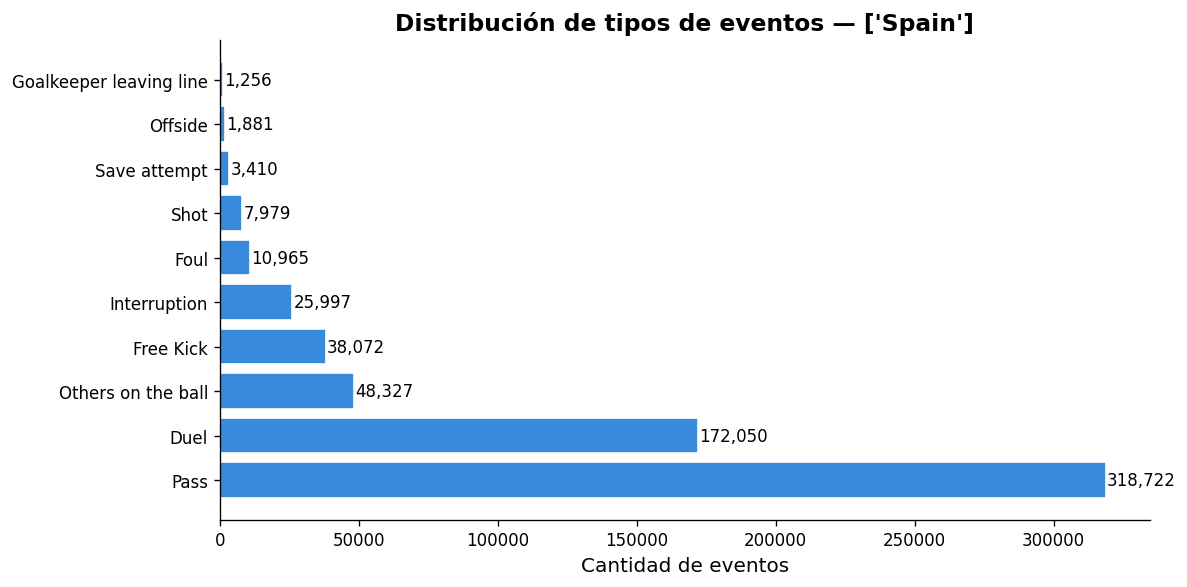

In [15]:
# Distribución de eventos
event_counts = df_events['eventName'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(event_counts.index, event_counts.values, color='#378ADD', edgecolor='white')
ax.set_xlabel('Cantidad de eventos', fontsize=12)
ax.set_title(f"Distribución de tipos de eventos — {competitions}", fontsize=14, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
for bar in bars:
    w = bar.get_width()
    ax.text(w + 500, bar.get_y() + bar.get_height()/2, f'{w:,}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

## 2. Shot Maps — Mapa de tiros

El shot map es una de las visualizaciones más icónicas del análisis de fútbol.
Muestra la ubicación de cada tiro, diferenciando goles de tiros sin gol.

In [16]:
# Filtramos tiros al arco
# 🔧 CAMBIO: sumamos también los tiros libres directos (eventName=='Free Kick',
#    subEventName=='Free kick shot'), que Wyscout clasifica aparte de 'Shot' y por
#    eso quedaban afuera. Esto es lo que hacía que is_direct_fk en compute_shot_features
#    nunca pudiera activarse (ver Sección 4) — el fix real estaba acá, no en esa función.
es_tiro_de_juego       = df_events['eventName'] == 'Shot'
es_tiro_libre_directo  = (df_events['eventName'] == 'Free Kick') & (df_events['subEventName'] == 'Free kick shot')

df_shots = df_events[es_tiro_de_juego | es_tiro_libre_directo].copy()

print(f'Total de tiros: {len(df_shots):,}')
print(f'  - De juego: {es_tiro_de_juego.sum():,}')
print(f'  - Tiros libres directos: {es_tiro_libre_directo.sum():,}')
print(f'Goles: {df_shots["is_goal"].sum():,}')
print(f'Tasa de conversión: {df_shots["is_goal"].mean():.1%}')

Total de tiros: 8,432
  - De juego: 7,979
  - Tiros libres directos: 453
Goles: 912
Tasa de conversión: 10.8%


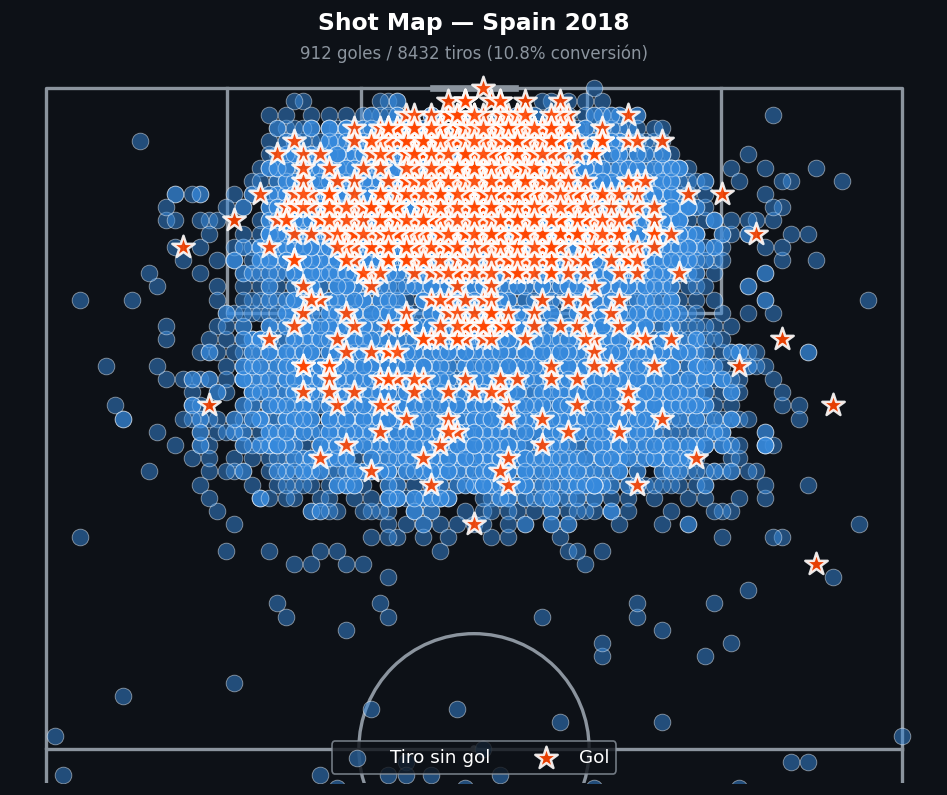

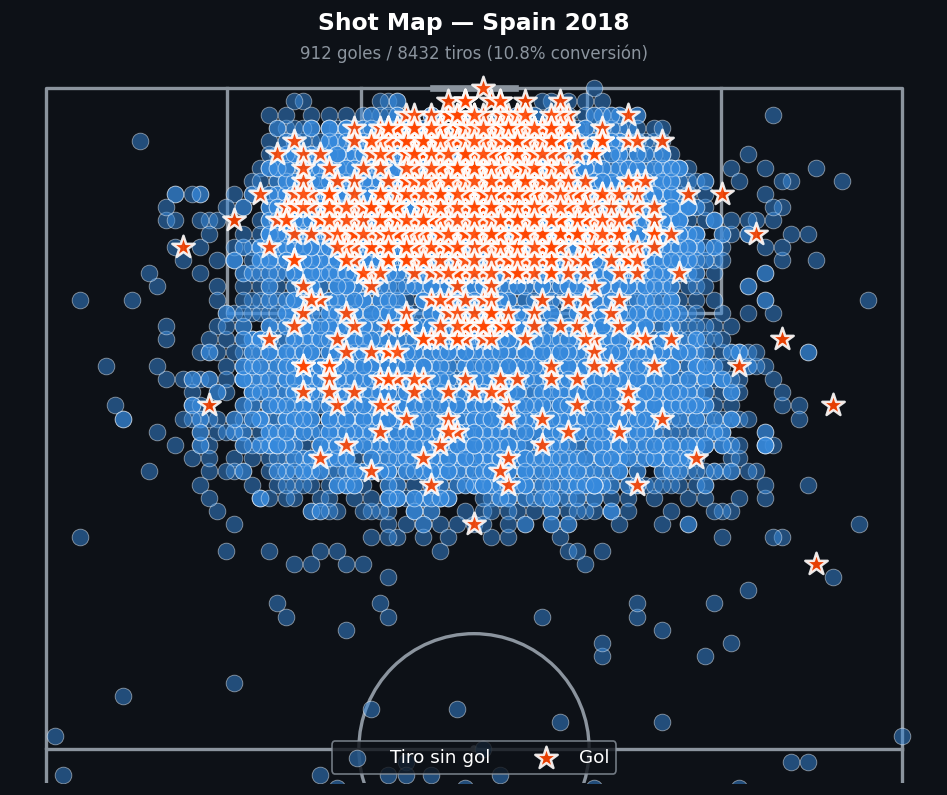

In [17]:
def plot_shot_map(df_shots, team_name=None, title=None):
    """
    Genera un shot map profesional con mplsoccer.
    
    Parámetros
    ----------
    df_shots  : DataFrame con columnas x_m, y_m, is_goal
    team_name : nombre del equipo (opcional, filtra)
    title     : título personalizado
    """
    data = df_shots.copy()
    if team_name:
        data = data[data['teamId'] == team_name]

    pitch = VerticalPitch(
        pitch_type='opta',
        pitch_color='#0d1117',
        line_color='#8b949e',
        half=True,
        line_zorder=2
    )
    fig, ax = pitch.draw(figsize=(8, 8), constrained_layout=True)
    fig.set_facecolor('#0d1117')

    # Tiros que no son gol
    no_goal = data[~data['is_goal']]
    pitch.scatter(
        no_goal['x'], no_goal['y'],
        s=100, alpha=0.5, edgecolors='white',
        linewidth=0.5, c='#378ADD', ax=ax, zorder=3,
        label='Tiro sin gol'
    )

    # Goles
    goals = data[data['is_goal']]
    pitch.scatter(
        goals['x'], goals['y'],
        s=200, alpha=0.9, edgecolors='white',
        linewidth=1.5, c='#FF4500', marker='*', ax=ax, zorder=4,
        label='Gol'
    )

    ax.legend(
        loc='lower center', ncol=2, fontsize=11,
        facecolor='#0d1117', edgecolor='#8b949e', labelcolor='white'
    )
    _title = title or f'Shot Map — {team_name or "Liga completa"}'
    ax.set_title(_title, color='white', fontsize=14, fontweight='bold', pad=15)
    ax.text(
        50, 102,
        f'{len(goals)} goles / {len(data)} tiros ({len(goals)/max(len(data),1):.1%} conversión)',
        ha='center', va='bottom', color='#8b949e', fontsize=10
    )

    plt.show()
    return fig

# Visualizamos la liga completa
plot_shot_map(df_shots, title=f"Shot Map — {competition} 2018")

## 3. Heat Maps — Densidad de acciones

Los heat maps permiten ver dónde en el campo ocurren más acciones de un tipo determinado.

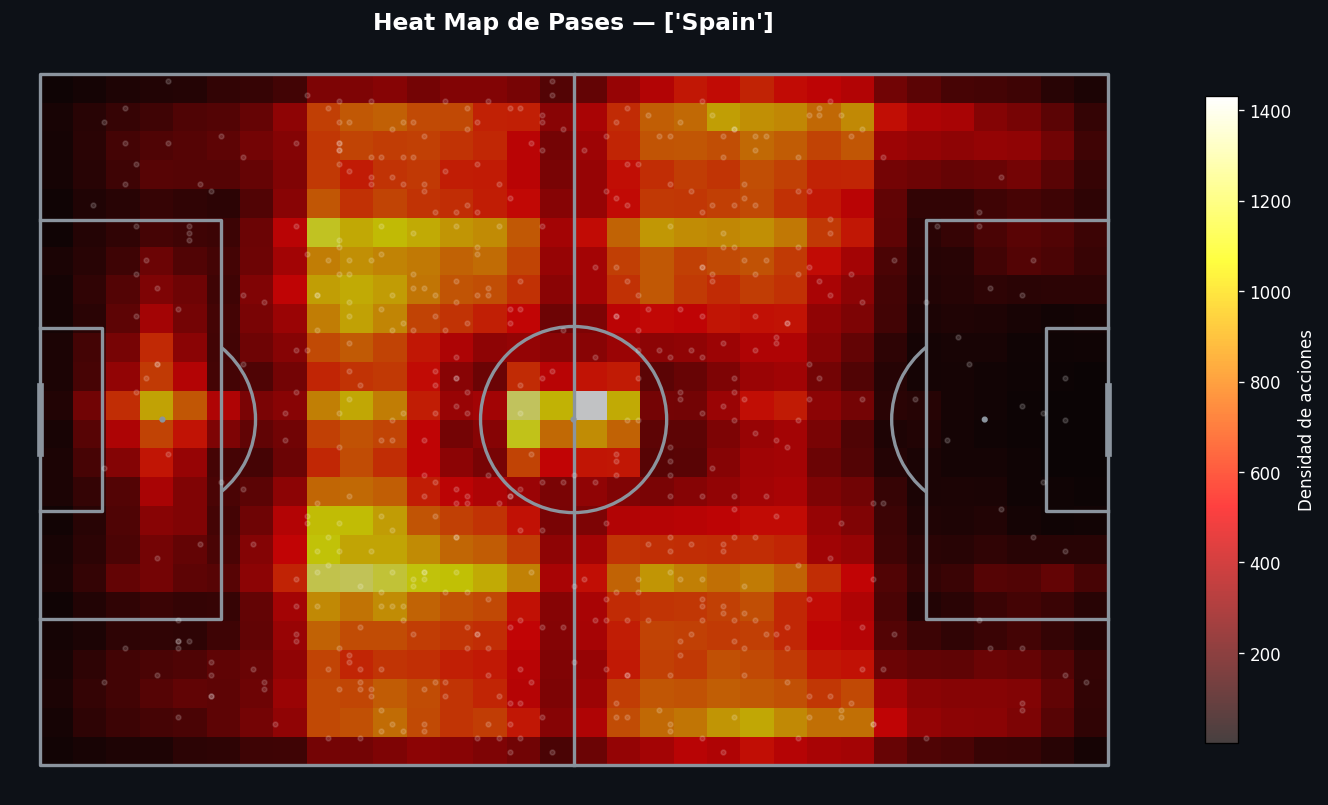

In [18]:
def plot_heatmap(df, event_type='Pass', team_id=None, cmap='hot', title=None):
    """
    Genera heat map por densidad de acciones (conteo binned en grilla).
    """
    data = df[df['eventName'] == event_type].copy()
    if team_id:
        data = data[data['teamId'] == team_id]
    data = data.dropna(subset=['x', 'y'])

    pitch = Pitch(
        pitch_type='opta',
        pitch_color='#0d1117',
        line_color='#8b949e',
        line_zorder=2
    )
    fig, ax = pitch.draw(figsize=(12, 8))
    fig.set_facecolor('#0d1117')

    # KDE a través de mplsoccer (gestiona bien el campo)
    bs = pitch.bin_statistic(
        data['x'], data['y'], statistic='count', bins=(32, 24)
    )
    heatmap = pitch.heatmap(bs, ax=ax, cmap=cmap, edgecolors='none', alpha=0.75)
    pitch.scatter(
        data['x'].sample(min(500, len(data))), 
        data['y'].sample(min(500, len(data))),
        s=8, alpha=0.15, color='white', ax=ax, zorder=5
    )

    cbar = fig.colorbar(heatmap, ax=ax, shrink=0.7)
    cbar.set_label('Densidad de acciones', color='white')
    cbar.ax.yaxis.set_tick_params(color='white')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

    _title = title or f'Heat Map — {event_type}'
    ax.set_title(_title, color='white', fontsize=14, fontweight='bold', pad=10)
    plt.tight_layout()
    plt.show()

plot_heatmap(df_events, event_type='Pass', title=f"Heat Map de Pases — {competitions}")

Extraigo todos los equipos únicos de los partidos en df_matches

In [19]:
all_team_ids = set()

for teams_data in df_matches['teamsData']:
    all_team_ids.update(teams_data.keys())

df_team_ids = pd.DataFrame(
    {'team_id': sorted(map(int, all_team_ids))}
)

df_team_ids = (
    df_team_ids
    .merge(
        teams[['wyId', 'name']],
        left_on='team_id',
        right_on='wyId',
        how='left'
    )
    .drop(columns='wyId')
)

df_team_ids

,team_id,name
0,674,Valencia
1,675,Real Madrid
2,676,Barcelona
3,677,Deportivo La Coruña
4,678,Athletic Club
5,679,Atlético Madrid
6,680,Sevilla
7,682,Villarreal
8,683,Málaga
9,684,Real Betis


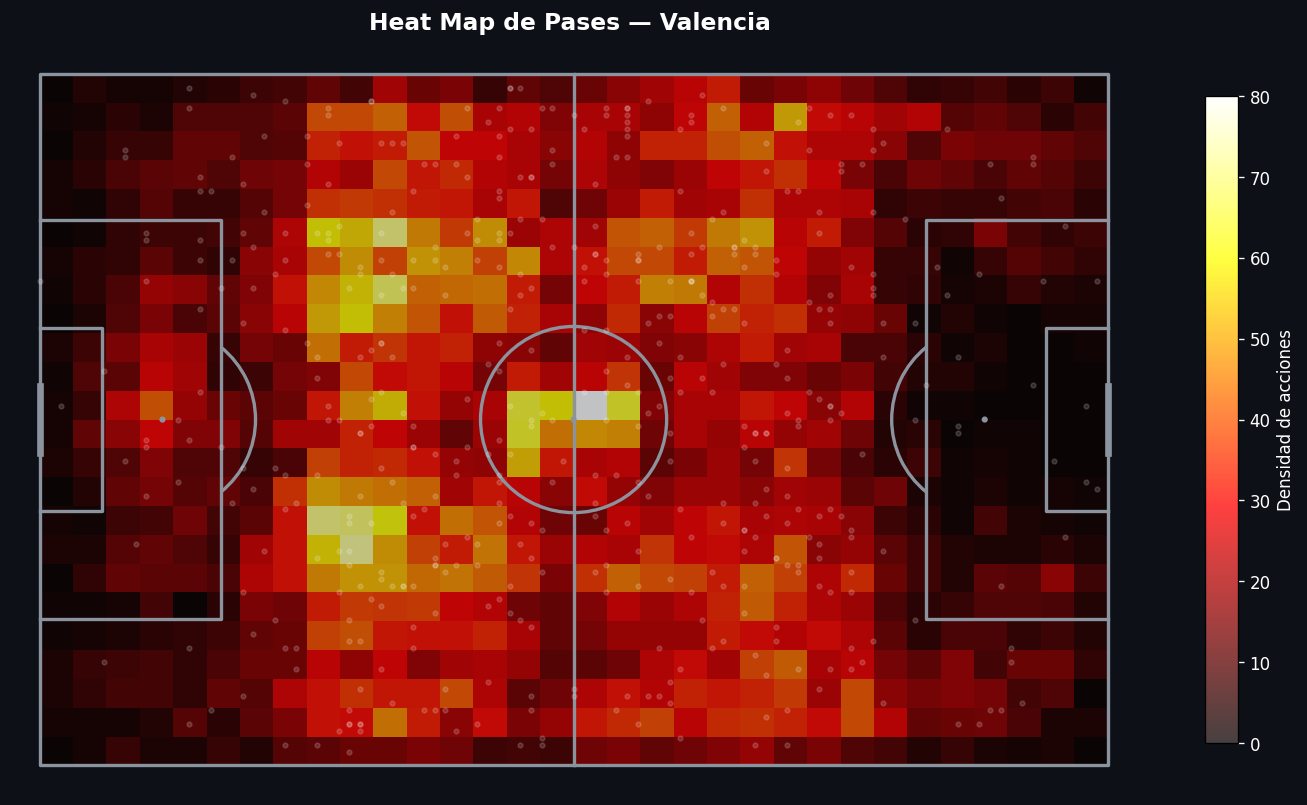

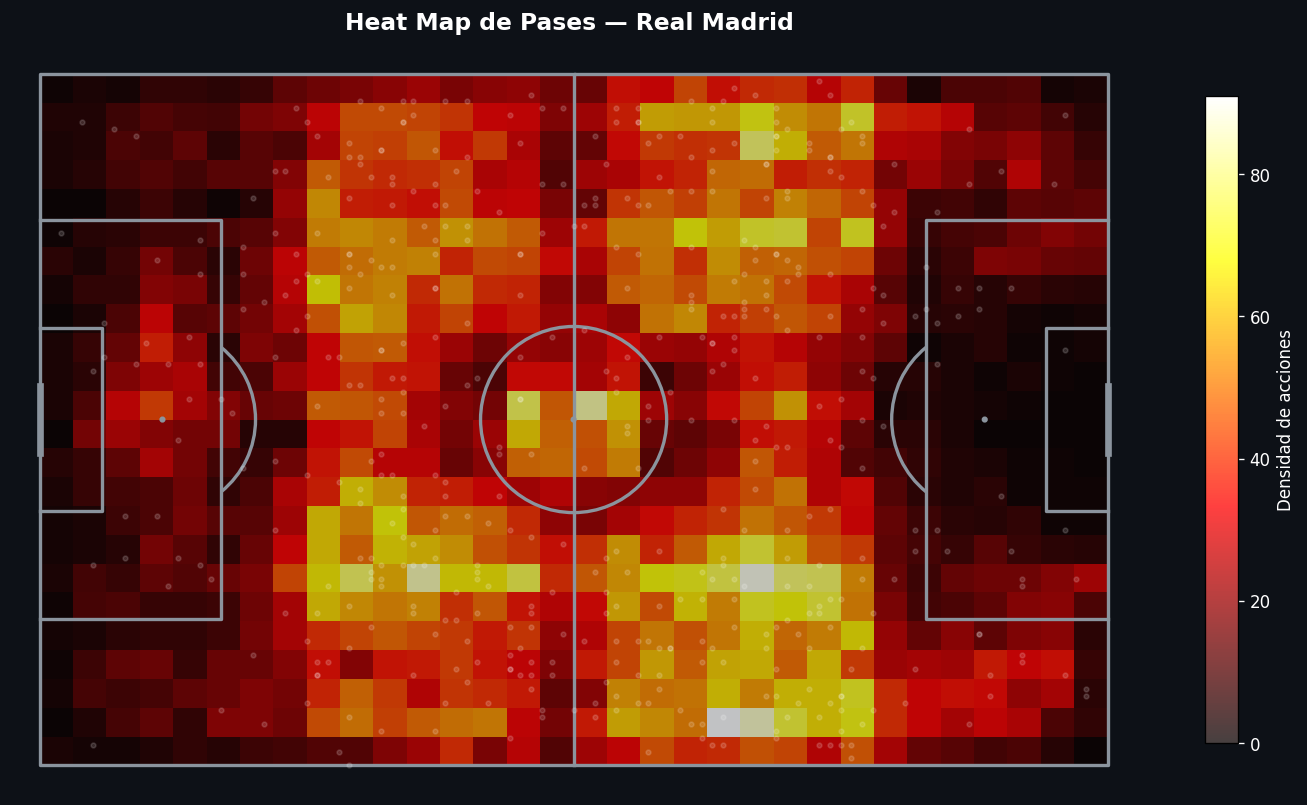

In [20]:
plot_heatmap(df_events, event_type='Pass', team_id=df_team_ids.loc[0,'team_id'], title=f"Heat Map de Pases — {df_team_ids.loc[0,'name']} ")
plot_heatmap(df_events, event_type='Pass', team_id=df_team_ids.loc[1,'team_id'], title=f"Heat Map de Pases — {df_team_ids.loc[1,'name']} ")

## 4. Expected Goals (xG)

xG es la métrica central del análisis moderno. Estima la probabilidad de que un tiro
se convierta en gol basándose en la posición y otras características.

Vamos a implementar un modelo xG simple usando regresión logística.

In [ ]:
# Se incorporan correcciones en el código, x consejo del Claudio.

def compute_shot_features(df_shots):
    """
    Computa features geométricas para el modelo xG.
    Referencia: Caley (2013), Lucey et al. (2014)
    """
    df = df_shots.copy()

    # Coordenadas en metros (campo 105x68)
    # En Wyscout, el arco atacante está en x=100
    df['dist_goal'] = np.sqrt(
        ((100 - df['x']) / 100 * 105) ** 2 +
        ((50 - df['y'])  / 100 * 68)  ** 2
    )

    # Ángulo al arco (radianes → grados)
    # 🔧 CAMBIO: postes recalculados para dar el ancho reglamentario exacto (7.32m).
    #    Los valores originales (44.2 / 55.8) daban 7.89m, ~7.8% de más.
    post_left  = 44.62
    post_right = 55.38

    # 🔧 CAMBIO: convertimos x, y y los postes a metros ANTES de calcular a, b, c.
    #    Antes se mezclaban unidades del eje x (0-100 = 105m) con las del eje y (0-100 = 68m)
    #    como si fueran la misma escala. Verificado empíricamente: esto distorsionaba
    #    angle_goal hasta un 33% en tiros cerca y centrados (justamente los de mayor xG).
    x_m = df['x'] / 100 * 105
    y_m = df['y'] / 100 * 68
    post_left_m  = post_left  / 100 * 68
    post_right_m = post_right / 100 * 68

    a = np.sqrt((105 - x_m) ** 2 + (post_left_m  - y_m) ** 2)
    b = np.sqrt((105 - x_m) ** 2 + (post_right_m - y_m) ** 2)
    c = post_right_m - post_left_m  # ancho del arco, ahora en metros

    # Ley del coseno (la fórmula en sí no cambia, solo las unidades que recibe)
    cos_angle = (a ** 2 + b ** 2 - c ** 2) / (2 * a * b + 1e-9)
    df['angle_goal'] = np.degrees(np.arccos(cos_angle.clip(-1, 1)))

    # 🔧 CAMBIO: is_head ahora usa el tag real de Wyscout (403 = head/body, confirmado
    #    en tags2name.csv) en vez de buscar "head" en subEventName. Para eventName=='Shot',
    #    subEventName vale siempre literalmente "Shot" — la versión original nunca
    #    matcheaba nada (columna constante en 0, coeficiente 0.0000 en el modelo).
    #    Requiere que df_shots tenga la columna 'tag_ids' (se arma en la Sección 1.4).
    df['is_head'] = df['tag_ids'].apply(lambda t: 403 in t).astype(int)

    # ✅ Antes dependía de que df_shots incluyera los tiros libres directos (ver Sección 2,
    #    corregido). Ahora sí detecta señal real.
    df['is_direct_fk'] = df['subEventName'].str.lower().str.contains('free kick', na=False).astype(int)

    return df


df_shots_fe = compute_shot_features(df_shots.dropna(subset=['x', 'y']))

features = ['dist_goal', 'angle_goal', 'is_head', 'is_direct_fk']
X = df_shots_fe[features].fillna(0).values
y = df_shots_fe['is_goal'].astype(int).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Modelo de regresión logística (baseline xG)
model_xg = LogisticRegression(max_iter=1000, C=0.5)
auc_scores = cross_val_score(model_xg, X_scaled, y, cv=5, scoring='roc_auc')
model_xg.fit(X_scaled, y)
df_shots_fe['xG'] = model_xg.predict_proba(X_scaled)[:, 1]

print(f'AUC (5-fold CV): {auc_scores.mean():.4f} ± {auc_scores.std():.4f}')
print(f'Brier Score: {brier_score_loss(y, df_shots_fe["xG"]):.4f}')
print(f'\nTotal xG en la liga: {df_shots_fe["xG"].sum():.1f}')
print(f'Goles reales: {y.sum()}')

AUC (5-fold CV): 0.7782 ± 0.0106
Brier Score: 0.0835

Total xG en la liga: 911.4
Goles reales: 912


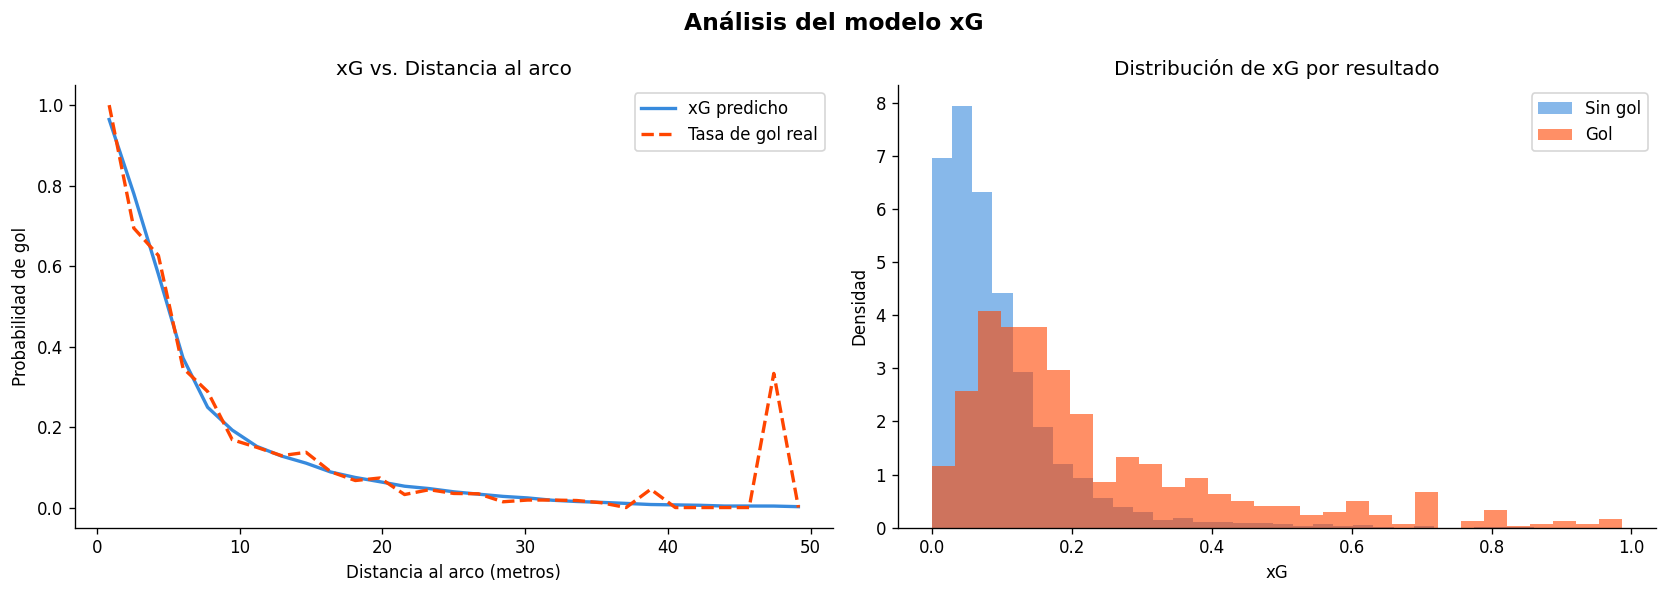

In [22]:
# Visualización: xG vs distancia al arco
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Análisis del modelo xG', fontsize=14, fontweight='bold')

# Panel izq: xG vs distancia
ax = axes[0]
# Curva promedio
dist_bins = np.linspace(0, 50, 30)
df_shots_fe['dist_bin'] = pd.cut(df_shots_fe['dist_goal'], bins=dist_bins)
avg_xg = df_shots_fe.groupby('dist_bin')['xG'].mean()
avg_goal = df_shots_fe.groupby('dist_bin')['is_goal'].mean()
bin_centers = [i.mid for i in avg_xg.index]

ax.plot(bin_centers, avg_xg.values, color='#378ADD', linewidth=2, label='xG predicho')
ax.plot(bin_centers, avg_goal.values, color='#FF4500', linewidth=2, linestyle='--', label='Tasa de gol real')
ax.set_xlabel('Distancia al arco (metros)')
ax.set_ylabel('Probabilidad de gol')
ax.set_title('xG vs. Distancia al arco')
ax.legend()
ax.spines[['top','right']].set_visible(False)

# Panel der: distribución de xG por categoría
ax2 = axes[1]
for is_goal, label, color in [(0, 'Sin gol', '#378ADD'), (1, 'Gol', '#FF4500')]:
    vals = df_shots_fe.loc[df_shots_fe['is_goal'] == is_goal, 'xG']
    ax2.hist(vals, bins=30, alpha=0.6, label=label, color=color, density=True)
ax2.set_xlabel('xG')
ax2.set_ylabel('Densidad')
ax2.set_title('Distribución de xG por resultado')
ax2.legend()
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

In [24]:
def plot_passing_network(nodes, edges, players_df=None, title='Red de Pases'):
    """
    Visualiza la red de pases sobre el campo.
    """
    pitch = Pitch(
        pitch_type='opta', pitch_color='#1a472a',
        line_color='#ffffff', line_zorder=2
    )
    fig, ax = pitch.draw(figsize=(14, 9))
    fig.set_facecolor('#0d1117')

    max_count = edges['count'].max() if len(edges) > 0 else 1
    for _, edge in edges.iterrows():
        src = nodes[nodes['playerId'] == edge['playerId']]
        dst = nodes[nodes['playerId'] == edge['next_player']]
        if src.empty or dst.empty:
            continue
        alpha = 0.3 + 0.6 * (edge['count'] / max_count)
        lw = 1 + 4 * (edge['count'] / max_count)
        ax.plot(
            [src['x'].values[0], dst['x'].values[0]],
            [src['y'].values[0], dst['y'].values[0]],
            color='white', alpha=alpha, linewidth=lw, zorder=3
        )

    max_passes = nodes['passes_made'].max() if len(nodes) > 0 else 1
    scatter_size = 200 + 800 * (nodes['passes_made'] / max_passes)
    sc = pitch.scatter(
        nodes['x'], nodes['y'],
        s=scatter_size, c=nodes['passes_made'], cmap='YlOrRd',
        edgecolors='white', linewidth=1.5, ax=ax, zorder=5
    )

    # Etiquetas con el nombre de cada jugador
    if players_df is not None:
        nombres = players_df.set_index('wyId')['shortName']
        for _, node in nodes.iterrows():
            nombre = nombres.get(node['playerId'], str(int(node['playerId'])))
            ax.annotate(
                nombre,
                xy=(node['x'], node['y']),
                xytext=(0, 12), textcoords='offset points',
                ha='center', va='center',
                color='white', fontsize=8, fontweight='bold',
                path_effects=[pe.withStroke(linewidth=2, foreground='#0d1117')],
                zorder=6
            )

    plt.colorbar(sc, ax=ax, label='Pases realizados', shrink=0.6)
    ax.set_title(title, color='white', fontsize=14, fontweight='bold', pad=12)
    plt.tight_layout()
    plt.show()

In [25]:
# Filtramos goles convertidos desde más de 40 metros, con la variable is_direct_fk
# para distinguir tiro libre de jugada abierta (sin excluir ninguno de los dos tipos)
tiros_lejanos_gol = df_shots_fe[
    (df_shots_fe['dist_goal'] > 40) &
    (df_shots_fe['is_goal'] == True)
].copy()

# Le sumamos el nombre del jugador para que sea legible
tiros_lejanos_gol = tiros_lejanos_gol.merge(
    players[['wyId', 'shortName']],
    left_on='playerId', right_on='wyId', how='left'
).drop(columns='wyId')

print(f'Total de goles desde más de 40 metros: {len(tiros_lejanos_gol)}')
print(f'  - Tiro libre directo: {tiros_lejanos_gol["is_direct_fk"].sum()}')
print(f'  - De juego (no tiro libre): {(tiros_lejanos_gol["is_direct_fk"] == 0).sum()}')

tiros_lejanos_gol[
    ['shortName', 'matchId', 'dist_goal', 'angle_goal', 'is_direct_fk', 'is_head']
].sort_values('dist_goal', ascending=False)

Total de goles desde más de 40 metros: 2
  - Tiro libre directo: 1
  - De juego (no tiro libre): 1


,shortName,matchId,dist_goal,angle_goal,is_direct_fk,is_head
1,Pablo Sarabia,2565775,103.952224,4.031081,0,0
0,P. Sisto,2565606,46.569088,7.312429,1,0


## 5. Redes de Pases (Passing Networks)

Las redes de pases muestran cómo circula el balón entre los jugadores de un equipo.
Son una herramienta central para el análisis táctico moderno.

In [26]:
def build_passing_network(df_events, match_id, team_id):
    """
    Construye una red de pases para un partido y equipo específicos.
    Retorna nodos (posición media) y aristas (conexiones de pase).
    """
    # 🔧 CAMBIO: partimos de TODOS los eventos del partido (no solo los pases del equipo),
    #    ordenados cronológicamente, para poder detectar si hubo una pérdida de posesión
    #    real entre un pase y el siguiente. Antes se filtraba a pases del equipo ANTES de
    #    calcular "next_player", lo que hacía que el código saltara por encima de duelos,
    #    regates, y recuperaciones del rival, conectando jugadores que en realidad no se
    #    pasaron la pelota directamente.
    df_match_all = df_events[df_events['matchId'] == match_id].sort_values(
        ['matchPeriod', 'eventSec']
    ).reset_index(drop=True)

    df_match_all['next_player'] = df_match_all['playerId'].shift(-1)
    df_match_all['next_teamId'] = df_match_all['teamId'].shift(-1)

    # Ahora sí filtramos a los pases del equipo, pero ya con el contexto del
    # "próximo evento real" calculado sobre el partido completo.
    mask = (df_match_all['teamId'] == team_id) & (df_match_all['eventName'] == 'Pass')
    df_match_passes = df_match_all[mask].copy()

    # Posición media de cada jugador (nodo) — sin cambios
    nodes = df_match_passes.groupby('playerId').agg(
        x=('x', 'mean'),
        y=('y', 'mean'),
        passes_made=('eventId', 'count')
    ).reset_index()

    # 🔧 CAMBIO: solo contamos una conexión si el evento inmediato siguiente (de cualquier
    #    tipo, no solo pase) es del MISMO equipo — es decir, sin pérdida de posesión en el
    #    medio. Verificado empíricamente con un partido real: ~23% de los pases de un
    #    equipo terminan en pérdida inmediata, y el método anterior generaba ~24% de
    #    aristas espurias por ignorar justamente esos casos.
    sin_perdida = df_match_passes['next_teamId'] == team_id
    edges = df_match_passes[sin_perdida].groupby(
        ['playerId', 'next_player']
    ).size().reset_index(name='count')

    # Solo aristas con al menos 3 pases (sin cambios)
    edges = edges[edges['count'] >= 3]
    return nodes, edges

In [27]:
# Ejemplo de uso 
print('Primeros partidos disponibles:')
print(df_matches[['wyId','label']].head(5))

Primeros partidos disponibles:
      wyId                                  label
0  2565922       Barcelona - Real Sociedad, 1 - 0
1  2565925         Atlético Madrid - Eibar, 2 - 2
2  2565919        Athletic Club - Espanyol, 0 - 1
3  2565924  Valencia - Deportivo La Coruña, 2 - 1
4  2565927        Villarreal - Real Madrid, 2 - 2


Nodos: 14, Aristas (≥3 pases): 68


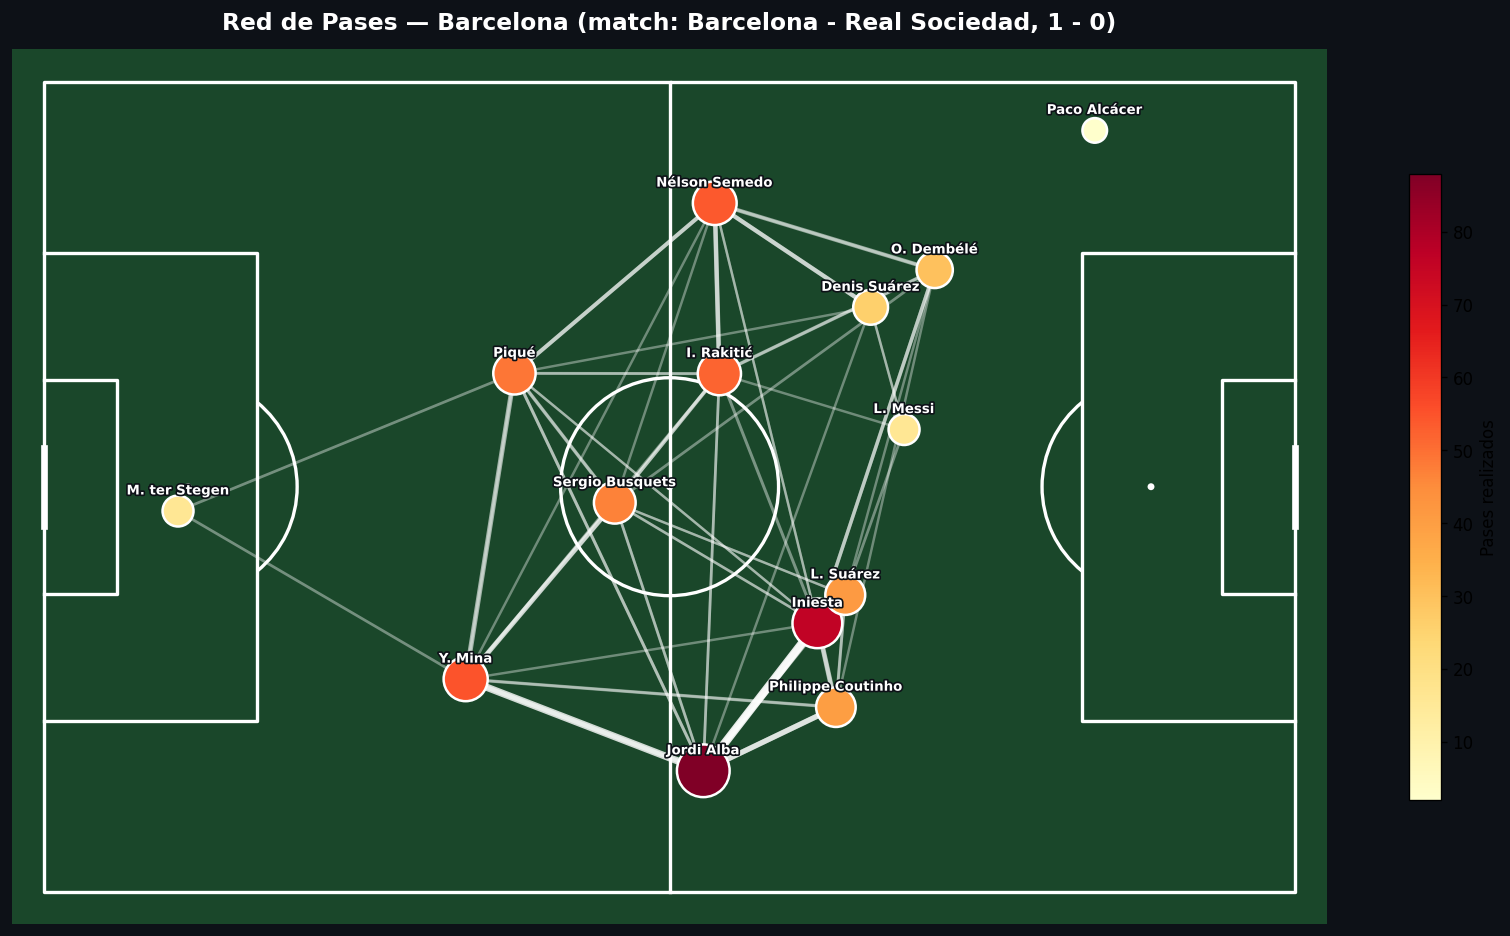

In [28]:
# Seleccionamos el primer partido disponible
first_match_id = df_matches['wyId'].iloc[0]

# Encontramos los dos equipos del partido
teams_in_match = df_events[
    df_events['matchId'] == first_match_id
]['teamId'].unique()

if len(teams_in_match) >= 1:
    team_id = teams_in_match[1]
    team_name = teams[teams['wyId'] == team_id]['name'].values
    team_name = team_name[0] if len(team_name) else str(team_id)
    legend = df_matches.loc[df_matches['wyId']==first_match_id,'label'].iat[0]
    nodes, edges = build_passing_network(df_events, first_match_id, team_id)
    print(f'Nodos: {len(nodes)}, Aristas (≥3 pases): {len(edges)}')

    plot_passing_network(
        nodes, edges, players_df=players,
        title=f'Red de Pases — {team_name} (match: {legend})'
    )

In [29]:
# Ver algunas estadísticas para obtener otras estadísticas relevantes

players_lookup = players.set_index('wyId')

def resumen_red(nodes, edges):
    """
    Arma una tabla resumen de la red de pases: nombre, rol, pases dados/recibidos
    y cantidad de conexiones distintas (≥3 pases) por jugador.
    """
    tabla = nodes.copy()
    tabla['nombre'] = tabla['playerId'].map(players_lookup['shortName'])
    tabla['rol'] = tabla['playerId'].map(
        lambda pid: players_lookup.loc[pid, 'role']['code3'] if pid in players_lookup.index else None
    )

    # Pases recibidos: sumamos el 'count' de las aristas donde el jugador es el receptor (next_player)
    recibidos = edges.groupby('next_player')['count'].sum().rename('pases_recibidos')
    tabla = tabla.merge(recibidos, left_on='playerId', right_index=True, how='left')
    tabla['pases_recibidos'] = tabla['pases_recibidos'].fillna(0).astype(int)

    # Grado: con cuántos compañeros distintos conecta (dando o recibiendo, con >=3 pases)
    conex_dadas = edges.groupby('playerId')['next_player'].nunique()
    conex_recib = edges.groupby('next_player')['playerId'].nunique()
    tabla['conexiones_distintas'] = (
        tabla['playerId'].map(conex_dadas).fillna(0) + tabla['playerId'].map(conex_recib).fillna(0)
    ).astype(int)

    return tabla[
        ['playerId', 'nombre', 'rol', 'passes_made', 'pases_recibidos', 'conexiones_distintas', 'x', 'y']
    ].sort_values('passes_made', ascending=False)


tabla_red = resumen_red(nodes, edges)
tabla_red

,playerId,nombre,rol,passes_made,pases_recibidos,conexiones_distintas,x,y
0,3269,Jordi Alba,DEF,88,66,15,52.693182,14.920455
4,3353,Iniesta,MID,76,59,16,61.815789,33.131579
12,256634,Y. Mina,DEF,55,42,12,33.690909,26.236364
11,222770,Nélson Semedo,DEF,54,39,12,53.611111,85.018519
6,3476,I. Rakitić,MID,52,36,13,53.980769,63.961538
2,3341,Piqué,DEF,49,35,14,37.591837,64.000000
3,3346,Sergio Busquets,MID,47,35,14,45.617021,48.021277
8,7972,L. Suárez,FWD,41,29,10,64.048780,36.634146
7,3802,Philippe Coutinho,FWD,40,36,9,63.300000,22.775000
13,286390,O. Dembélé,FWD,30,30,9,71.200000,76.766667


## 6. Radar Charts — Comparación de jugadores

Los radares son la forma más usada para comparar perfiles de jugadores.
Vamos a crear radares con normalización por percentil respecto a la liga.

In [30]:
# 🆕 CELDA NUEVA: calculamos minutos jugados por jugador en toda la temporada,
#    a partir de las alineaciones y sustituciones de matches.json (df_matches).
#    Sin esto no se puede normalizar nada "por 90 minutos".
def minutos_por_partido(teams_data, match_length=90):
    """Devuelve {playerId: minutos_jugados} para un partido, a partir de teamsData."""
    minutos = {}
    for team_id_str, team_info in teams_data.items():
        formation = team_info.get('formation', {})
        if not isinstance(formation, dict):
            continue
        lineup = formation.get('lineup', [])
        # ⚠️ En ~5 de 760 casos, 'substitutions' viene como el string "null" en vez de
        #    una lista vacía (inconsistencia del JSON fuente) — nos defendemos de eso.
        subs_raw = formation.get('substitutions', [])
        subs = sorted(subs_raw, key=lambda s: s['minute']) if isinstance(subs_raw, list) else []
        en_cancha_desde = {p['playerId']: 0 for p in lineup}
        for sub in subs:
            pid_out, pid_in, minute = sub['playerOut'], sub['playerIn'], sub['minute']
            if pid_out in en_cancha_desde:
                minutos[pid_out] = minutos.get(pid_out, 0) + (minute - en_cancha_desde[pid_out])
                del en_cancha_desde[pid_out]
            en_cancha_desde[pid_in] = minute
        # Los que quedaron en cancha hasta el final del partido
        for pid, desde in en_cancha_desde.items():
            minutos[pid] = minutos.get(pid, 0) + (match_length - desde)
    return minutos

minutos_totales = {}
for _, row in df_matches.iterrows():
    for pid, mins in minutos_por_partido(row['teamsData']).items():
        minutos_totales[pid] = minutos_totales.get(pid, 0) + mins

df_minutos = pd.DataFrame(list(minutos_totales.items()), columns=['playerId', 'minutes_played'])
print(f'Jugadores con minutos calculados: {len(df_minutos)}')

Jugadores con minutos calculados: 557


In [31]:
def build_player_stats(df_events, players_df, df_minutos, df_shots_fe, min_minutes=500):
    """
    Agrega estadísticas por jugador para construir perfiles.
    Retorna estadísticas normalizadas por 90 minutos.
    """
    passes_df = df_events[df_events['eventName'] == 'Pass'].copy()
    passes_df['is_accurate'] = passes_df['tag_ids'].apply(lambda t: 1801 in t)
    passes = passes_df.groupby('playerId').agg(
        total_passes=('eventId', 'count'),
        passes_accurate=('is_accurate', 'sum')
    ).reset_index()

    shots = df_events[df_events['eventName'] == 'Shot'].groupby('playerId').agg(
        total_shots=('eventId', 'count'),
        total_goals=('is_goal', 'sum')
    ).reset_index()
    xg = df_shots_fe.groupby('playerId')['xG'].sum().reset_index().rename(columns={'xG': 'total_xg'})
    duels_all = df_events[df_events['eventName'] == 'Duel']
    duels_total = duels_all.groupby('playerId').agg(total_duels=('eventId', 'count')).reset_index()
    duels_won = duels_all[duels_all['tag_ids'].apply(lambda t: 703 in t)].groupby('playerId').agg(
        total_duels_won=('eventId', 'count')
    ).reset_index()
    set_pieces = df_events[df_events['eventName'] == 'Free Kick'].groupby('playerId').agg(
        set_pieces_taken=('eventId', 'count')
    ).reset_index()

    stats = passes
    for df_merge in [shots, xg, duels_total, duels_won, set_pieces]:
        stats = stats.merge(df_merge, on='playerId', how='outer')
    stats = stats.fillna(0)
    stats = stats.merge(df_minutos, on='playerId', how='inner')
    stats = stats.merge(
        players_df[['wyId', 'shortName']], left_on='playerId', right_on='wyId', how='inner'
    ).drop(columns='wyId')
    stats = stats[stats['minutes_played'] >= min_minutes].copy()

    stats['pct_passes_accurate'] = stats['passes_accurate'] / stats['total_passes'] * 100

    for col in ['total_passes', 'total_shots', 'total_goals', 'total_xg', 'total_duels', 'total_duels_won', 'set_pieces_taken']:
        stats[col.replace('total_', '') + '_p90'] = stats[col] / stats['minutes_played'] * 90
    return stats


player_stats = build_player_stats(df_events, players, df_minutos, df_shots_fe, min_minutes=500)
print(f'Jugadores con ≥500 minutos: {len(player_stats)}')
player_stats.head()

Jugadores con ≥500 minutos: 407


,playerId,total_passes,passes_accurate,total_shots,total_goals,total_xg,total_duels,total_duels_won,set_pieces_taken,minutes_played,shortName,pct_passes_accurate,passes_p90,shots_p90,goals_p90,xg_p90,duels_p90,duels_won_p90,set_pieces_taken_p90
2,151,360.0,266.0,29.0,3.0,3.151167,340.0,118.0,5.0,1340,J. Guidetti,73.888889,24.179104,1.947761,0.201493,0.211646,22.835821,7.925373,0.335821
3,254,1475.0,1132.0,14.0,1.0,0.609990,612.0,222.0,431.0,3125,R. Rosales,76.745763,42.480000,0.403200,0.028800,0.017568,17.625600,6.393600,12.412800
5,1751,207.0,163.0,12.0,0.0,0.977324,173.0,59.0,36.0,574,O. Tannane,78.743961,32.456446,1.881533,0.000000,0.153239,27.125436,9.250871,5.644599
6,3267,519.0,397.0,0.0,0.0,0.000000,17.0,15.0,408.0,2970,Guaita,76.493256,15.727273,0.000000,0.000000,0.000000,0.515152,0.454545,12.363636
7,3269,2089.0,1799.0,15.0,2.0,2.165956,417.0,149.0,287.0,2744,Jordi Alba,86.117760,68.516764,0.491983,0.065598,0.071041,13.677114,4.887026,9.413265


In [32]:
def plot_player_radar(player_stats_row, all_stats, player_name='Jugador'):
    """
    Genera un radar chart normalizado por percentil.
    """
    # 🔧 CAMBIO: usamos las columnas _p90 (ya normalizadas), no los totales crudos.
    params = ['passes_p90', 'shots_p90', 'goals_p90', 'duels_won_p90']
    labels = ['Pases/90', 'Tiros/90', 'Goles/90', 'Duelos ganados/90']

    # 🔧 CAMBIO: esto es lo que el docstring siempre dijo que hacía y antes no hacía.
    #    Convertimos el valor del jugador en su percentil real (0-100) dentro de la
    #    población, en vez de graficar el valor crudo con el eje recortado por percentil
    #    (que es una técnica distinta: recorte de rango, no normalización).
    values = [float((all_stats[p] < player_stats_row[p]).mean() * 100) for p in params]

    # Con valores ya en escala 0-100, los rangos del radar son fijos y comparables
    # entre cualquier estadística, sin importar su unidad original.
    radar = Radar(
        params=labels,
        min_range=[0, 0, 0, 0],
        max_range=[100, 100, 100, 100],
        num_rings=4,
        ring_width=1,
        center_circle_radius=1
    )
    fig, axs = radar.setup_axis()
    radar.draw_circles(ax=axs, facecolor='#28313D', edgecolor='#39485a')
    radar.draw_radar(
        values, ax=axs,
        kwargs_radar={'facecolor': '#378ADD', 'alpha': 0.6},
        kwargs_rings={'facecolor': '#378ADD', 'alpha': 0.3}
    )
    radar.draw_range_labels(ax=axs, fontsize=9, color='#8b949e')
    radar.draw_param_labels(ax=axs, fontsize=11, color='white')
    fig.patch.set_facecolor('#0d1117')
    axs.set_facecolor('#0d1117')
    axs.set_title(f'Radar — {player_name}', color='white', fontsize=14, fontweight='bold', pad=25)
    plt.tight_layout()
    plt.show()

In [33]:
# Arma una tabla chica de "Estadística / Valor" a partir de una lista de columnas —
# reutilizable tanto para el pasador como para el rematador.
def tabla_estadisticas(player_row, specs):
    """
    specs: lista de (columna, etiqueta, formato). Ej: ('total_passes', 'Total de pases', '{:.0f}')
    """
    filas = [(etiqueta, fmt.format(player_row[col])) for col, etiqueta, fmt in specs]
    return pd.DataFrame(filas, columns=['Estadística', 'Valor'])

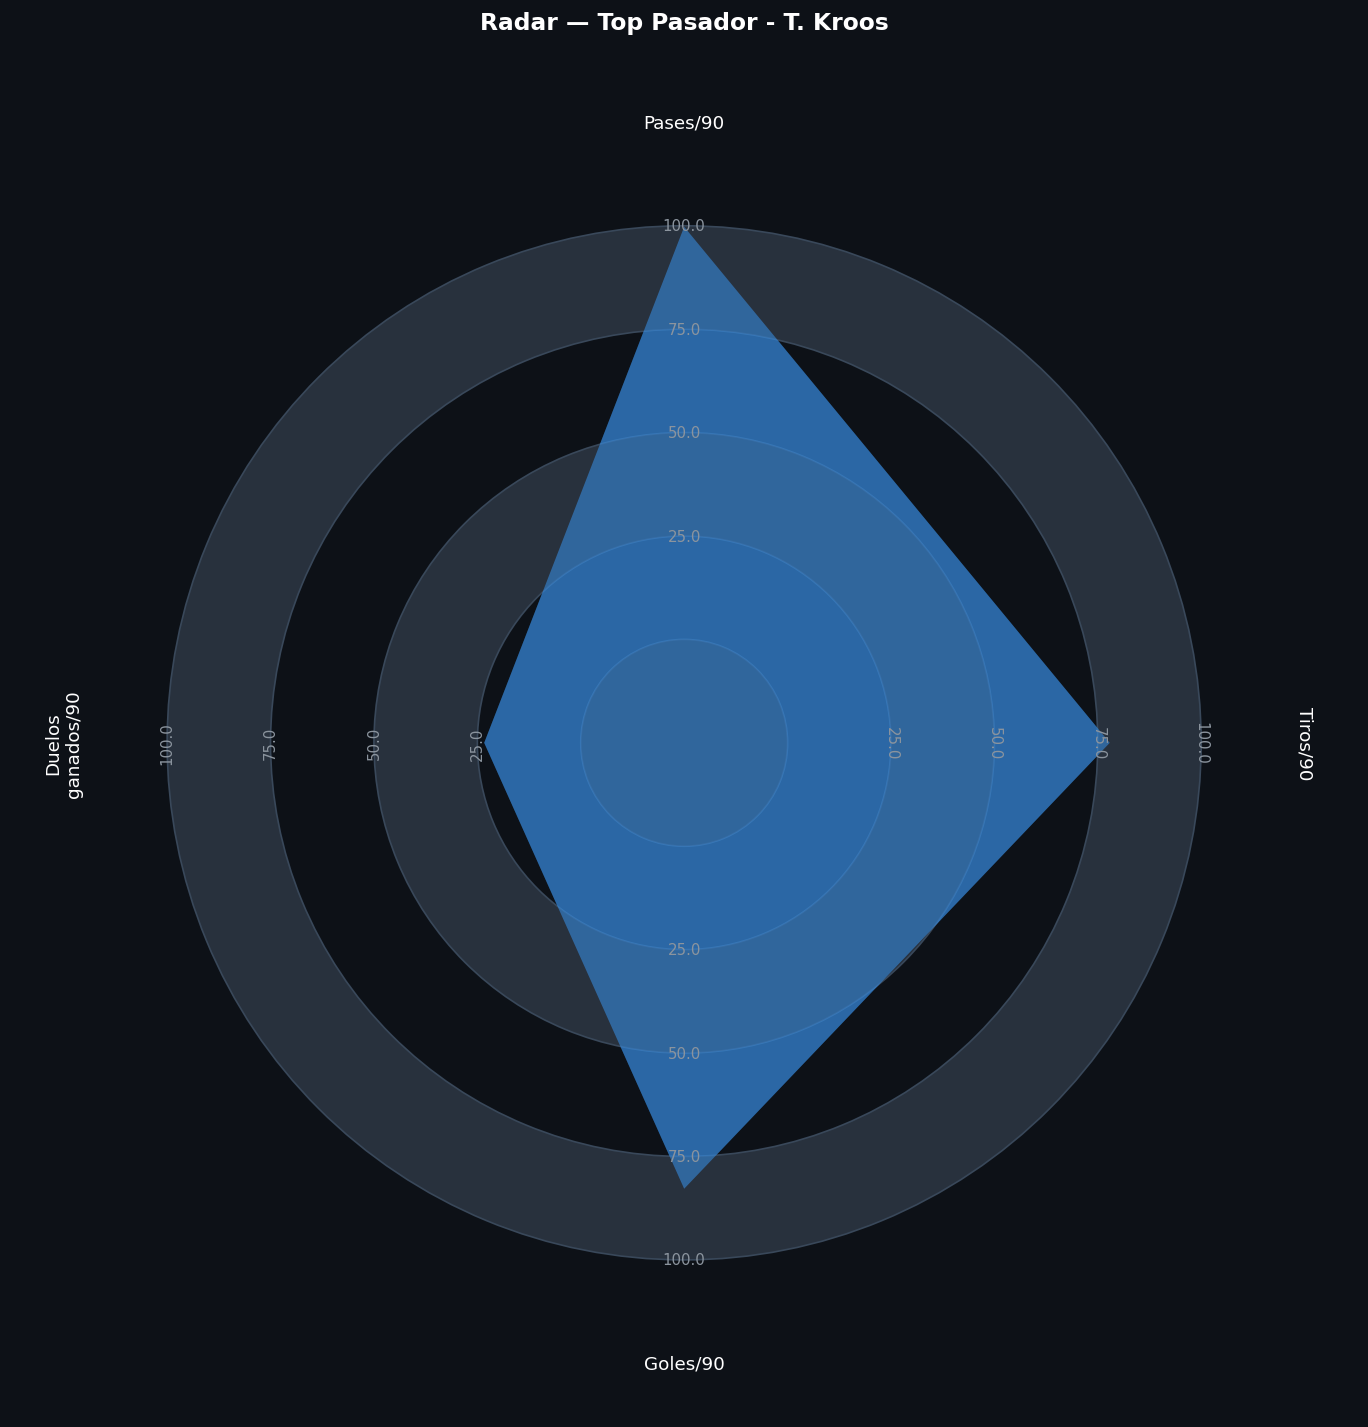

Estadísticas de T. Kroos:


,Estadística,Valor
0,Total de pases,1958
1,Pases cada 90 min,77.7
2,% de pases correctos,93.7%


In [34]:
# Ejemplo: jugador con más pases por 90 min en la liga (mínimo 500 min jugados)
# 🔧 CAMBIO: ordenamos por passes_p90 (tasa), no total_passes (volumen crudo que
#    favorece a quien jugó más partidos, no a quien más pasa por minuto).
top_passer = player_stats.sort_values('passes_p90', ascending=False).iloc[0]
player_name = players.loc[players['wyId'] == int(top_passer['playerId']), 'shortName'].iloc[0]
plot_player_radar(top_passer, player_stats, player_name=f"Top Pasador - {player_name}")

tabla_pasador = tabla_estadisticas(top_passer, [
    ('total_passes', 'Total de pases',       '{:.0f}'),
    ('passes_p90',   'Pases cada 90 min',    '{:.1f}'),
    ('pct_passes_accurate', '% de pases correctos', '{:.1f}%'),
])
print(f'Estadísticas de {player_name}:')
tabla_pasador

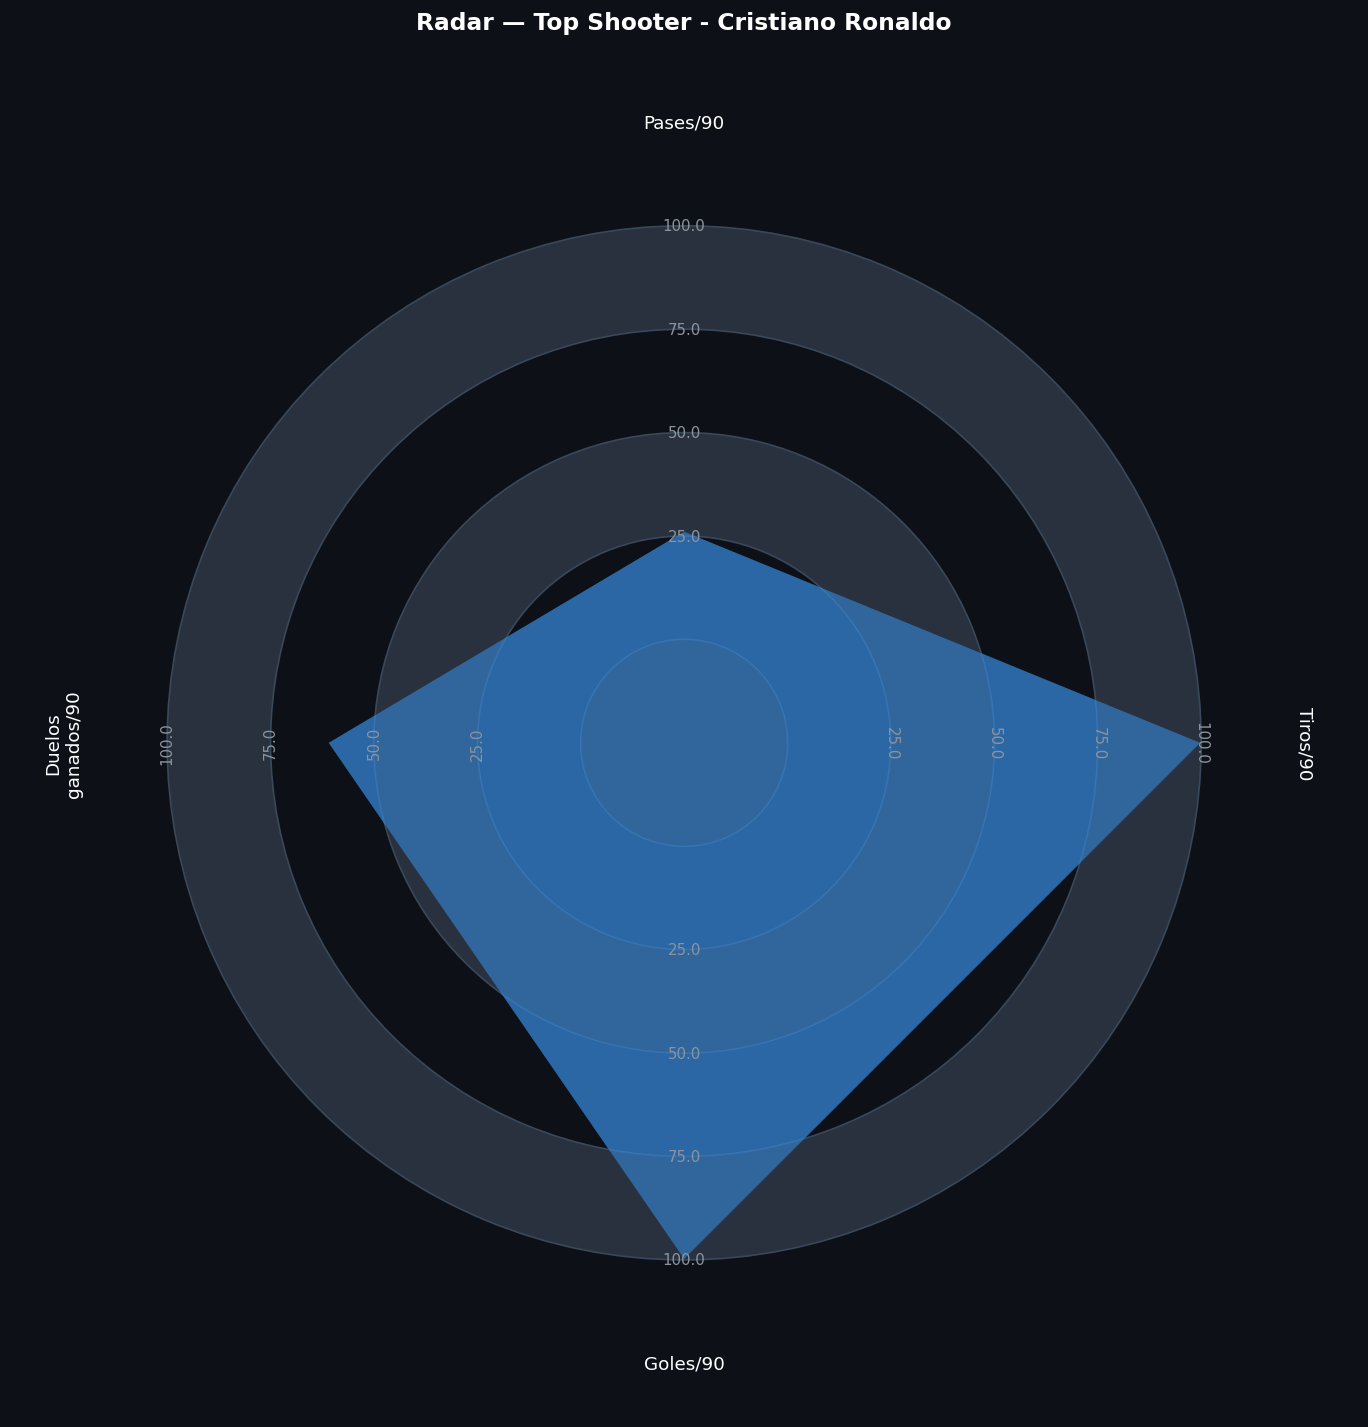

Estadísticas de Cristiano Ronaldo:


,Estadística,Valor
0,Total de remates,151
1,Remates cada 90 min,5.92
2,Total de goles,23
3,Goles cada 90 min,0.90
4,xG total,24.27
5,xG cada 90 min,0.95


In [35]:
# Ejemplo: jugador con más tiros por 90 min en la liga (mínimo 500 min jugados)
top_shooter = player_stats.sort_values('shots_p90', ascending=False).iloc[0]
player_name = players.loc[players['wyId'] == int(top_shooter['playerId']), 'shortName'].iloc[0]
plot_player_radar(top_shooter, player_stats, player_name=f"Top Shooter - {player_name}")

tabla_rematador = tabla_estadisticas(top_shooter, [
    ('total_shots', 'Total de remates',    '{:.0f}'),
    ('shots_p90',   'Remates cada 90 min', '{:.2f}'),
    ('total_goals', 'Total de goles',      '{:.0f}'),
    ('goals_p90',   'Goles cada 90 min',   '{:.2f}'),
    ('total_xg',    'xG total',            '{:.2f}'),
    ('xg_p90',      'xG cada 90 min',      '{:.2f}'),
])
print(f'Estadísticas de {player_name}:')
tabla_rematador

## 7. Progressive Passes — Pases Progresivos

Un pase progresivo es aquel que avanza el balón significativamente hacia el arco rival.
La definición estándar (Wyscout/StatsBomb): pases que reducen la distancia al arco en al menos un 25%.

In [36]:
def is_progressive_pass(row, threshold=0.25):
    """
    Determina si un pase es progresivo.
    Definición: reduce la distancia al arco rival en ≥25%, iniciando en campo rival.
    """
    if pd.isna(row['x']) or pd.isna(row['end_x']):
        return False

    # Convertimos a metros antes de calcular distancias — mezclar el eje x (0-100=105m)
    # con el eje y (0-100=68m) sin convertir distorsiona la clasificación (verificado:
    # 5.7% de los pases cambiaban de progresivo/no progresivo entre ambos métodos).
    x_m, y_m = row['x'] / 100 * 105, row['y'] / 100 * 68
    end_x_m, end_y_m = row['end_x'] / 100 * 105, row['end_y'] / 100 * 68
    dist_start = np.sqrt((105 - x_m) ** 2 + (34 - y_m) ** 2)
    dist_end   = np.sqrt((105 - end_x_m) ** 2 + (34 - end_y_m) ** 2)

    # x > 50 = campo rival de verdad (antes era x > 30, que incluía campo propio).
    return (dist_end < dist_start * (1 - threshold)) and (row['x'] > 50)

In [37]:
df_passes = df_events[
    (df_events['eventName'] == 'Pass') &
    df_events['end_x'].notna()
].copy()
df_passes['is_progressive'] = df_passes.apply(is_progressive_pass, axis=1)
prog_rate = df_passes['is_progressive'].mean()
print(f'Pases totales: {len(df_passes):,}')
print(f'Pases progresivos: {df_passes["is_progressive"].sum():,} ({prog_rate:.1%})')

prog_by_player = df_passes.groupby('playerId').agg(
    total_passes=('eventId', 'count'),
    progressive_passes=('is_progressive', 'sum')
).reset_index()
prog_by_player['prog_rate'] = prog_by_player['progressive_passes'] / prog_by_player['total_passes']

# 🔧 CAMBIO: sumamos minutos jugados y normalizamos por 90 — antes ordenábamos por
#    volumen absoluto, que favorece a quien jugó más minutos, no a quien progresa
#    más seguido. Mismo patrón que build_player_stats. También reemplaza el filtro
#    viejo de total_passes>=200 por el mismo criterio de minutos que usamos en toda
#    la Sección 6, para no tener dos reglas de "muestra mínima" distintas.
prog_by_player = prog_by_player.merge(df_minutos, on='playerId', how='inner')
prog_by_player = prog_by_player[prog_by_player['minutes_played'] >= 500].copy()
prog_by_player['progressive_passes_p90'] = (
    prog_by_player['progressive_passes'] / prog_by_player['minutes_played'] * 90
)

prog_by_player = prog_by_player.merge(
    players[['wyId', 'shortName']], left_on='playerId', right_on='wyId', how='left'
).drop(columns='wyId')

print('\nTop 10 jugadores por pases progresivos cada 90 minutos (≥500 min jugados):')
print(
    prog_by_player.sort_values('progressive_passes_p90', ascending=False)
    .head(10)[['shortName', 'minutes_played', 'progressive_passes', 'progressive_passes_p90', 'prog_rate']]
    .to_string(index=False)
)

Pases totales: 318,722
Pases progresivos: 32,699 (10.3%)

Top 10 jugadores por pases progresivos cada 90 minutos (≥500 min jugados):
    shortName  minutes_played  progressive_passes  progressive_passes_p90  prog_rate
      Marcelo            2264                 360               14.310954   0.211268
     L. Messi            2996                 396               11.895861   0.221600
      Iniesta            1844                 229               11.176790   0.152058
         Isco            1775                 213               10.800000   0.139764
    É. Banega            2402                 280               10.491257   0.137390
  Jesús Navas            1761                 200               10.221465   0.233100
  David Juncà             900                  99                9.900000   0.196429
Marco Asensio            1839                 200                9.787928   0.172414
Lucas Vázquez            1666                 178                9.615846   0.188559
   Jordi Alba    

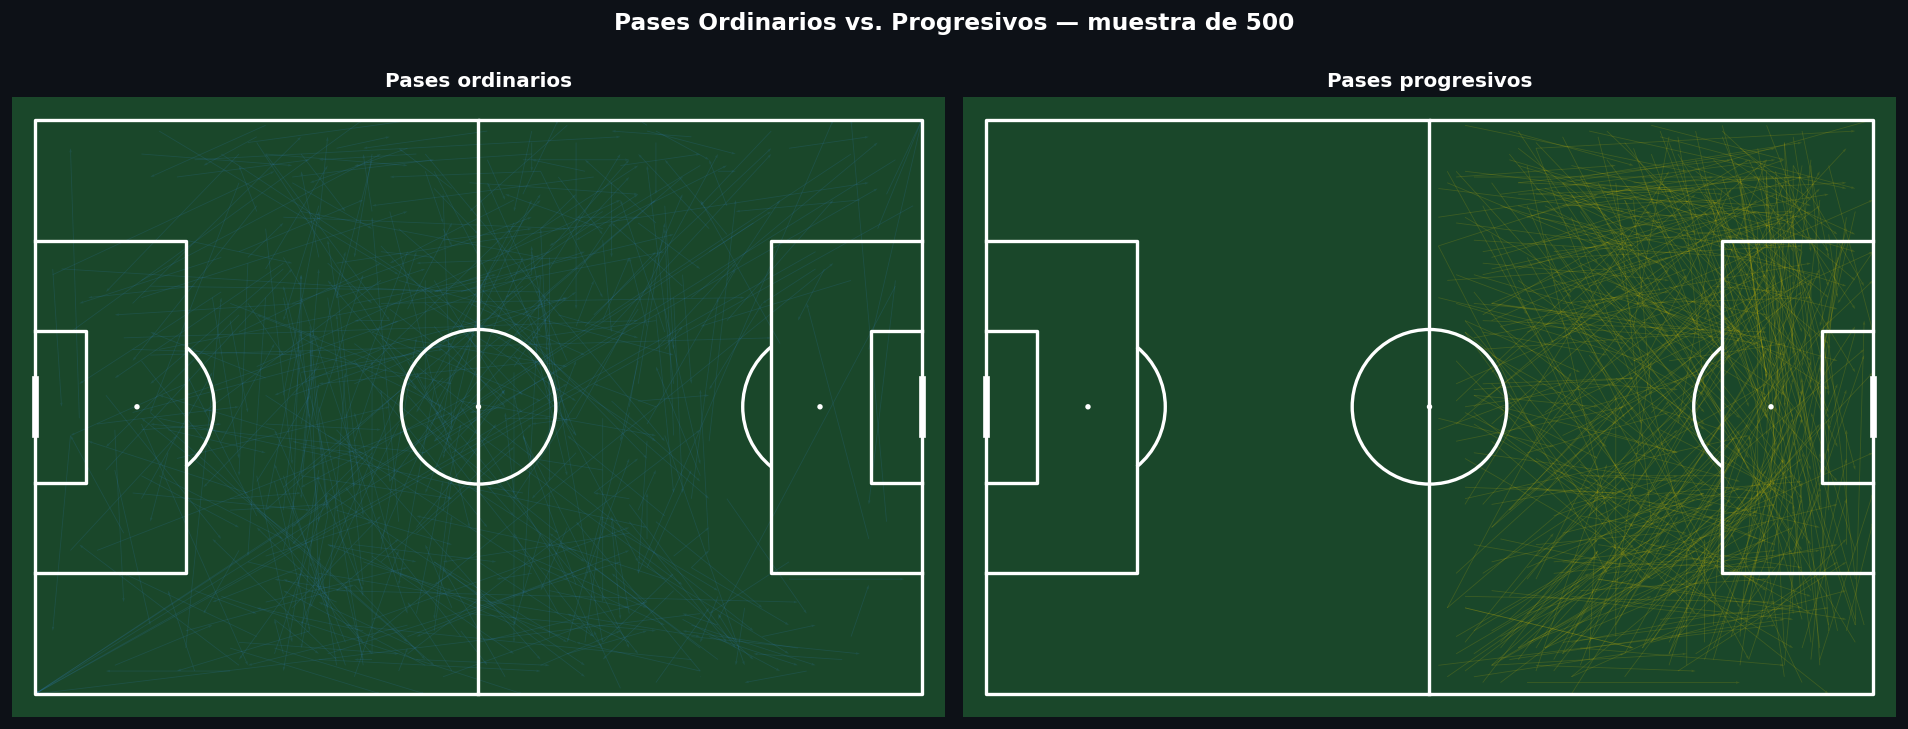

In [38]:
# Visualización de pases progresivos vs ordinarios
pitch = Pitch(pitch_type='opta', pitch_color='#1a472a', line_color='white', line_zorder=2)
fig, axes = pitch.draw(ncols=2, figsize=(16, 6))
fig.set_facecolor('#0d1117')

for ax, (label, mask) in zip(axes, [
    ('Pases ordinarios', ~df_passes['is_progressive']),
    ('Pases progresivos', df_passes['is_progressive'])
]):
    sample = df_passes[mask].dropna(subset=['x','y','end_x','end_y']).sample(min(500, mask.sum()))
    pitch.arrows(
        sample['x'], sample['y'],
        sample['end_x'], sample['end_y'],
        ax=ax, width=0.5, alpha=0.15,
        color='#378ADD' if 'ordinarios' in label else '#FFD700'
    )
    ax.set_title(label, color='white', fontsize=12, fontweight='bold')

plt.suptitle('Pases Ordinarios vs. Progresivos — muestra de 500', 
             color='white', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Actividades propuestas

### Ejercicio 1 — Shot Map por equipo
Elegí dos equipos de alguna liga (por ejemplo Manchester City y Manchester United) y comparalos
en un shot map side-by-side. ¿Qué diferencias ves en el patrón de tiros?

#### Filtramos los tiros por equipo

In [39]:
# Real Madrid
df_shots_RM = df_events[(df_events['eventName'] == 'Shot') & (df_events['teamId'] == 675)].copy()
print(f'Total de tiros: {len(df_shots_RM):,}')
print(f'Goles: {df_shots_RM["is_goal"].sum():,}')
print(f'Tasa de conversión: {df_shots_RM["is_goal"].mean():.1%}')

Total de tiros: 631
Goles: 81
Tasa de conversión: 12.8%


In [40]:
# Barcelona
df_shots_BCN = df_events[(df_events['eventName'] == 'Shot') & (df_events['teamId'] == 676)].copy()
print(f'Total de tiros: {len(df_shots_BCN):,}')
print(f'Goles: {df_shots_BCN["is_goal"].sum():,}')
print(f'Tasa de conversión: {df_shots_BCN["is_goal"].mean():.1%}')

Total de tiros: 502
Goles: 87
Tasa de conversión: 17.3%


#### Subplot para comparar los equipos

In [41]:
def plot_shot_map_by_team(df_shots, team_id=None, title=None, ax=None):
    data = df_shots.copy()

    pitch = VerticalPitch(
        pitch_type="opta",
        pitch_color="#0d1117",
        line_color="#8b949e",
        half=True,
        line_zorder=2
    )

    if ax is None:
        fig, ax = pitch.draw(figsize=(8, 8), constrained_layout=True)
    else:
        pitch.draw(ax=ax)
        

    # No goles
    no_goal = data[~data["is_goal"]]
    pitch.scatter(
        no_goal["x"], no_goal["y"],
        s=70,
        alpha=0.47,
        edgecolors="white",
        linewidth=0.4,
        c="#378ADD",
        ax=ax,
        label="No gol"
    )

    # Goles
    goals = data[data["is_goal"]]

    pitch.scatter(
        goals["x"],
        goals["y"],
        s=220,
        color="#FF4D4D",
        marker="*",
        edgecolors="white",
        linewidth=1.5,
        ax=ax,
        zorder=3,
        label="Gol"
    )
    
    
    conversion = len(goals) / max(len(data), 1)

    ax.set_title(
    title,
    fontsize=18,
    color="white",
    weight="bold",
    pad=15,
    )


    ax.text(
        0.64,
        0.99,
        f"{len(data)} tiros · {len(goals)} goles · {conversion:.1%} conversion",
        transform=ax.transAxes,
        ha="right",
        va="center",
        fontsize=10,
        color="#B0B8C1",
    )

    return ax

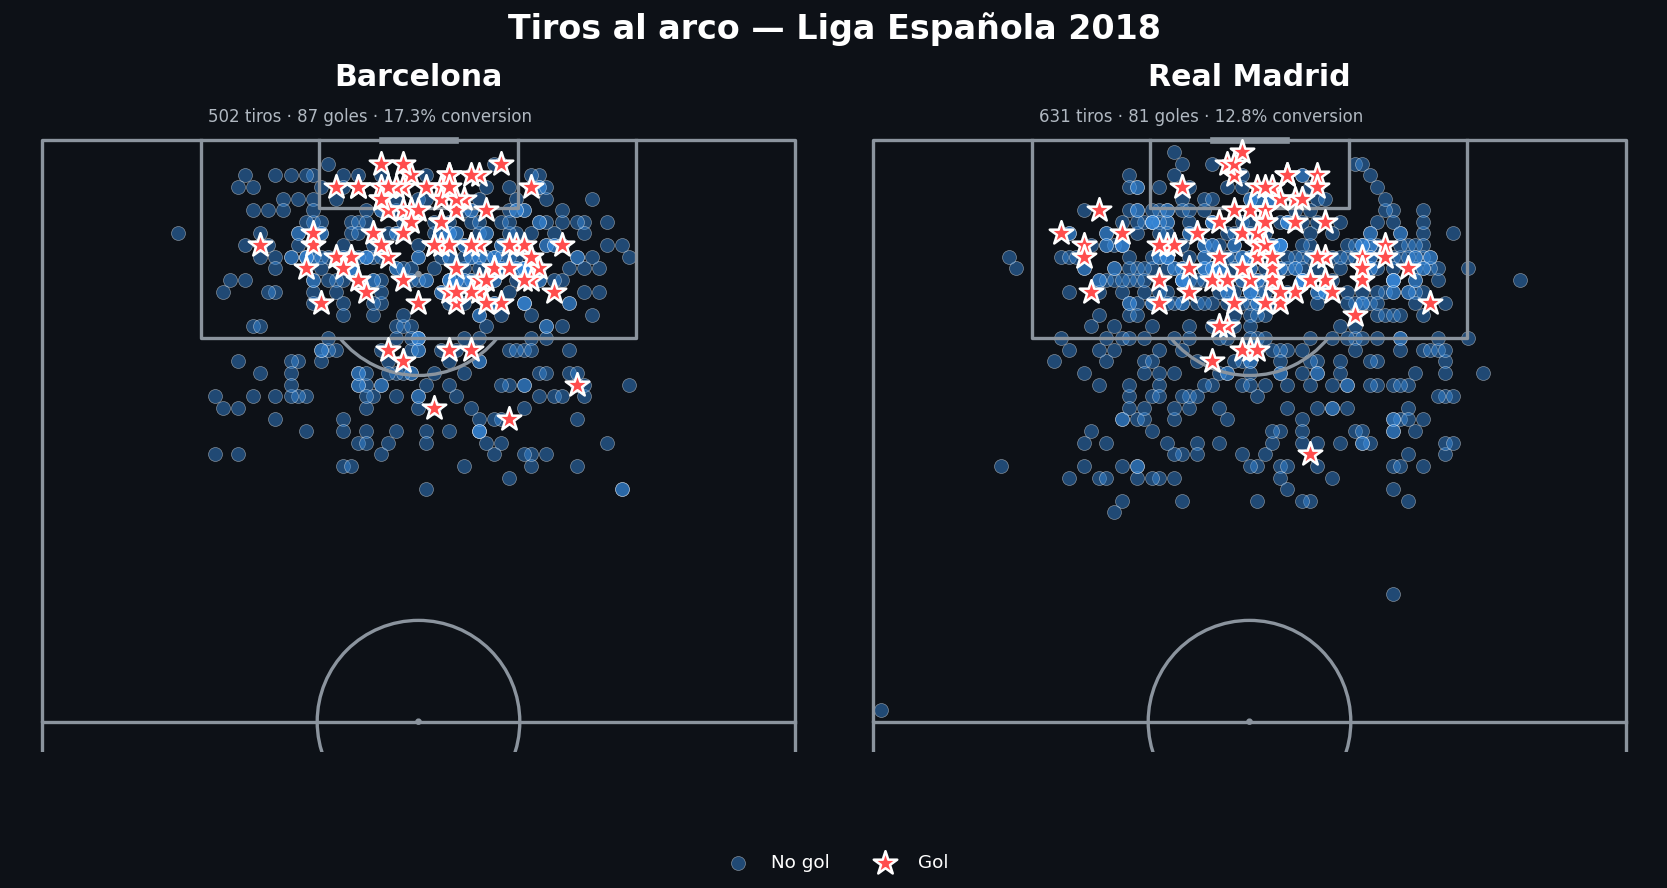

In [42]:
fig, axs = plt.subplots(
    1, 2,
    figsize=(14, 8),
    facecolor="#0d1117"
)


fig.suptitle(
    "Tiros al arco — Liga Española 2018",
    fontsize=20,
    color="white",
    weight="bold",
    y=0.91,
)

plot_shot_map_by_team(df_shots_BCN, title="Barcelona", ax=axs[0])
plot_shot_map_by_team(df_shots_RM, title="Real Madrid", ax=axs[1])

handles, labels = axs[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=False,
    labelcolor="white",
    fontsize=11,
)
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.tight_layout()
plt.show()

#### Análisis de los shot maps

El shot map muestra que ambos equipos generan la mayoría de sus remates dentro del área rival, aunque existen diferencias en su patrón ofensivo. El Barcelona presenta una mayor concentración de goles en zonas muy cercanas al arco y una tasa de conversión superior (17.3%), mientras que el Real Madrid realiza más remates totales, pero convierte una menor proporción de ellos (12.8%). Esto sugiere que, durante la temporada analizada, el Barcelona fue más eficiente en la selección o finalización de sus ocasiones de gol, mientras que el Real Madrid compensó con un mayor volumen de disparos. Esta comparación evidencia que una mayor cantidad de tiros no implica necesariamente una mayor eficacia ofensiva

### Ejercicio 2 — xG semanal
Calcula el xG acumulado por jornada para los 5 principales equipos de la liga.
Graficá la evolución temporal y compará con los goles reales marcados.

¿Qué equipos están sobre-rindiendo o sub-rindiendo respecto a su xG?

Analizaremos el xG (expected goals) en los 5 primeros equipos en la tabla de posiciones de la liga española 2017-2018. 

Estos fueron:
- Barcelona
- Atlético de Madrid
- Real Madrid
- Valencia 
- Villareal

In [69]:
df_shots_fe_gameweek = df_shots_fe.merge(
    df_matches[['wyId', 'gameweek']],
    left_on='matchId',
    right_on='wyId',
    how='left'
)

df_total_xG_gameweek = df_shots_fe_gameweek.groupby(['gameweek', 'teamId']).agg(
    total_xG=('xG', 'sum'),
    total_goals=('is_goal', 'sum'),
    total_shots=('eventId', 'count')
    ).reset_index() 


team_names = {
    676: "Barcelona",
    679: "Atlético de Madrid",
    675: "Real Madrid",
    674: "Valencia",
    682: "Villarreal",
}

df_total_xG_gameweek_5 = (
    df_total_xG_gameweek
    .loc[df_total_xG_gameweek["teamId"].isin(team_names)]
    .assign(team_name=lambda df: df["teamId"].map(team_names))
    .sort_values(["teamId", "gameweek"])
)

df_total_xG_gameweek_5

,gameweek,teamId,total_xG,total_goals,total_shots,team_name
0,1,674,1.851001,1,21,Valencia
20,2,674,0.868234,2,7,Valencia
40,3,674,0.403977,0,8,Valencia
60,4,674,0.972505,1,13,Valencia
80,5,674,2.364238,5,15,Valencia
...,...,...,...,...,...,...
667,34,682,1.505698,1,20,Villarreal
687,35,682,3.107662,4,13,Villarreal
707,36,682,1.909138,1,14,Villarreal
727,37,682,1.945076,4,11,Villarreal


In [70]:
df_total_xG_season_5 = df_total_xG_gameweek_5.groupby('teamId').agg(
    season_xG=('total_xG', 'sum'),
    season_goals=('total_goals', 'sum'),
    season_shots=('total_shots', 'sum'),
    team_name=('team_name', 'first')
).reset_index()

df_total_xG_season_5

,teamId,season_xG,season_goals,season_shots,team_name
0,674,46.190262,55,444,Valencia
1,675,80.391081,83,659,Real Madrid
2,676,77.683328,93,561,Barcelona
3,679,39.165921,53,371,Atlético de Madrid
4,682,44.896549,52,451,Villarreal


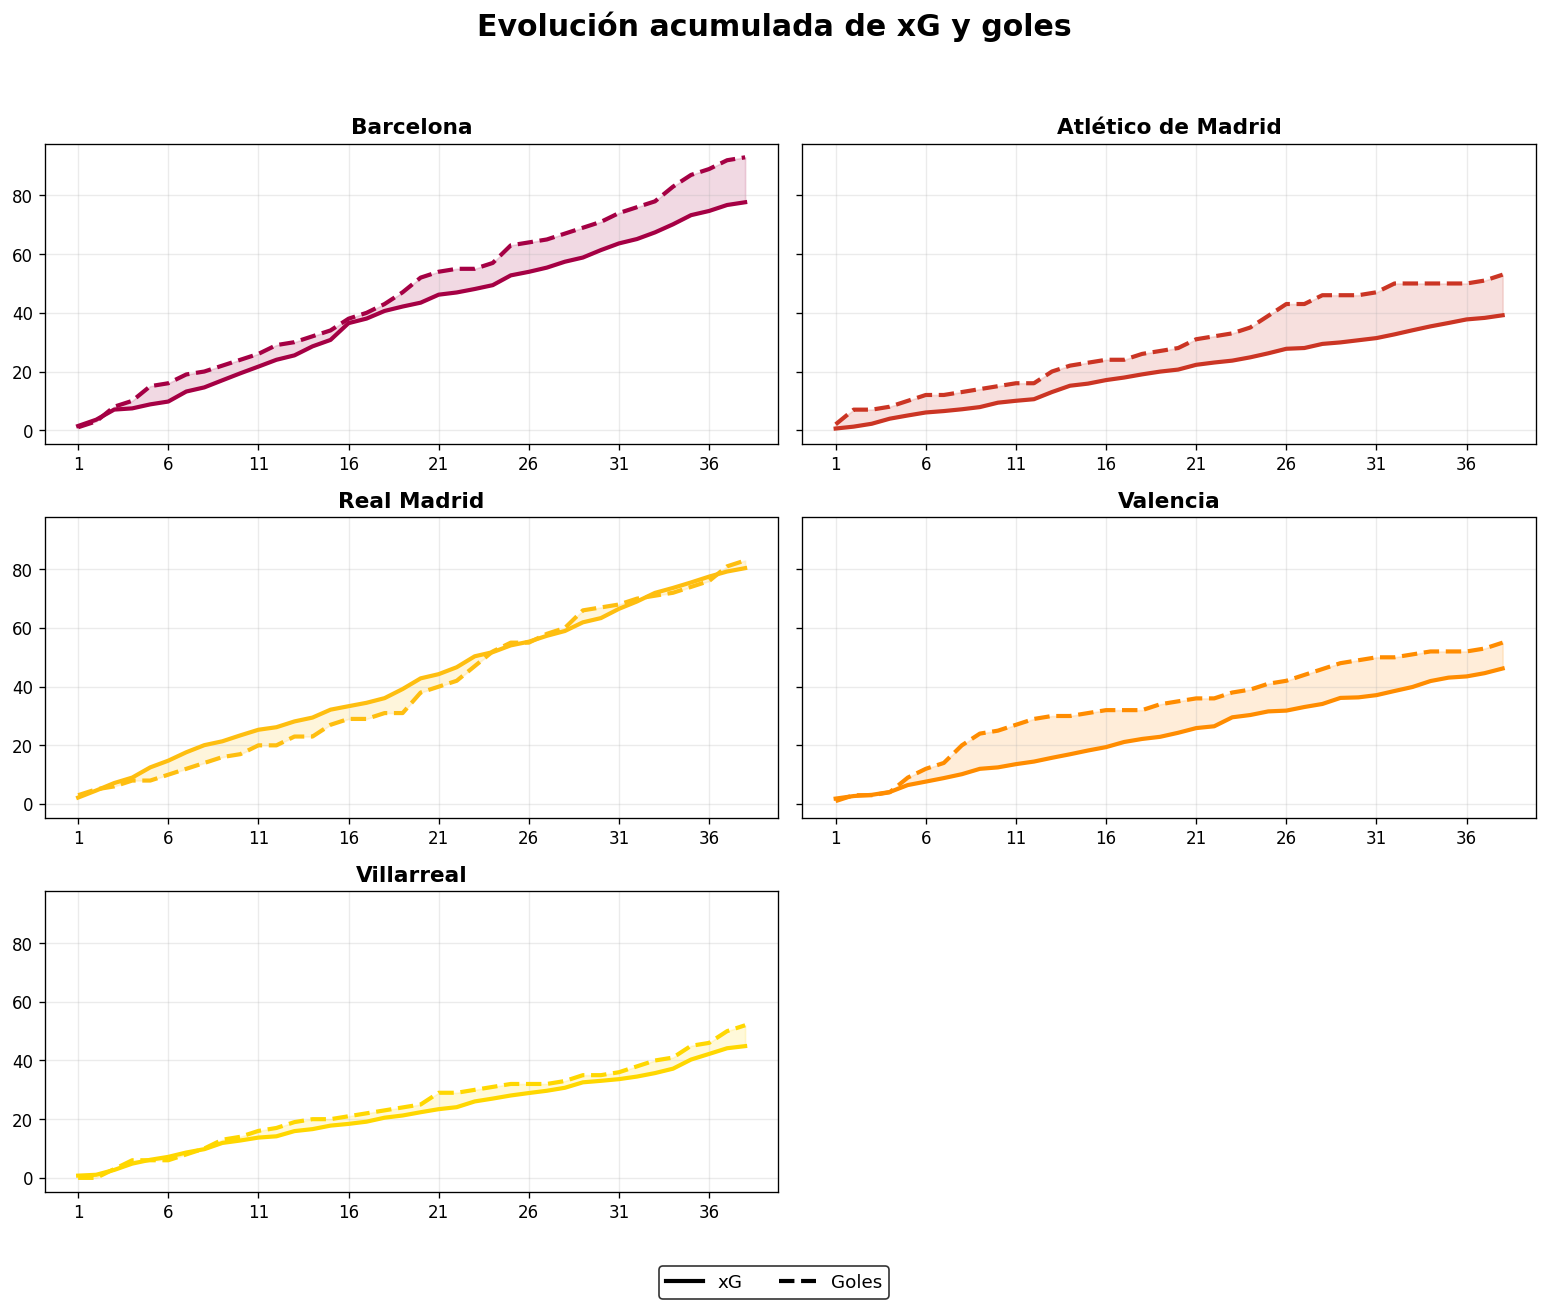

In [ ]:
colors = {
    676: "#A50044",   # Barcelona
    675: "#FEBE10",   # Real Madrid
    679: "#CB3524",   # Atlético
    674: "#FF8C00",   # Valencia
    682: "#FFD700",   # Villarreal
}

fig, axes = plt.subplots(
    3, 2,
    figsize=(13, 11),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, (team_id, team_name) in zip(axes, team_names.items()):

    team = (
        df_total_xG_gameweek_5[df_total_xG_gameweek_5.teamId == team_id]
        .sort_values("gameweek")
    )

    color = colors[team_id]

    ax.plot(
        team.gameweek,
        team.total_xG.cumsum(),
        color=color,
        lw=2.5,
        label="xG"
    )

    ax.plot(
        team.gameweek,
        team.total_goals.cumsum(),
        color=color,
        lw=2.5,
        ls="--",
        label="Goles"
    )

    ax.fill_between(
        team.gameweek,
        team.total_xG.cumsum(),
        team.total_goals.cumsum(),
        alpha=0.15,
        color=color
    )

    ax.set_title(team_name, fontsize=13, weight="bold")
    ax.grid(alpha=.25)

for ax in axes[:-1]:
    ax.tick_params(axis="x", labelbottom=True)
    ax.set_xticks(np.arange(1, 39, 5)) 

axes[-1].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
#fig.legend(handles, labels, loc="lower center", ncol=2,labelcolor="black",facecolor="white",edgecolor="black",frameon=True)

fig.suptitle(
    "Evolución acumulada de xG y goles",
    fontsize=18,
    weight="bold"
)

legend_handles = [
    Line2D([0], [0], color="black", lw=2.5, label="xG"),
    Line2D([0], [0], color="black", lw=2.5, ls="--", label="Goles"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=2,
    frameon=True,
    fontsize=11,
    facecolor="white",
    edgecolor="black",
)

fig.tight_layout(rect=[0,0.05,1,0.95])

La comparación entre el xG acumulado y los goles reales permite evaluar la eficacia ofensiva de cada equipo a lo largo de la temporada. Barcelona es el equipo que presenta el mayor sobre-rendimiento, ya que sus goles acumulados superan ampliamente el xG esperado. Esto sugiere una capacidad de definición superior a la media que se condice con la eficacia que se veía en el gráfico del ejercicio anterior. Valencia y Atlético de Madrid también convierten más goles de los que predice el modelo, aunque con una diferencia menor. En cambio, el Real Madrid es el equipo cuyo rendimiento se ajusta más al xG, ya que ambas curvas permanecen muy próximas durante casi toda la temporada y finalizan prácticamente superpuestas. Villarreal también registra un ligero sobre-rendimiento al finalizar el campeonato. En conjunto, el análisis muestra que el xG describe adecuadamente la producción ofensiva esperada, mientras que las diferencias entre ambas curvas reflejan la eficiencia (o ineficiencia) de cada equipo para convertir sus oportunidades en goles.

### Ejercicio 3 — Red de pases más conectada
Identifica el par de jugadores con mayor número de pases entre ellos en toda la temporada.
¿Corresponde a alguna combinación táctica conocida?

In [46]:
# Redefinimos la función para contar la cantidad de pases sacando el minimo de tres pases para contar la cantidad total de pases en la temporada con exactitud

def build_passing_network_sin_minimo(df_events, match_id, team_id, min_count=3):
   
    df_match_all = df_events[df_events['matchId'] == match_id].sort_values(
        ['matchPeriod', 'eventSec']
    ).reset_index(drop=True)

    df_match_all['next_player'] = df_match_all['playerId'].shift(-1)
    df_match_all['next_teamId'] = df_match_all['teamId'].shift(-1)

    mask = (df_match_all['teamId'] == team_id) & (df_match_all['eventName'] == 'Pass')
    df_match_passes = df_match_all[mask].copy()

    nodes = df_match_passes.groupby('playerId').agg(
        x=('x', 'mean'),
        y=('y', 'mean'),
        passes_made=('eventId', 'count')
    ).reset_index()

    sin_perdida = df_match_passes['next_teamId'] == team_id
    edges = df_match_passes[sin_perdida].groupby(
        ['playerId', 'next_player']
    ).size().reset_index(name='count')

    edges = edges[edges['count'] >= min_count]
    return nodes, edges


# Recorremos todos los partidos y equipos, acumulando aristas sin filtrar por partido 
edges_todos = []

for match_id in df_matches['wyId'].unique():
    teams_in_match = df_events[df_events['matchId'] == match_id]['teamId'].unique()

    for team_id in teams_in_match:
        _, edges = build_passing_network_sin_minimo(df_events, match_id, team_id, min_count=0)
        if len(edges) > 0:
            edges_todos.append(edges)

#  Sumamos aristas de todos los partidos 
edges_temporada = (
    pd.concat(edges_todos, ignore_index=True)
    .groupby(['playerId', 'next_player'])['count']
    .sum()
    .reset_index()
)

#  Par no ordenado (A-B y B-A cuentan como la misma conexión) 
edges_temporada['par'] = edges_temporada.apply(
    lambda r: tuple(sorted([int(r['playerId']), int(r['next_player'])])),
    axis=1
)

pares_totales = (
    edges_temporada.groupby('par')['count']
    .sum()
    .reset_index(name='pases_totales')
    .sort_values('pases_totales', ascending=False)
)

nombres = players_lookup['shortName']
pares_totales['jugador_1'] = pares_totales['par'].str[0].map(nombres)
pares_totales['jugador_2'] = pares_totales['par'].str[1].map(nombres)

#  Equipo del par de jugadores con más pases entre ellos
equipos_jugadores = players_lookup['currentTeamId']
pares_totales['team_id'] = pares_totales['par'].str[0].map(equipos_jugadores)

pares_totales = pares_totales.merge(
    teams[['wyId', 'name']],
    left_on='team_id',
    right_on='wyId',
    how='left'
).rename(columns={'name': 'team_name'}).drop(columns='wyId')

top_par = pares_totales.iloc[0]
print(f"Par de jugadores con más pases en la temporada: {top_par['jugador_1']} — {top_par['jugador_2']} ({top_par['team_name']})")
print(f"Pases totales entre ambos (ambas direcciones): {top_par['pases_totales']}")

pares_totales.head(10)

Par de jugadores con más pases en la temporada: Trigueros — Rodri (Villarreal)
Pases totales entre ambos (ambas direcciones): 620


,par,pases_totales,jugador_1,jugador_2,team_id,team_name
0,"(3542, 364860)",620,Trigueros,Rodri,682,Villarreal
1,"(3269, 3353)",611,Jordi Alba,Iniesta,676,Barcelona
2,"(3310, 14723)",541,Marcelo,T. Kroos,675,Real Madrid
3,"(3346, 3476)",503,Sergio Busquets,I. Rakitić,676,Barcelona
4,"(3347, 3476)",479,Sergi Roberto,I. Rakitić,676,Barcelona
5,"(3269, 25397)",477,Jordi Alba,S. Umtiti,676,Barcelona
6,"(26307, 70120)",472,A. Mandi,Javi García,684,Real Betis
7,"(3359, 3476)",468,L. Messi,I. Rakitić,676,Barcelona
8,"(26307, 346195)",455,A. Mandi,Fabián,684,Real Betis
9,"(4424, 241945)",451,Jonny,P. Sisto,692,Celta de Vigo


In [47]:
# Definimos una funcion que construye la red de pases de un equipo sumando todos los partidos de la temporada.

def build_passing_network_season(df_events, team_id, min_count=3):
    #Retorna nodos (posición media ponderada) y aristas (conexiones de pase acumuladas).

    df_team = df_events.sort_values(['matchId', 'matchPeriod', 'eventSec']).reset_index(drop=True)

    # Igual que en build_passing_network, pero agrupando el shift por matchId
    # para no conectar el último evento de un partido con el primero del siguiente
    df_team['next_player'] = df_team.groupby('matchId')['playerId'].shift(-1)
    df_team['next_teamId'] = df_team.groupby('matchId')['teamId'].shift(-1)

    mask = (df_team['teamId'] == team_id) & (df_team['eventName'] == 'Pass')
    df_passes = df_team[mask].copy()

    # Nodos: posición media ponderada por pases hechos en cada partido
    nodes = df_passes.groupby('playerId').agg(
        x=('x', 'mean'),
        y=('y', 'mean'),
        passes_made=('eventId', 'count')
    ).reset_index()

    # Aristas: mismo criterio de "sin pérdida" que la función original, sumado a toda la temporada
    sin_perdida = df_passes['next_teamId'] == team_id
    edges = df_passes[sin_perdida].groupby(
        ['playerId', 'next_player']
    ).size().reset_index(name='count')
    edges = edges[edges['count'] >= min_count]

    return nodes, edges


In [ ]:

# Buscamos la cantidad de partidos jugados por cada jugador del equipo del par de jugadores con más pases entre ellos para graficar la red de pases del equipo completo, no solo del par.

team_id = top_par["team_id"]

nodes, edges = build_passing_network_season(df_events, team_id)

partidos_jugados = (
    df_events[df_events["teamId"] == team_id]
    .groupby("playerId")["matchId"]
    .nunique()
    .reset_index(name="matches_played")
)

# Unimos información de jugadores + red de pases
jugadores_equipo = (
    nodes
    .merge(
        players,
        left_on="playerId",
        right_on="wyId",
        how="left"
    )
    .merge(
        partidos_jugados,
        on="playerId",
        how="left"
    )
)

# Posición
jugadores_equipo["position"] = jugadores_equipo["role"].apply(
    lambda x: x["name"] if isinstance(x, dict) else None
)

# Corregir nombres 
jugadores_equipo['shortName'] = jugadores_equipo['shortName'].apply(
    lambda x: codecs.decode(x, 'unicode_escape') if isinstance(x, str) else x
)

# Se eliminan jugadores sin nombre
jugadores_equipo = jugadores_equipo.dropna(subset=["shortName"])

# Se seleccionan columnas
jugadores_equipo = jugadores_equipo[[
    "playerId",
    "shortName",
    "position",
    "passes_made",
    "matches_played",
    "x",
    "y"
]]

jugadores_equipo = (
    jugadores_equipo
    .sort_values(
        ["matches_played", "passes_made"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

jugadores_equipo.index += 1

display(jugadores_equipo)

,playerId,shortName,position,passes_made,matches_played,x,y
1,364860,Rodri,Midfielder,2338,37,44.335757,50.063302
2,399676,Pablo Fornals,Midfielder,1299,35,56.017706,48.046189
3,37831,C. Bacca,Forward,494,35,64.125506,39.876518
4,3542,Trigueros,Midfielder,1753,34,49.342841,42.883058
5,3695,Ãlvaro GonzÃ¡lez,Defender,1390,33,34.725180,60.548921
6,3529,Mario,Defender,1438,32,48.167594,86.682893
7,3534,Jaume Costa,Defender,1353,30,49.828529,13.464154
8,134174,Samu Castillejo,Midfielder,869,30,57.995397,69.972382
9,3277,VÃ­ctor RuÃ­z,Defender,1333,27,32.333083,31.312828
10,4513,D. Cheryshev,Midfielder,317,24,59.539432,23.536278


In [50]:
#Grafica la red de pases del XI habitual, resaltando en rojo la conexión del par con más pases de la temporada.

def plot_passing_network_top11(nodes_plot, edges_plot, top_par, title=""):
    
    jugador1, jugador2 = top_par["par"]

    pitch = Pitch(
        pitch_type="opta", pitch_color="#1a472a",
        line_color="white", line_zorder=2
    )
    fig, ax = pitch.draw(figsize=(15, 10))
    fig.set_facecolor("#0d1117")

    max_count = edges_plot["count"].max() if len(edges_plot) else 1
    pos = nodes_plot.set_index("playerId")[["x", "y"]].to_dict("index")

    # Conexiones 
    for _, edge in edges_plot.iterrows():
        if edge.playerId not in pos or edge.next_player not in pos:
            continue
        x1, y1 = pos[edge.playerId]["x"], pos[edge.playerId]["y"]
        x2, y2 = pos[edge.next_player]["x"], pos[edge.next_player]["y"]
        ax.plot(
            [x1, x2], [y1, y2],
            color="white",
            alpha=0.25 + 0.55 * edge["count"] / max_count,
            linewidth=1 + 4 * edge["count"] / max_count,
            zorder=2
        )

    # Resaltado del par con más pases 
    for _, edge in edges_plot.iterrows():
        if set((edge.playerId, edge.next_player)) != set((jugador1, jugador2)):
            continue
        if edge.playerId not in pos or edge.next_player not in pos:
            continue
        x1, y1 = pos[edge.playerId]["x"], pos[edge.playerId]["y"]
        x2, y2 = pos[edge.next_player]["x"], pos[edge.next_player]["y"]
        ax.plot([x1, x2], [y1, y2], color="red", linewidth=7, alpha=1, zorder=4)

    # Nodos 
    if len(nodes_plot):
        max_passes = nodes_plot["passes_made"].max()
        sc = pitch.scatter(
            nodes_plot["x"], nodes_plot["y"],
            s=250 + 900 * nodes_plot["passes_made"] / max_passes,
            c=nodes_plot["passes_made"],
            cmap="YlOrRd", edgecolors="white", linewidth=2,
            ax=ax, zorder=5
        )
        plt.colorbar(sc, ax=ax, label="Pases realizados", shrink=0.6)

    # Nombres 
    for _, row in nodes_plot.iterrows():
        es_top = row.playerId in (jugador1, jugador2)
        ax.annotate(
            row.shortName,
            xy=(row.x, row.y), xytext=(0, 12), textcoords="offset points",
            ha="center", va="center", fontsize=8, fontweight="bold",
            color="yellow" if es_top else "white",
            path_effects=[pe.withStroke(linewidth=2, foreground="#0d1117")],
            zorder=6
        )

    ax.set_title(title, fontsize=15, color="white", fontweight="bold")
    plt.tight_layout()
    plt.show()

In [51]:
#Se define la función para arreglar el problema de nombres y acentos

def fix_encoding(x):
    if not isinstance(x, str):
        return x
    try:
        return codecs.decode(x, 'unicode_escape')
    except (UnicodeDecodeError, ValueError):
        return x

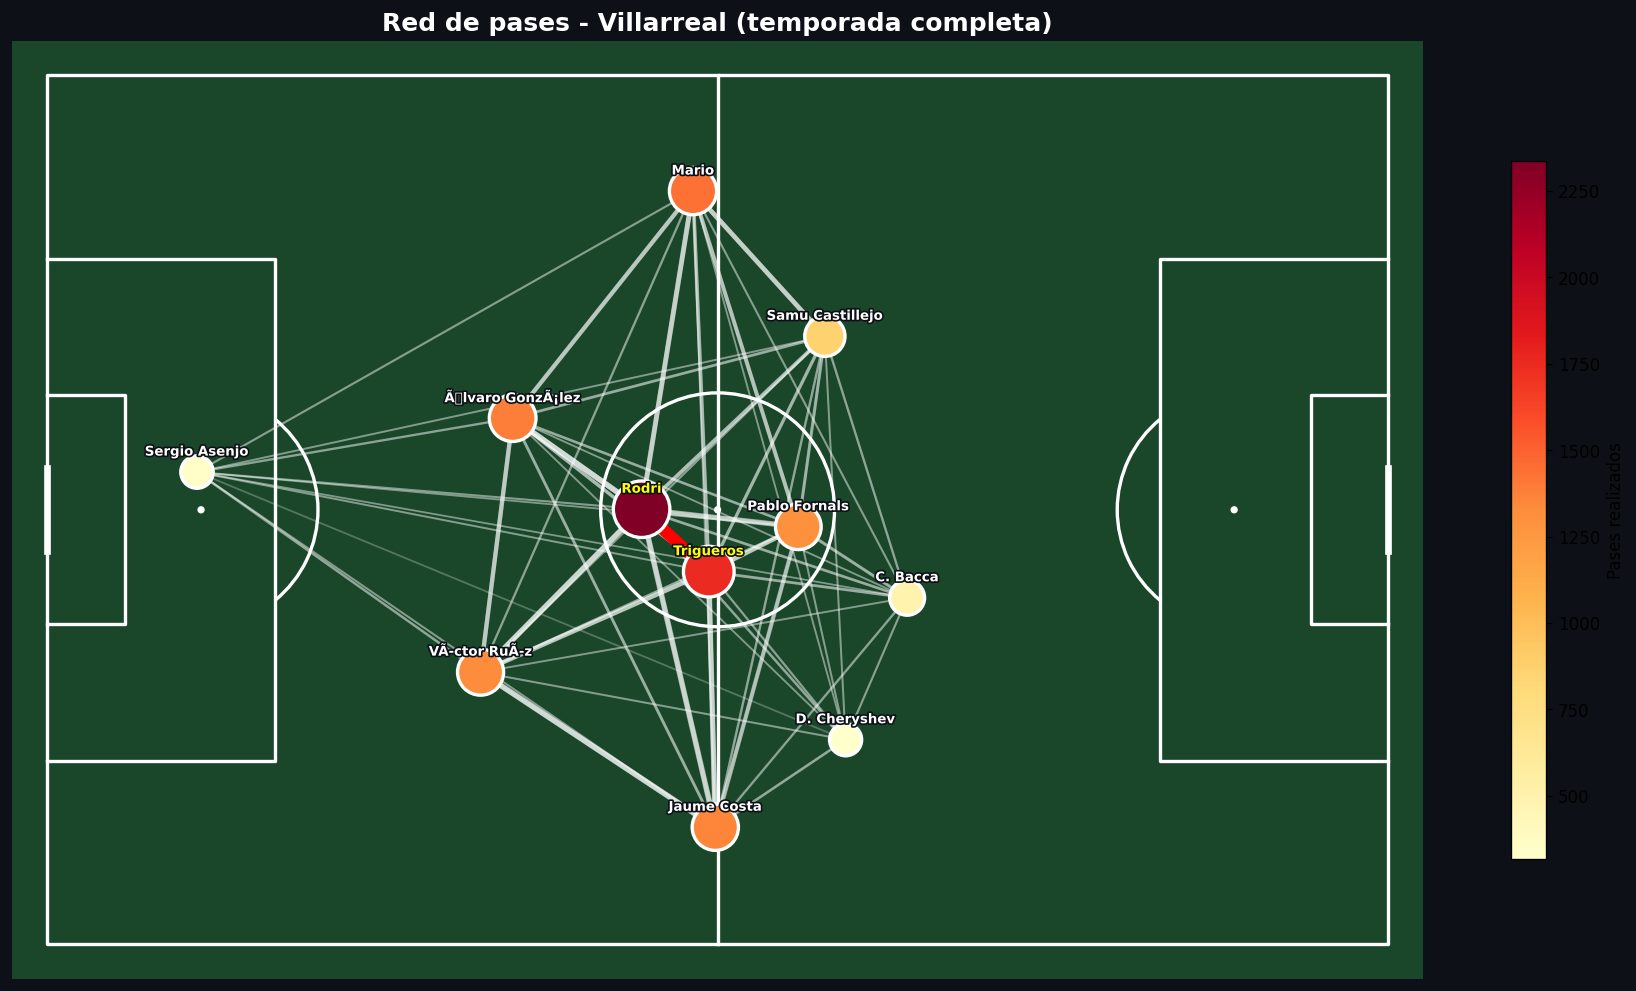

In [52]:
# RED DE PASES - TEMPORADA COMPLETA (XI MÁS HABITUAL)

top11_ids = set(jugadores_equipo.head(11)["playerId"])

nodes_plot = nodes[nodes["playerId"].isin(top11_ids)].copy()

edges_plot = edges_temporada[
    edges_temporada["playerId"].isin(top11_ids) &
    edges_temporada["next_player"].isin(top11_ids)
].copy()

nodes_plot = nodes_plot.merge(
    players[["wyId", "shortName"]],
    left_on="playerId", right_on="wyId", how="left"
)
nodes_plot["shortName"] = nodes_plot["shortName"].apply(fix_encoding)
nodes_plot.drop(columns="wyId", inplace=True)

plot_passing_network_top11(
    nodes_plot, edges_plot, top_par,
    title=f"Red de pases - {top_par['team_name']} (temporada completa)"
)

Se toma la desición de graficar la red de pases con los 11 jugadores que más veces iniciaron en el XI titular de arranque. 

A partir de esto observamos una configuración táctica visible, con laterales bien abiertos y un medio campo cargado de volantes donde se destaca el juego asociado y la proximidad de los mismos, muy presente en la escencia del fútbol español. Justamente aquí se advierte la presencia del par de jugadores con más pases entre ellos en la temporada (Rodri y Trigueros) en medio del terreno de jeugo siendo el nexo claro del equipo.

A pesar de esto, algunos jugadores tienen la cantidad de partidos jugados de arranque correspondientes a la cantidad de partidos de media temporada aproximadamente, por lo que realizamos la prueba divideindo la temporada en dos, luego del receso y el mercado de pases.


Primera mitad
            shortName  passes_made
9               Rodri         1156
3           Trigueros          867
10      Pablo Fornals          779
0       VÃ­ctor RuÃ­z          763
2         Jaume Costa          712
1               Mario          700
4   Ãlvaro GonzÃ¡lez          690
8     Samu Castillejo          432
6          C. Bakambu          262
7            C. Bacca          241
5          M. Barbosa          183


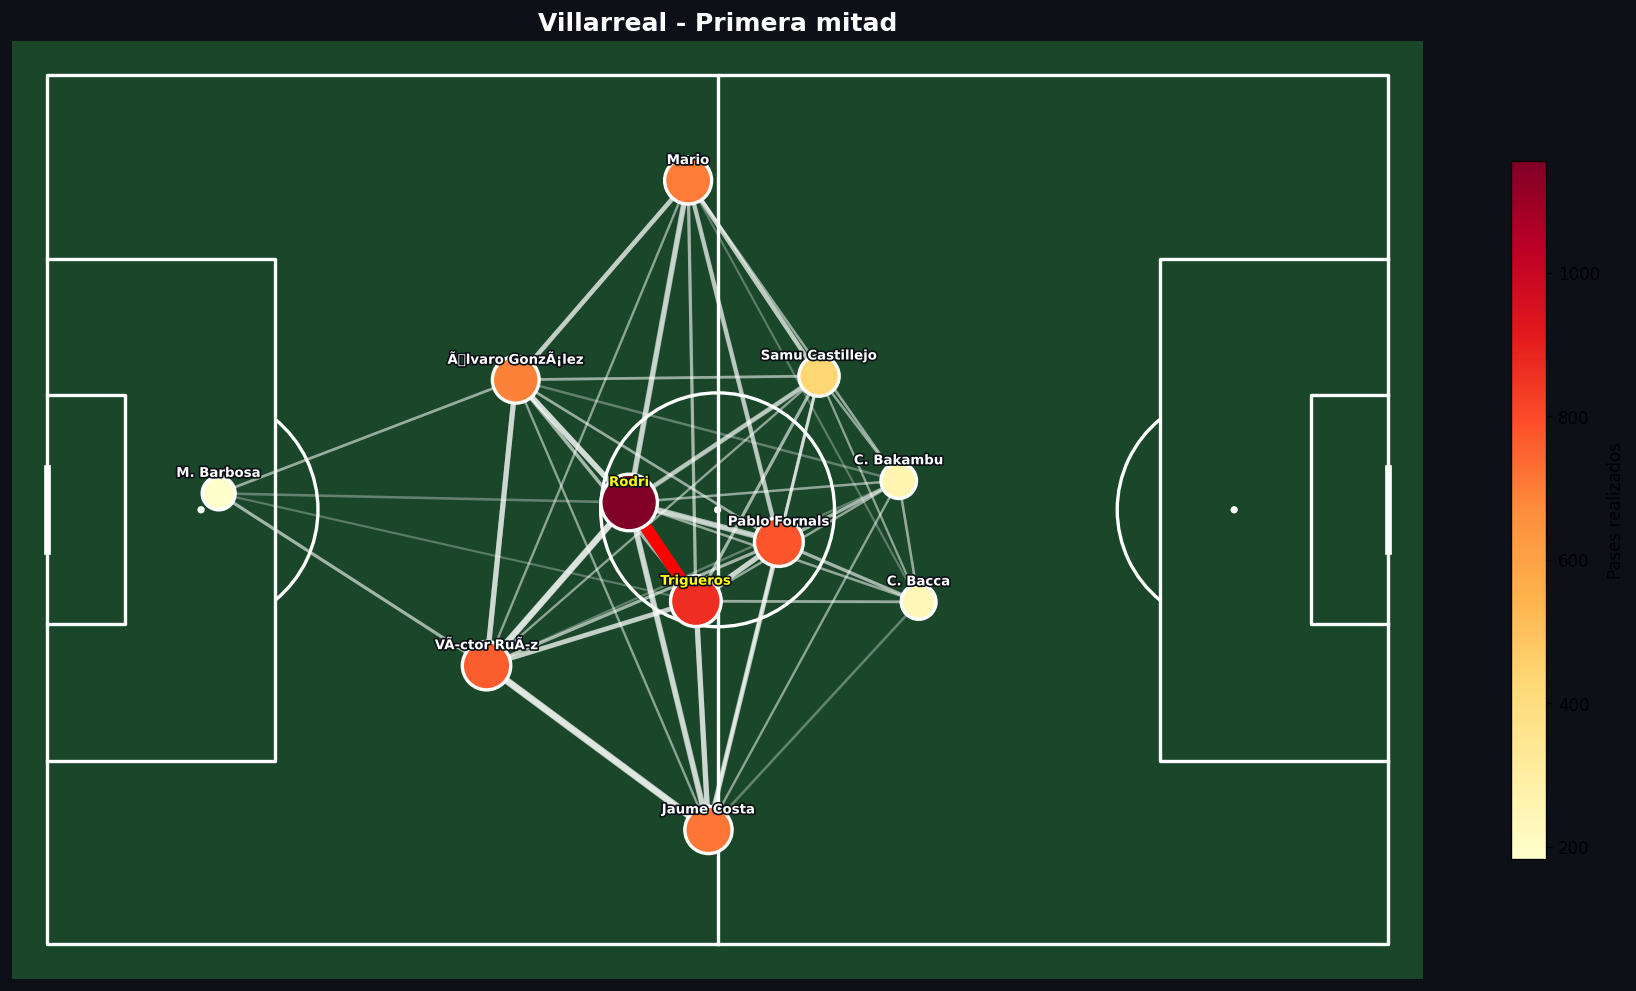


Segunda mitad
            shortName  passes_made
9               Rodri         1182
4           Trigueros          886
2               Mario          738
5   Ãlvaro GonzÃ¡lez          700
3         Jaume Costa          641
0       VÃ­ctor RuÃ­z          570
10      Pablo Fornals          520
8     Samu Castillejo          437
6           D. Bonera          364
1       Sergio Asenjo          273
7            C. Bacca          253


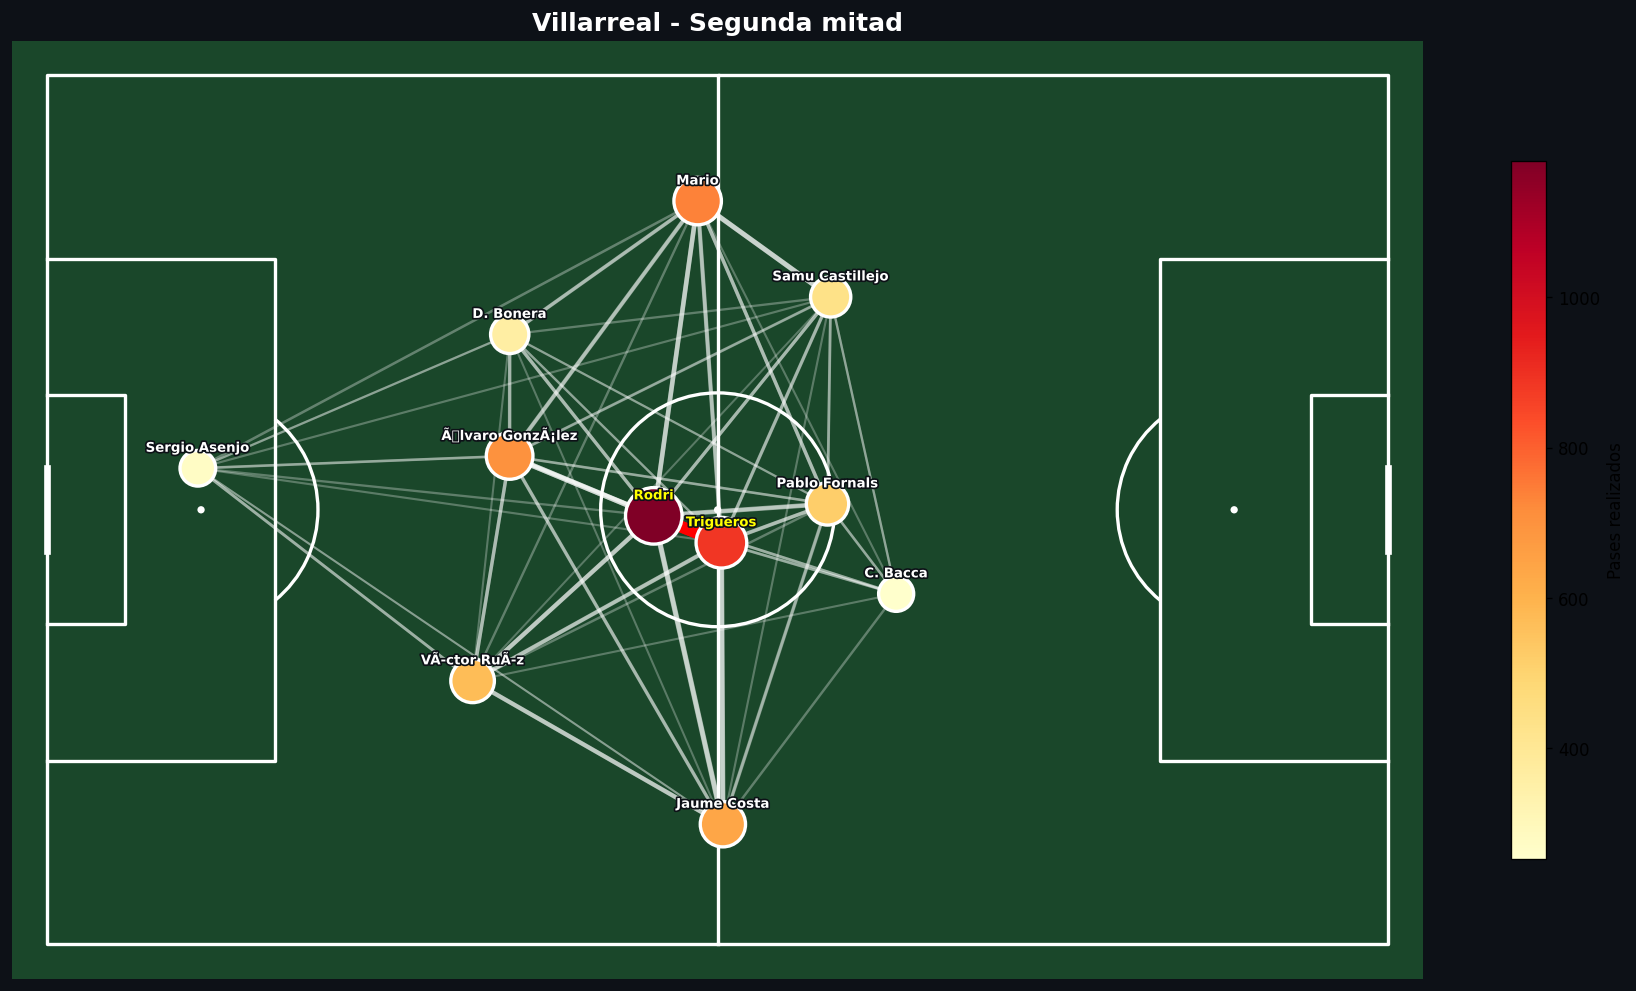

In [54]:
# REDES DE PASES - PRIMERA Y SEGUNDA MITAD DE TEMPORADA
# XI MÁS HABITUAL DE CADA MITAD

team_id = top_par["team_id"]
team_name = top_par["team_name"]

# Partidos del equipo ordenados cronológicamente

matches_equipo = (
    df_matches[df_matches["wyId"].isin(
        df_events[df_events["teamId"] == team_id]["matchId"].unique()
    )]
    .sort_values("dateutc")
)

match_ids = matches_equipo["wyId"].tolist()
mitad = len(match_ids) // 2

periodos = {
    "Primera mitad": match_ids[:mitad],
    "Segunda mitad": match_ids[mitad:]
}

# Se procesar cada mitad

for nombre_periodo, partidos in periodos.items():


    # XI más habitual (titulares) de esta mitad

    titulares = {}

    for _, match in df_matches[df_matches["wyId"].isin(partidos)].iterrows():
        for team in match["teamsData"].values():
            if int(team["teamId"]) != team_id:
                continue
            for jugador in team["formation"]["lineup"]:
                pid = jugador["playerId"]
                titulares[pid] = titulares.get(pid, 0) + 1

    titulares = (
        pd.DataFrame(titulares.items(), columns=["playerId", "matches_started"])
        .sort_values("matches_started", ascending=False)
    )
    top11_ids = set(titulares.head(11)["playerId"])


    # Construcción de la red de pases de esta mitad

    nodes_all, edges_all = [], []

    for match_id in partidos:
        n, e = build_passing_network_sin_minimo(df_events, match_id, team_id, min_count=0)
        if len(n):
            nodes_all.append(n)
        if len(e):
            edges_all.append(e)

    # Nodos

    nodes_concat = pd.concat(nodes_all, ignore_index=True)
    nodes_concat["x_w"] = nodes_concat["x"] * nodes_concat["passes_made"]
    nodes_concat["y_w"] = nodes_concat["y"] * nodes_concat["passes_made"]

    nodes_period = (
        nodes_concat.groupby("playerId")
        .agg(x_w=("x_w", "sum"), y_w=("y_w", "sum"), passes_made=("passes_made", "sum"))
        .reset_index()
    )
    nodes_period["x"] = nodes_period["x_w"] / nodes_period["passes_made"]
    nodes_period["y"] = nodes_period["y_w"] / nodes_period["passes_made"]
    nodes_period = nodes_period[["playerId", "x", "y", "passes_made"]]

    # Aristas
    
    edges_concat = pd.concat(edges_all, ignore_index=True)
    edges_period = (
        edges_concat.groupby(["playerId", "next_player"])["count"]
        .sum()
        .reset_index()
    )
    edges_period = edges_period[edges_period["count"] >= 10]

   # Mantener solamente el XI más habitual de la mitad correspondiente
   
    nodes_plot = nodes_period[nodes_period["playerId"].isin(top11_ids)].copy()
    edges_plot = edges_period[
        edges_period["playerId"].isin(top11_ids) &
        edges_period["next_player"].isin(top11_ids)
    ].copy()

    
    # Se agregan y corrigen nombres

    nodes_plot = nodes_plot.merge(
        players[["wyId", "shortName"]],
        left_on="playerId", right_on="wyId", how="left"
    )
    nodes_plot["shortName"] = nodes_plot["shortName"].apply(fix_encoding)
    nodes_plot.drop(columns="wyId", inplace=True)

    print(f"\n{nombre_periodo}")
    print(nodes_plot[["shortName", "passes_made"]].sort_values("passes_made", ascending=False))

    plot_passing_network_top11(
        nodes_plot, edges_plot, top_par,
        title=f"{team_name} - {nombre_periodo}"
    )

Si bien la tendencia principal de toda la temporada se mantiene (laterales abiertos y mediocampo cargado y asociado), en la primera mitad hay está mas clara y se ve un XI más claro con dos delanteros más desconectados, mientras que en la segunda la cantidad de partidos jugados deja de ser referencia para el armado del XI y vemos una formación que no parece ser precisamente la titular, aunque mantiene la tendencia mencionada.

Cabe destacar que en las tres configuraciones propuestas se mantiene y destaca visiblemente la posición y asociación entre el par con más pases entre ellos, así como la conexión con sus compañeros.

### Ejercicio 4 — Radar comparativo
Consiga: Elegí 3 centrocampistas del dataset y comparalos en un radar con las siguientes métricas:
pases por 90 min, pases progresivos por 90 min, duelos ganados por 90 min, xG por 90 min.

 Se define el conjunto de estadísticas relevantes para el análisis. Se asumirá un mínimo de 500 minutos, y se Normalizan las principales variables cada 90 minutos, y también se considerarán los percentiles que ocupan los distintos candidatos para cada variable, dentro de la subpoblación de mediocampistas. 

In [55]:
# Se reutiliza parte del código del apartado 3. 

def build_player_stats2(df_events, players_df, df_minutos, df_shots_fe, min_minutes=500):
    """
    Versión extendida de build_player_stats para el Ejercicio 4: suma pases
    progresivos (por 90) y el rol/posición del jugador en la misma función.
    """
    passes_df = df_events[df_events['eventName'] == 'Pass'].copy()
    passes_df['is_accurate'] = passes_df['tag_ids'].apply(lambda t: 1801 in t)
    passes_df['is_progressive'] = passes_df.apply(is_progressive_pass, axis=1)
    passes = passes_df.groupby('playerId').agg(
        total_passes=('eventId', 'count'),
        passes_accurate=('is_accurate', 'sum'),
        progressive_passes=('is_progressive', 'sum')
    ).reset_index()

    shots = df_events[df_events['eventName'] == 'Shot'].groupby('playerId').agg(
        total_shots=('eventId', 'count'), total_goals=('is_goal', 'sum')
    ).reset_index()
    xg = df_shots_fe.groupby('playerId')['xG'].sum().reset_index().rename(columns={'xG': 'total_xg'})

    duels_all = df_events[df_events['eventName'] == 'Duel']
    duels_total = duels_all.groupby('playerId').agg(total_duels=('eventId', 'count')).reset_index()
    duels_won = duels_all[duels_all['tag_ids'].apply(lambda t: 703 in t)].groupby('playerId').agg(
        total_duels_won=('eventId', 'count')
    ).reset_index()

    set_pieces = df_events[df_events['eventName'] == 'Free Kick'].groupby('playerId').agg(
        set_pieces_taken=('eventId', 'count')
    ).reset_index()

    stats = passes
    for df_merge in [shots, xg, duels_total, duels_won, set_pieces]:
        stats = stats.merge(df_merge, on='playerId', how='outer')
    stats = stats.fillna(0)

    stats = stats.merge(df_minutos, on='playerId', how='inner')
    stats = stats.merge(
        players_df[['wyId', 'shortName', 'role']], left_on='playerId', right_on='wyId', how='inner'
    ).drop(columns='wyId')
    stats['rol'] = stats['role'].apply(lambda r: r['code3'] if isinstance(r, dict) else None)
    stats = stats.drop(columns='role')

    stats = stats[stats['minutes_played'] >= min_minutes].copy()

    stats['pct_passes_accurate'] = stats['passes_accurate'] / stats['total_passes'] * 100

    for col in ['total_passes', 'total_shots', 'total_goals', 'total_xg', 'total_duels',
                'total_duels_won', 'set_pieces_taken', 'progressive_passes']:
        stats[col.replace('total_', '') + '_p90'] = stats[col] / stats['minutes_played'] * 90

    return stats


player_stats2 = build_player_stats2(df_events, players, df_minutos, df_shots_fe, min_minutes=500)
print(f'Jugadores con ≥500 minutos: {len(player_stats2)}')

cols = ['playerId', 'shortName'] + [c for c in player_stats2.columns if c not in ('playerId', 'shortName')]
player_stats2 = player_stats2[cols]
player_stats2.head()

Jugadores con ≥500 minutos: 407


,playerId,shortName,total_passes,passes_accurate,progressive_passes,total_shots,total_goals,total_xg,total_duels,total_duels_won,...,rol,pct_passes_accurate,passes_p90,shots_p90,goals_p90,xg_p90,duels_p90,duels_won_p90,set_pieces_taken_p90,progressive_passes_p90
2,151,J. Guidetti,360.0,266.0,63.0,29.0,3.0,3.151167,340.0,118.0,...,FWD,73.888889,24.179104,1.947761,0.201493,0.211646,22.835821,7.925373,0.335821,4.231343
3,254,R. Rosales,1475.0,1132.0,229.0,14.0,1.0,0.609990,612.0,222.0,...,DEF,76.745763,42.480000,0.403200,0.028800,0.017568,17.625600,6.393600,12.412800,6.595200
5,1751,O. Tannane,207.0,163.0,34.0,12.0,0.0,0.977324,173.0,59.0,...,FWD,78.743961,32.456446,1.881533,0.000000,0.153239,27.125436,9.250871,5.644599,5.331010
6,3267,Guaita,519.0,397.0,0.0,0.0,0.0,0.000000,17.0,15.0,...,GKP,76.493256,15.727273,0.000000,0.000000,0.000000,0.515152,0.454545,12.363636,0.000000
7,3269,Jordi Alba,2089.0,1799.0,293.0,15.0,2.0,2.165956,417.0,149.0,...,DEF,86.117760,68.516764,0.491983,0.065598,0.071041,13.677114,4.887026,9.413265,9.610058


In [56]:
# Para seleccionar los candidatos para armar y comparar los radares, vamos a tomar los tops de cada estadística, 
# ajustado a 90 minutos. El percentil al que pertenece cada jugador, para cada estadística también está filtrado para
# Mediocampistas.

metricas = ['passes_p90', 'progressive_passes_p90', 'duels_won_p90', 'xg_p90']
etiquetas = {
    'passes_p90': 'Pases/90',
    'progressive_passes_p90': 'Prog./90',
    'duels_won_p90': 'Duelos ganados/90',
    'xg_p90': 'xG/90'
}
mid = player_stats2[player_stats2['rol'] == 'MID'].copy()
print(f'Centrocampistas con ≥500 min: {len(mid)}')
# Percentil de cada jugador en cada métrica, dentro de la población de centrocampistas
for m in metricas:
    mid[f'pct_{m}'] = mid[m].apply(lambda v: (mid[m] < v).mean() * 100)
def top5_por_metrica(mid_df, metrica):
    cols = ['shortName'] + metricas + [f'pct_{m}' for m in metricas]
    tabla = mid_df.sort_values(metrica, ascending=False).head(5)[cols].copy()
    nombres_cols = {**etiquetas, **{f'pct_{m}': f'Pctl. {etiquetas[m]}' for m in metricas}}
    tabla = tabla.rename(columns=nombres_cols)
    
    decimales = {col: (2 if col == 'xG/90' else 1) for col in tabla.columns if col != 'shortName'}
    return tabla.round(decimales)
for m in metricas:
    print(f'\n=== Top 5 centrocampistas por {etiquetas[m]} ===')
    display(top5_por_metrica(mid, m))

Centrocampistas con ≥500 min: 148

=== Top 5 centrocampistas por Pases/90 ===


,shortName,Pases/90,Prog./90,Duelos ganados/90,xG/90,Pctl. Pases/90,Pctl. Prog./90,Pctl. Duelos ganados/90,Pctl. xG/90
248,T. Kroos,77.7,7.4,5.8,0.11,99.3,89.2,11.5,64.9
84,Isco,77.3,10.8,11.8,0.24,98.6,98.6,91.2,95.3
70,I. Rakitić,76.6,7.2,6.3,0.07,98.0,86.5,14.9,43.2
10,É. Banega,76.4,10.5,10.3,0.06,97.3,98.0,82.4,31.8
37,Iniesta,73.5,11.2,8.7,0.05,96.6,99.3,66.9,24.3



=== Top 5 centrocampistas por Prog./90 ===


,shortName,Pases/90,Prog./90,Duelos ganados/90,xG/90,Pctl. Pases/90,Pctl. Prog./90,Pctl. Duelos ganados/90,Pctl. xG/90
37,Iniesta,73.5,11.2,8.7,0.05,96.6,99.3,66.9,24.3
84,Isco,77.3,10.8,11.8,0.24,98.6,98.6,91.2,95.3
10,É. Banega,76.4,10.5,10.3,0.06,97.3,98.0,82.4,31.8
69,Jesús Navas,43.9,10.2,8.8,0.07,58.1,97.3,70.3,41.9
474,Marco Asensio,56.8,9.8,6.5,0.24,83.1,96.6,17.6,95.9



=== Top 5 centrocampistas por Duelos ganados/90 ===


,shortName,Pases/90,Prog./90,Duelos ganados/90,xG/90,Pctl. Pases/90,Pctl. Prog./90,Pctl. Duelos ganados/90,Pctl. xG/90
427,A. Januzaj,27.6,6.0,15.4,0.32,11.5,71.6,99.3,98.0
308,Gabriel,38.5,5.4,14.6,0.19,39.2,60.1,98.6,89.2
454,Iván Alejo,24.8,7.7,14.0,0.05,4.7,93.9,98.0,25.0
396,Fede Cartabia,35.9,5.9,13.9,0.13,33.8,68.2,97.3,72.3
74,Raúl García,26.1,5.3,12.9,0.30,7.4,58.8,96.6,97.3



=== Top 5 centrocampistas por xG/90 ===


,shortName,Pases/90,Prog./90,Duelos ganados/90,xG/90,Pctl. Pases/90,Pctl. Prog./90,Pctl. Duelos ganados/90,Pctl. xG/90
301,Paulinho,54.4,3.7,8.5,0.44,79.1,29.7,62.2,99.3
268,F. Vázquez,41.2,7.5,12.8,0.35,46.6,91.2,95.3,98.6
427,A. Januzaj,27.6,6.0,15.4,0.32,11.5,71.6,99.3,98.0
74,Raúl García,26.1,5.3,12.9,0.30,7.4,58.8,96.6,97.3
195,D. Cheryshev,31.0,6.9,8.8,0.27,20.3,83.1,69.6,96.6


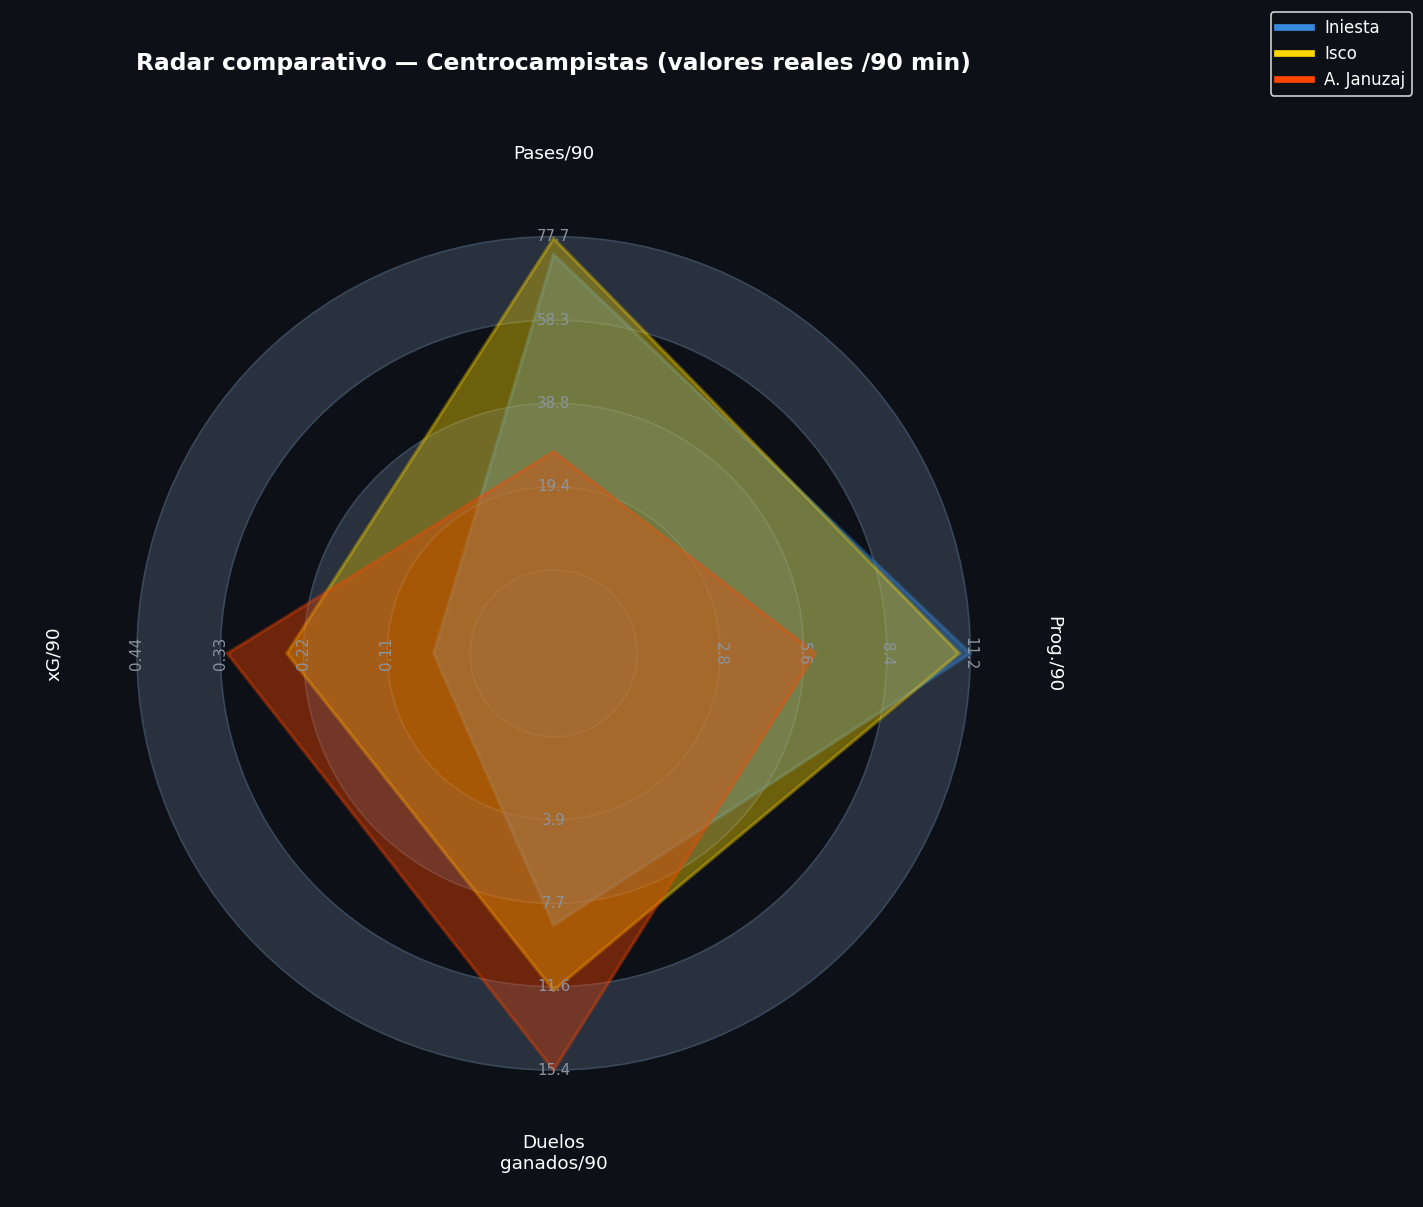

In [ ]:
# Analizaremos a 3 de los 4 jugadores que figuran en al menos 2 tops 5 de las 4 variables ajustadas por 90 minutos: 
# Iniesta, Isco y A. Januzaj. Mención especial para Raúl García que es el 4to que cumple este criterio.


def plot_radar_comparativo(rows, all_stats, nombres, colores=None):
    """
    Superpone los radares de varios jugadores en un mismo gráfico, usando
    los valores reales ajustados por 90 minutos (no percentiles). Cada eje
    tiene su propia escala, calibrada al rango real de esa métrica entre
    los centrocampistas del dataset.
    """
    params = ['passes_p90', 'progressive_passes_p90', 'duels_won_p90', 'xg_p90']
    labels = ['Pases/90', 'Prog./90', 'Duelos ganados/90', 'xG/90']
    if colores is None:
        colores = ['#378ADD', '#FFD700', '#FF4500']
   
    min_range = [0, 0, 0, 0]
    max_range = [all_stats[p].max() for p in params]
    radar = Radar(
        params=labels,
        min_range=min_range,
        max_range=max_range,
        num_rings=4, ring_width=1, center_circle_radius=1
    )
    fig, axs = radar.setup_axis()
    radar.draw_circles(ax=axs, facecolor='#28313D', edgecolor='#39485a')
    for row, nombre, color in zip(rows, nombres, colores):
   
        values = [float(row[p]) for p in params]
        radar.draw_radar(
            values, ax=axs,
            kwargs_radar={'facecolor': color, 'alpha': 0.35, 'edgecolor': color, 'linewidth': 2},
            kwargs_rings={'facecolor': color, 'alpha': 0.08}
        )
    radar.draw_range_labels(ax=axs, fontsize=9, color='#8b949e')
    radar.draw_param_labels(ax=axs, fontsize=11, color='white')
    fig.patch.set_facecolor('#0d1117')
    axs.set_facecolor('#0d1117')
    
    legend_elements = [Line2D([0], [0], color=c, lw=4, label=n) for c, n in zip(colores, nombres)]
    axs.legend(
        handles=legend_elements, loc='upper right', bbox_to_anchor=(1.3, 1.1),
        facecolor='#0d1117', edgecolor='white', labelcolor='white'
    )
    axs.set_title('Radar comparativo — Centrocampistas (valores reales /90 min)', color='white', fontsize=14, fontweight='bold', pad=25)
    plt.tight_layout()
    plt.show()

jugadores = [3353, 3563, 261127]  # Iniesta, Isco, A. Januzaj
filas = [mid[mid['playerId'] == pid].iloc[0] for pid in jugadores]
nombres = [mid[mid['playerId'] == pid]['shortName'].iloc[0] for pid in jugadores]

plot_radar_comparativo(filas, mid, nombres)

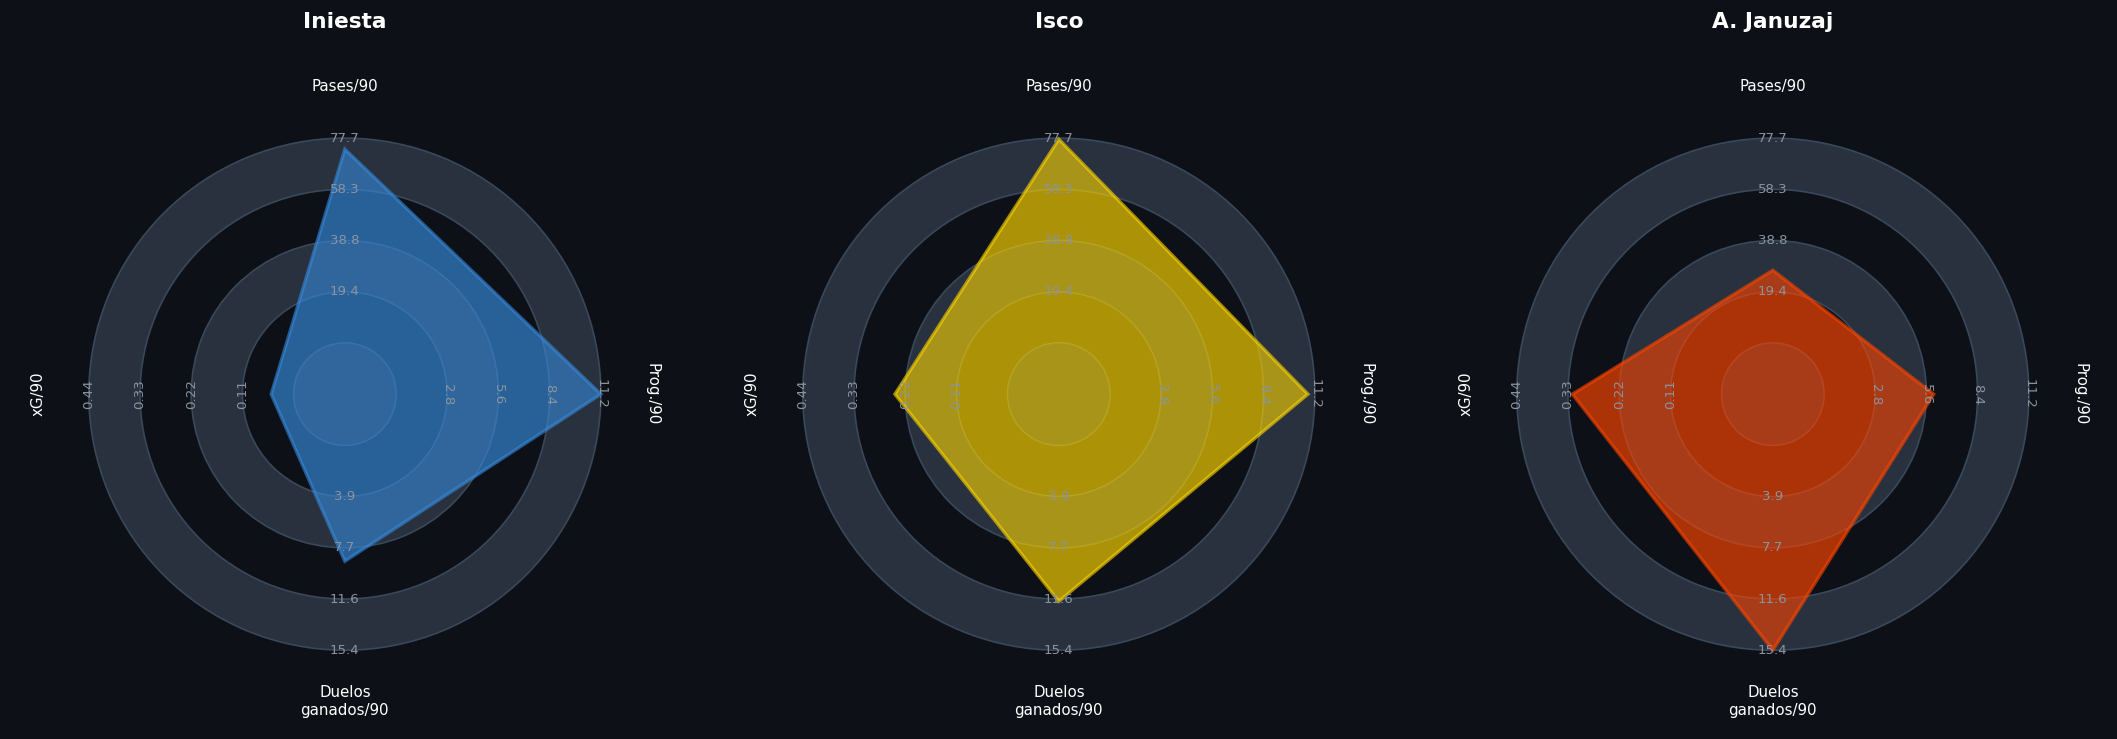

In [58]:
# Ahora graficamos los radares de manera individual, para distinguir los polígonos de manera más nítida.

def plot_radares_lado_a_lado(rows, all_stats, nombres, colores=None):
    """
    Dibuja un radar por jugador, uno al lado del otro (sin superponer), con
    valores reales ajustados por 90 minutos. Los tres comparten la misma
    escala por eje (calibrada al máximo real entre los centrocampistas),
    para que sean comparables entre sí a simple vista.
    """
    params = ['passes_p90', 'progressive_passes_p90', 'duels_won_p90', 'xg_p90']
    labels = ['Pases/90', 'Prog./90', 'Duelos ganados/90', 'xG/90']
    if colores is None:
        colores = ['#378ADD', '#FFD700', '#FF4500']

    min_range = [0, 0, 0, 0]
    max_range = [all_stats[p].max() for p in params]

    fig, axs = plt.subplots(1, len(rows), figsize=(6 * len(rows), 6))
    fig.patch.set_facecolor('#0d1117')

    for ax, row, nombre, color in zip(axs, rows, nombres, colores):
        radar = Radar(
            params=labels, min_range=min_range, max_range=max_range,
            num_rings=4, ring_width=1, center_circle_radius=1
        )
        radar.setup_axis(ax=ax)
        radar.draw_circles(ax=ax, facecolor='#28313D', edgecolor='#39485a')
        values = [float(row[p]) for p in params]
        radar.draw_radar(
            values, ax=ax,
            kwargs_radar={'facecolor': color, 'alpha': 0.6, 'edgecolor': color, 'linewidth': 2},
            kwargs_rings={'facecolor': color, 'alpha': 0.15}
        )
        radar.draw_range_labels(ax=ax, fontsize=8, color='#8b949e')
        radar.draw_param_labels(ax=ax, fontsize=9, color='white')
        ax.set_facecolor('#0d1117')
        ax.set_title(nombre, color='white', fontsize=13, fontweight='bold', pad=20)

    plt.tight_layout()
    plt.show()


plot_radares_lado_a_lado(filas, mid, nombres)

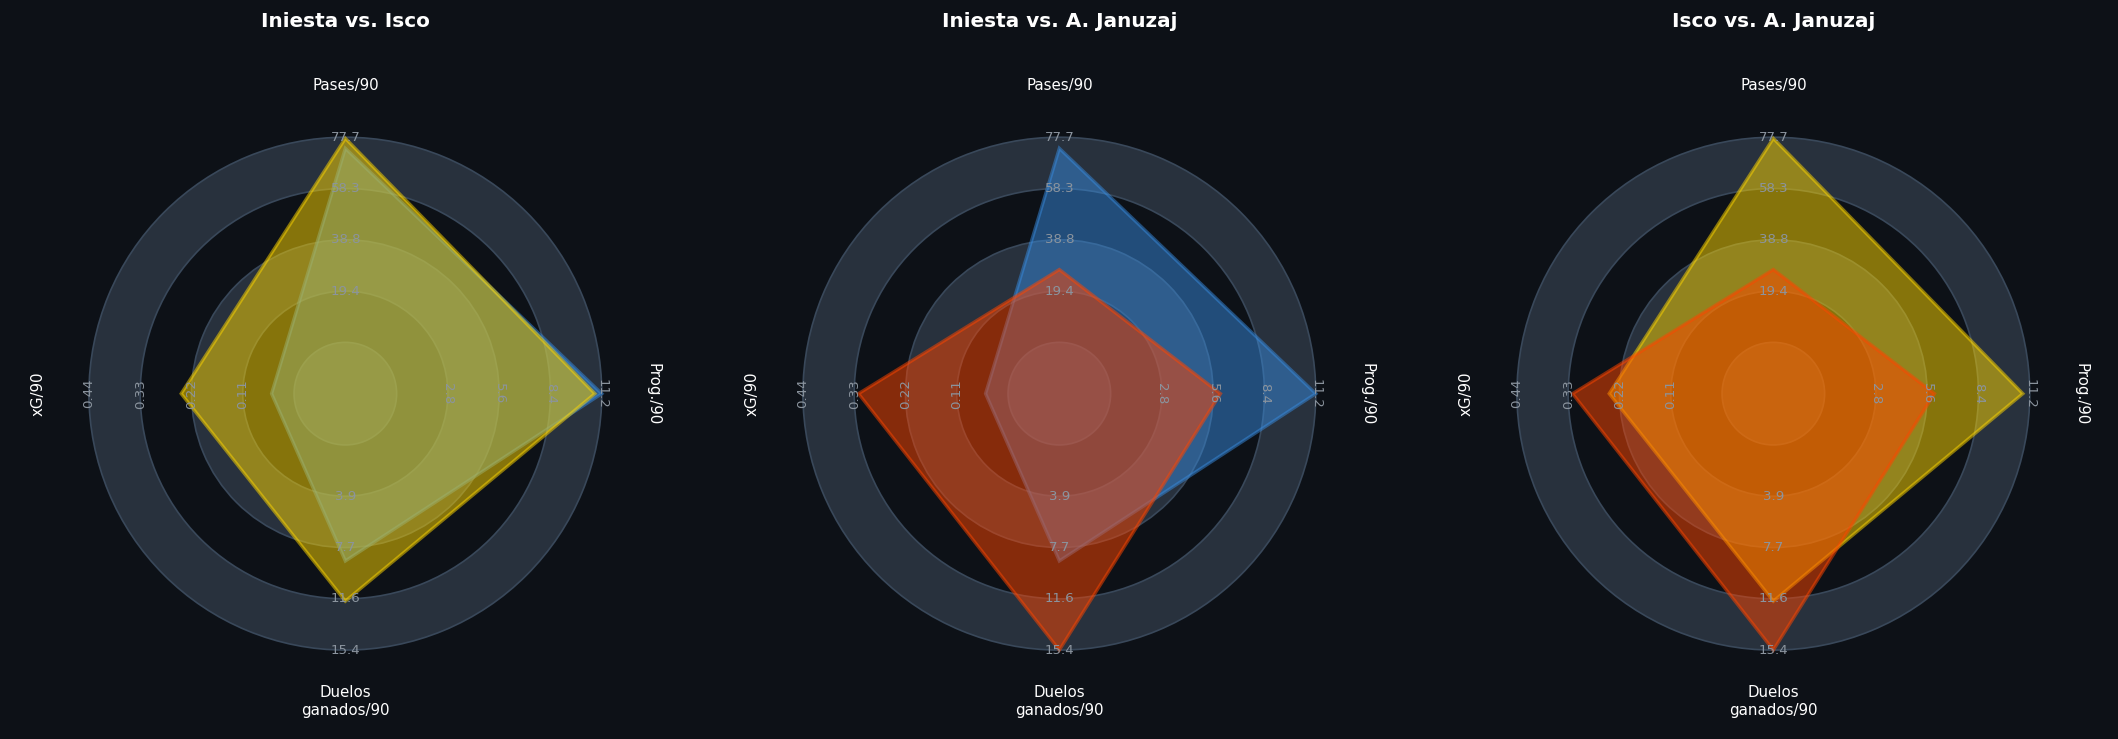

In [ ]:
# Finalmente, para presentar otra variante, comparamos y superponemos de a pares

def plot_comparaciones_pares(rows, all_stats, nombres, colores=None):
    """
    Compara a los jugadores de a pares (las 3 combinaciones posibles entre
    Iniesta/Isco/Januzaj), usando draw_radar_compare de mplsoccer — cada
    par se dibuja en su propio subplot con los dos polígonos superpuestos.
    """
    params = ['passes_p90', 'progressive_passes_p90', 'duels_won_p90', 'xg_p90']
    labels = ['Pases/90', 'Prog./90', 'Duelos ganados/90', 'xG/90']
    if colores is None:
        colores = ['#378ADD', '#FFD700', '#FF4500']

    min_range = [0, 0, 0, 0]
    max_range = [all_stats[p].max() for p in params]

    pares = list(combinations(range(len(rows)), 2))
    fig, axs = plt.subplots(1, len(pares), figsize=(6 * len(pares), 6))
    fig.patch.set_facecolor('#0d1117')
    if len(pares) == 1:
        axs = [axs]

    for ax, (i, j) in zip(axs, pares):
        radar = Radar(
            params=labels, min_range=min_range, max_range=max_range,
            num_rings=4, ring_width=1, center_circle_radius=1
        )
        radar.setup_axis(ax=ax)
        radar.draw_circles(ax=ax, facecolor='#28313D', edgecolor='#39485a')
        values_i = [float(rows[i][p]) for p in params]
        values_j = [float(rows[j][p]) for p in params]
        radar.draw_radar_compare(
            values_i, values_j, ax=ax,
            kwargs_radar={'facecolor': colores[i], 'alpha': 0.5, 'edgecolor': colores[i], 'linewidth': 2},
            kwargs_compare={'facecolor': colores[j], 'alpha': 0.5, 'edgecolor': colores[j], 'linewidth': 2}
        )
        radar.draw_range_labels(ax=ax, fontsize=8, color='#8b949e')
        radar.draw_param_labels(ax=ax, fontsize=9, color='white')
        ax.set_facecolor('#0d1117')
        ax.set_title(f'{nombres[i]} vs. {nombres[j]}', color='white', fontsize=12, fontweight='bold', pad=20)

    plt.tight_layout()
    plt.show()


plot_comparaciones_pares(filas, mid, nombres)

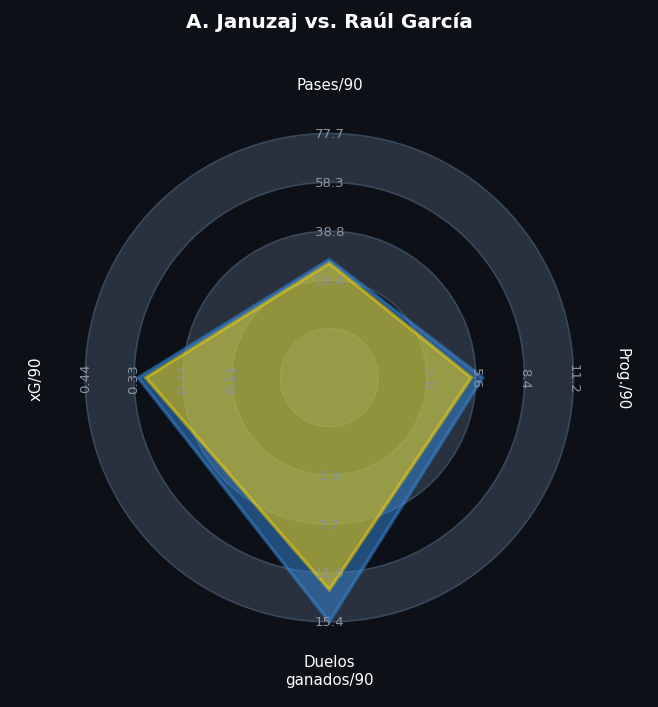

In [60]:
# Comparamos a Raúl García, de curisidad no más. 
jugadores_2 = [261127, 3503]  # A. Januzaj, Raúl García
filas_2 = [mid[mid['playerId'] == pid].iloc[0] for pid in jugadores_2]
nombres_2 = [mid[mid['playerId'] == pid]['shortName'].iloc[0] for pid in jugadores_2]

plot_comparaciones_pares(filas_2, mid, nombres_2)

#### Conclusiones Ej 4.


El gráfico radar es un elemento visual clave en el análisis y comparación de jugadores mediante sus principales estadísticas. Desde los primeros Winning Eleven o PES, nos acostumbramos a ver el radar para armar los equipos y realizar los cambios durante el partido.

En este ejercicio, comparamos 3 mediocampistas de La Liga en 4 variables clave: xG, Pases, Pases progresivos y Duelos ganados, todas ajustadas por 90 minutos. El mínimo de minutos jugados para ser comparables es de 500. Para elegir, se tomó como criterio general, seleccionar jugadores que se destaquen en más de 1 categoría, y por ello armamos la tabla de top5 de acuerdo a cada una variables. A partir de ello, se seleccionó a Iniesta (Pases y pases progresivos), A. Januzaj (Duelos ganados y xG) y a Isco (Destaca en pases, pases progresivos sobretodo, pero se encuentra por encima del percentil 90% de cada una de las variables analizadas, algo notable). Como se mencionó en el comentario, Raúl García es el otro jugador que cumplía el criterio de ser top en 2 variables, pero lamentablemente quedo afuera (de todas maneras, hicimos una breve comparación con Januzaj). 

Los radares marcan que Isco es el mediocampista más completo de los 3, en términos de las estadísticas analizadas. Dentro del estilo Mediocampista creativo o constructor de juego, presenta pases y pases progresivos similares a los de Iniesta  (77.3 vs 73.5 en pases cada 90 minutos y 10.8 vs 11.2 pases	progresivos cada 90 minutos), sin embargo destaca por encima de Andrés en Goles esperados (0.24 vs 0.05, respectivamente) y en Duelos ganados (11.8 vs 8.7, respectivamente). Isco podría caracterizarse como un mediocampista muy completo, todoterreno. 
Por su parte, Januzaj destaca en Duelos ganados, por encima de Isco y en Goles esperados también por encima de Isco, sin destacar tanto en la faceta creativa (pases), pero siendo determinante en los goles esperados. Hicimos la comparación con Raúl García que también presentaba similitudes con Januzaj, y efectivamente son comparables aunque Raúl García se destaca más por sus goles de cabeza. 

En general, Isco se destaca por ser un jugador todoterreno, incluso por encima de Iniesta (en términos de las variables analizadas), mientras que Januzaj destaca más por los duelosg ganados y su cercanía al gol. Iniesta podría caracterizarse como un volante netamente creativo, Januzaj por los duelos ganados y sus capacidad para generar oportunidades de gol e Isco es el más completo de los 3. 

### Ejercicio 5 — Análisis de pressing
El pressing puede medirse como la densidad de recuperaciones de balón en campo rival.
Construí un heat map de recuperaciones (ball recoveries) para identificar qué equipos
presionan más alto. Usá el tag de 'Ball lost' en el campo rival.



**Resolución.** Medimos el pressing como la densidad de **recuperaciones de balón en campo
rival**. Una recuperación se define como un duelo ganado por el equipo (tag `703 = won`
en Wyscout), y consideramos "campo rival" a la zona `x > 50` en coordenadas Opta
(x=100 es el arco rival). El porcentaje de recuperaciones en `x > 50` sobre el total
funciona como índice de *altura* del pressing: cuanto mayor, más arriba recupera el equipo.

Analizamos primero a los 20 equipos en conjunto (visión cuantitativa) y luego el patrón
espacial de tres equipos representativos (arriba / mitad / fondo de tabla).

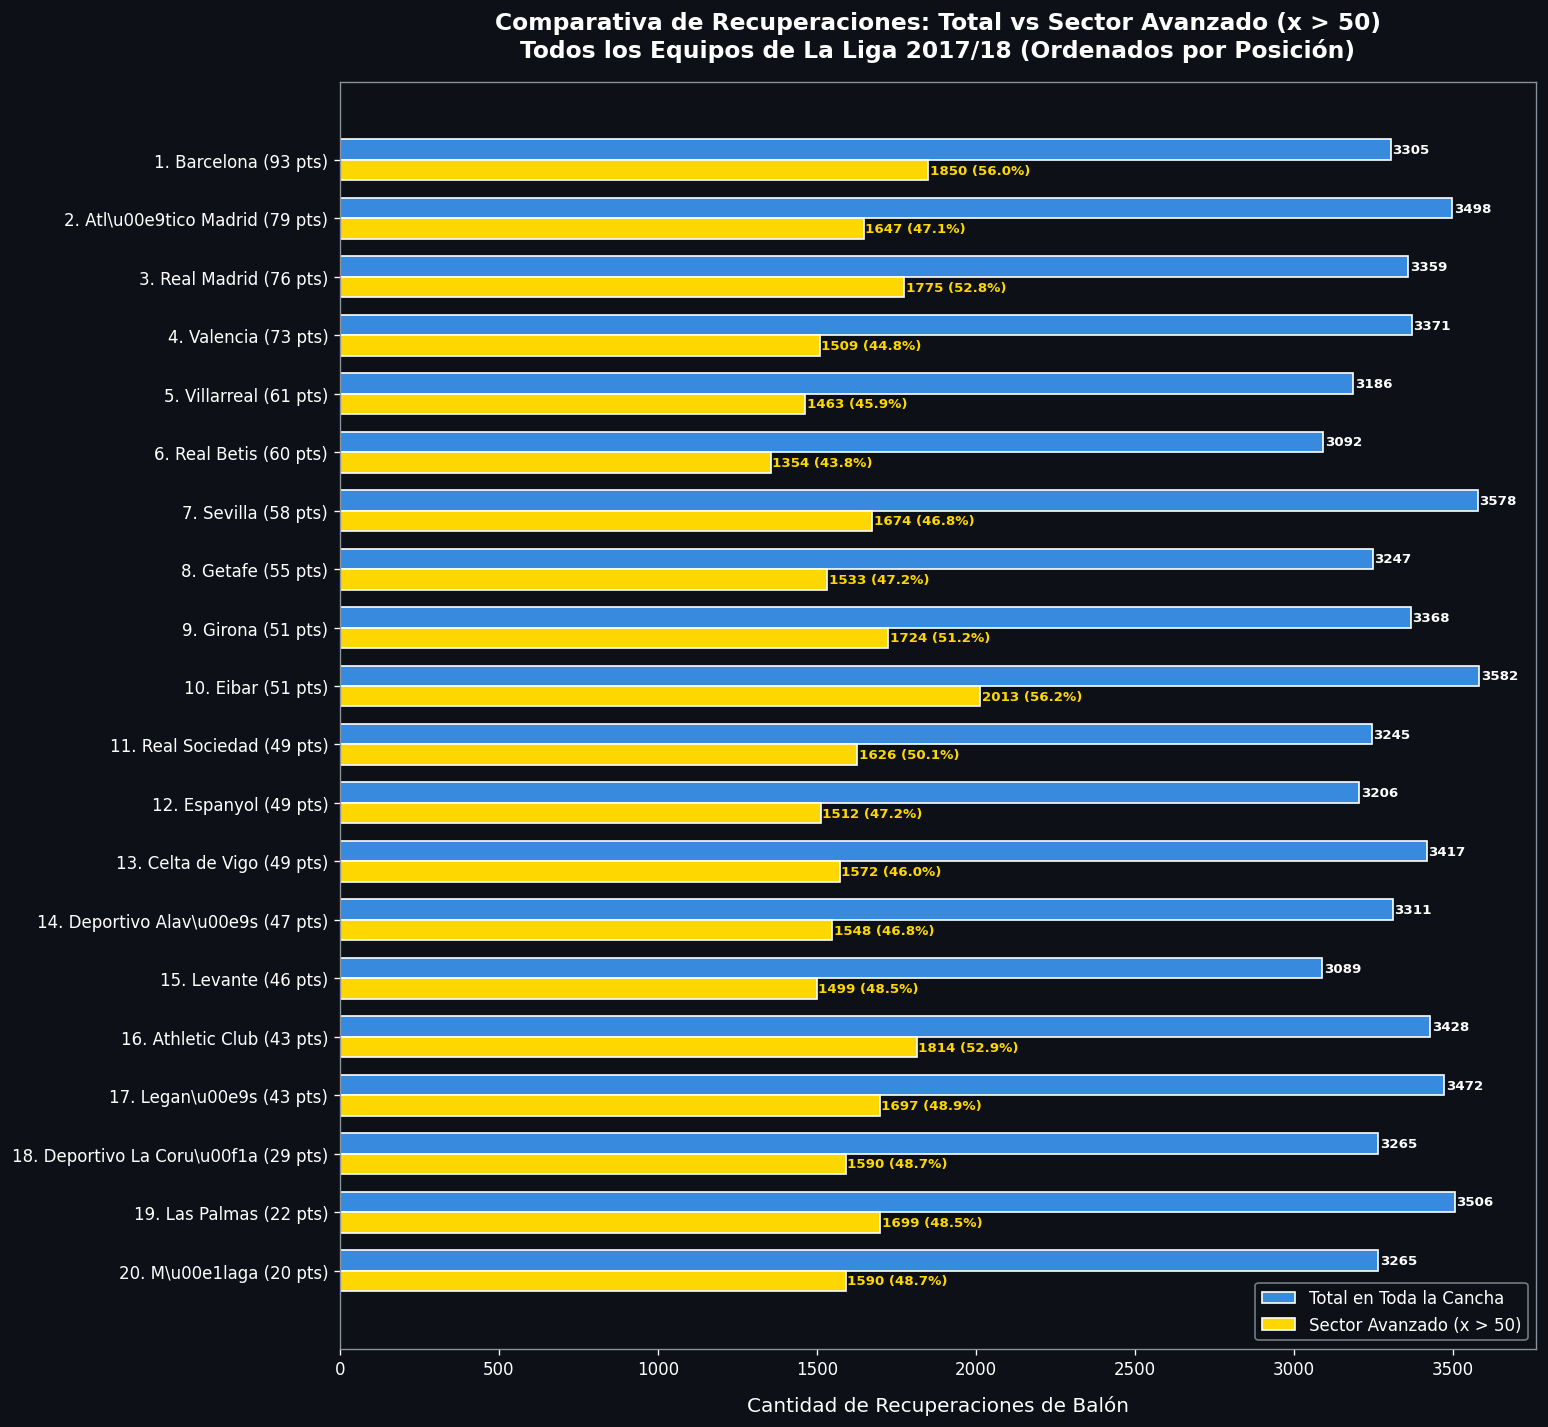

In [ ]:
points_dict = {}

for idx, row in df_matches.iterrows():
   teams_data = row['teamsData']
   t_ids = list(teams_data.keys())
   t1, t2 = int(t_ids[0]), int(t_ids[1])
   s1 = int(teams_data[str(t1)]['score'])
   s2 = int(teams_data[str(t2)]['score'])


   if t1 not in points_dict: points_dict[t1] = 0
   if t2 not in points_dict: points_dict[t2] = 0


   if s1 > s2:
       points_dict[t1] += 3
   elif s2 > s1:
       points_dict[t2] += 3
   else:
       points_dict[t1] += 1
       points_dict[t2] += 1

## Para correr en colab:
# with open('data/teams.json') as f:
#    teams_meta = json.load(f)

with open('../data/teams.json') as f:
   teams_meta = json.load(f)
team_map = {t['wyId']: t['name'] for t in teams_meta}

# 2. Filtrar recuperaciones en toda la cancha y en campo rival
TAG_WON = 703

df_all_pressing = df_events[
   df_events['tag_ids'].apply(lambda tags: TAG_WON in tags)
].copy()

total_rec_counts = df_all_pressing['teamId'].value_counts()
high_rec_counts = df_all_pressing[df_all_pressing['x'] > 50]['teamId'].value_counts()

table_data = []
for tid, pts in points_dict.items():
   if tid in team_map:
       total = total_rec_counts.get(tid, 0)
       high = high_rec_counts.get(tid, 0)
       pct = (high / total * 100) if total > 0 else 0
       table_data.append({
           'teamId': tid,
           'team_name': team_map[tid],
           'points': pts,
           'total_recoveries': total,
           'high_recoveries': high,
           'pct_high': pct
       })

df_league_pressing = pd.DataFrame(table_data)
df_league_pressing = df_league_pressing.sort_values(by='points', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 12), facecolor='#0d1117')
ax.set_facecolor('#0d1117')

y_labels = [f"{i+1}. {row['team_name']} ({row['points']} pts)" for i, row in df_league_pressing.iterrows()]
y_positions = np.array(list(reversed(range(len(df_league_pressing)))), dtype=float)

bar_height = 0.35


# Barra 1: Total de Recuperaciones (Azul)
bars_total = ax.barh(y_positions + bar_height/2, df_league_pressing['total_recoveries'],
                    height=bar_height, color='#378ADD', edgecolor='white', label='Total en Toda la Cancha')


# Barra 2: Sector Avanzado x > 50 (Dorado)
bars_high = ax.barh(y_positions - bar_height/2, df_league_pressing['high_recoveries'],
                   height=bar_height, color='#FFD700', edgecolor='white', label='Sector Avanzado (x > 50)')

for bar in bars_total:
   width = bar.get_width()
   ax.text(width + 5, bar.get_y() + bar.get_height()/2, f"{int(width)}",
           ha='left', va='center', color='white', fontsize=8, fontweight='bold')


for bar, pct in zip(bars_high, df_league_pressing['pct_high']):
   width = bar.get_width()
   ax.text(width + 5, bar.get_y() + bar.get_height()/2, f"{int(width)} ({pct:.1f}%)",
           ha='left', va='center', color='#FFD700', fontsize=8, fontweight='bold')


ax.set_yticks(y_positions)
ax.set_yticklabels(y_labels, color='white', fontsize=10)
ax.tick_params(colors='white')
ax.set_xlabel('Cantidad de Recuperaciones de Balón', color='white', fontsize=12, labelpad=10)
ax.set_title('Comparativa de Recuperaciones: Total vs Sector Avanzado (x > 50)\nTodos los Equipos de La Liga 2017/18 (Ordenados por Posición)',
            color='white', fontsize=14, fontweight='bold', pad=15)


ax.legend(facecolor='#0d1117', edgecolor='#8b949e', labelcolor='white', loc='lower right', fontsize=10)


for spine in ax.spines.values():
   spine.set_color('#8b949e')


plt.tight_layout()
plt.show()

El gráfico ordena a los 20 equipos por posición final y compara, para cada uno, el total
de recuperaciones (azul) contra las del sector avanzado x > 50 (dorado, con su %).
Sirve para ver si "recuperar más alto" acompaña o no a estar más arriba en la tabla.

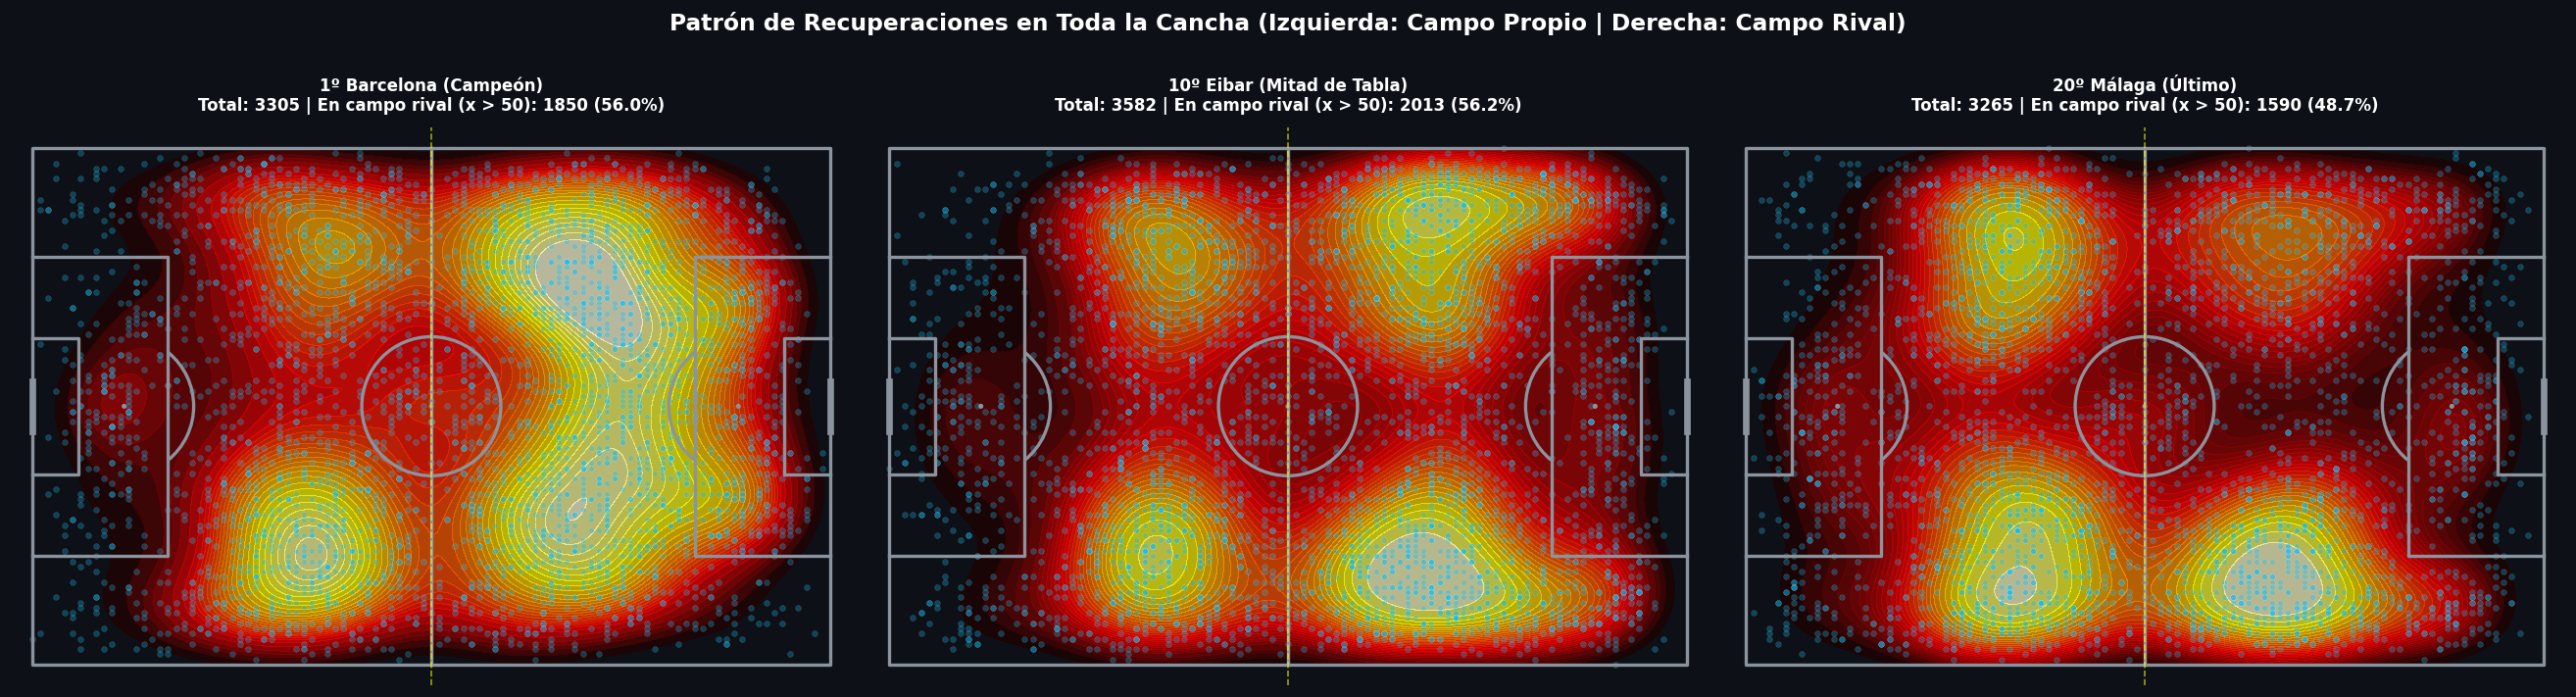

In [64]:
TAG_WON = 703

df_pressing = df_events[
   df_events['tag_ids'].apply(lambda tags: TAG_WON in tags)
].copy()


# Mapeo de los 3 equipos (1º Barcelona, 9º Eibar y 20º Málaga)
team_names = {
   676: "1º Barcelona (Campeón)",
   701: "10º Eibar (Mitad de Tabla)",
   683: "20º Málaga (Último)"
}

df_pressing_3 = df_pressing[df_pressing['teamId'].isin(team_names.keys())].copy()
df_pressing_3['team_name'] = df_pressing_3['teamId'].map(team_names)

equipos = [
   "1º Barcelona (Campeón)",
   "10º Eibar (Mitad de Tabla)",
   "20º Málaga (Último)"
]

fig, axes = plt.subplots(1, 3, figsize=(22, 6), facecolor='#0d1117')

pitch = Pitch(
   pitch_type='opta',
   pitch_color='#0d1117',
   line_color='#8b949e',
   half=False,   # Cancha completa horizontal
   line_zorder=2
)

for ax, team_name in zip(axes, equipos):
   pitch.draw(ax=ax)
   df_team = df_pressing_3[df_pressing_3['team_name'] == team_name]
  
   pitch.kdeplot(
       df_team['x'], df_team['y'],
       ax=ax,
       cmap='hot',
       fill=True,
       thresh=0.05,
       n_levels=30,
       alpha=0.7
   )
  
   pitch.scatter(
       df_team['x'], df_team['y'],
       s=12, c='#00BFFF', alpha=0.3, edgecolors='white', linewidth=0.2, ax=ax
   )
  
   # Línea vertical de mitad de campo (x = 50)
   ax.axvline(x=50, color='yellow', linestyle='--', linewidth=1.0, alpha=0.6)
  
   en_campo_rival = (df_team['x'] > 50).sum()
   pct_pressing = (en_campo_rival / len(df_team)) * 100
  
   ax.set_title(
       f"{team_name}\nTotal: {len(df_team)} | En campo rival (x > 50): {en_campo_rival} ({pct_pressing:.1f}%)",
       color='white', fontsize=10, fontweight='bold', pad=10
   )

plt.suptitle('Patrón de Recuperaciones en Toda la Cancha (Izquierda: Campo Propio | Derecha: Campo Rival)',
            color='white', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

Para ver el pressing alto en detalle, hacemos zoom al campo rival (x > 50) de tres
equipos representativos: el campeón, uno de mitad de tabla y el último.

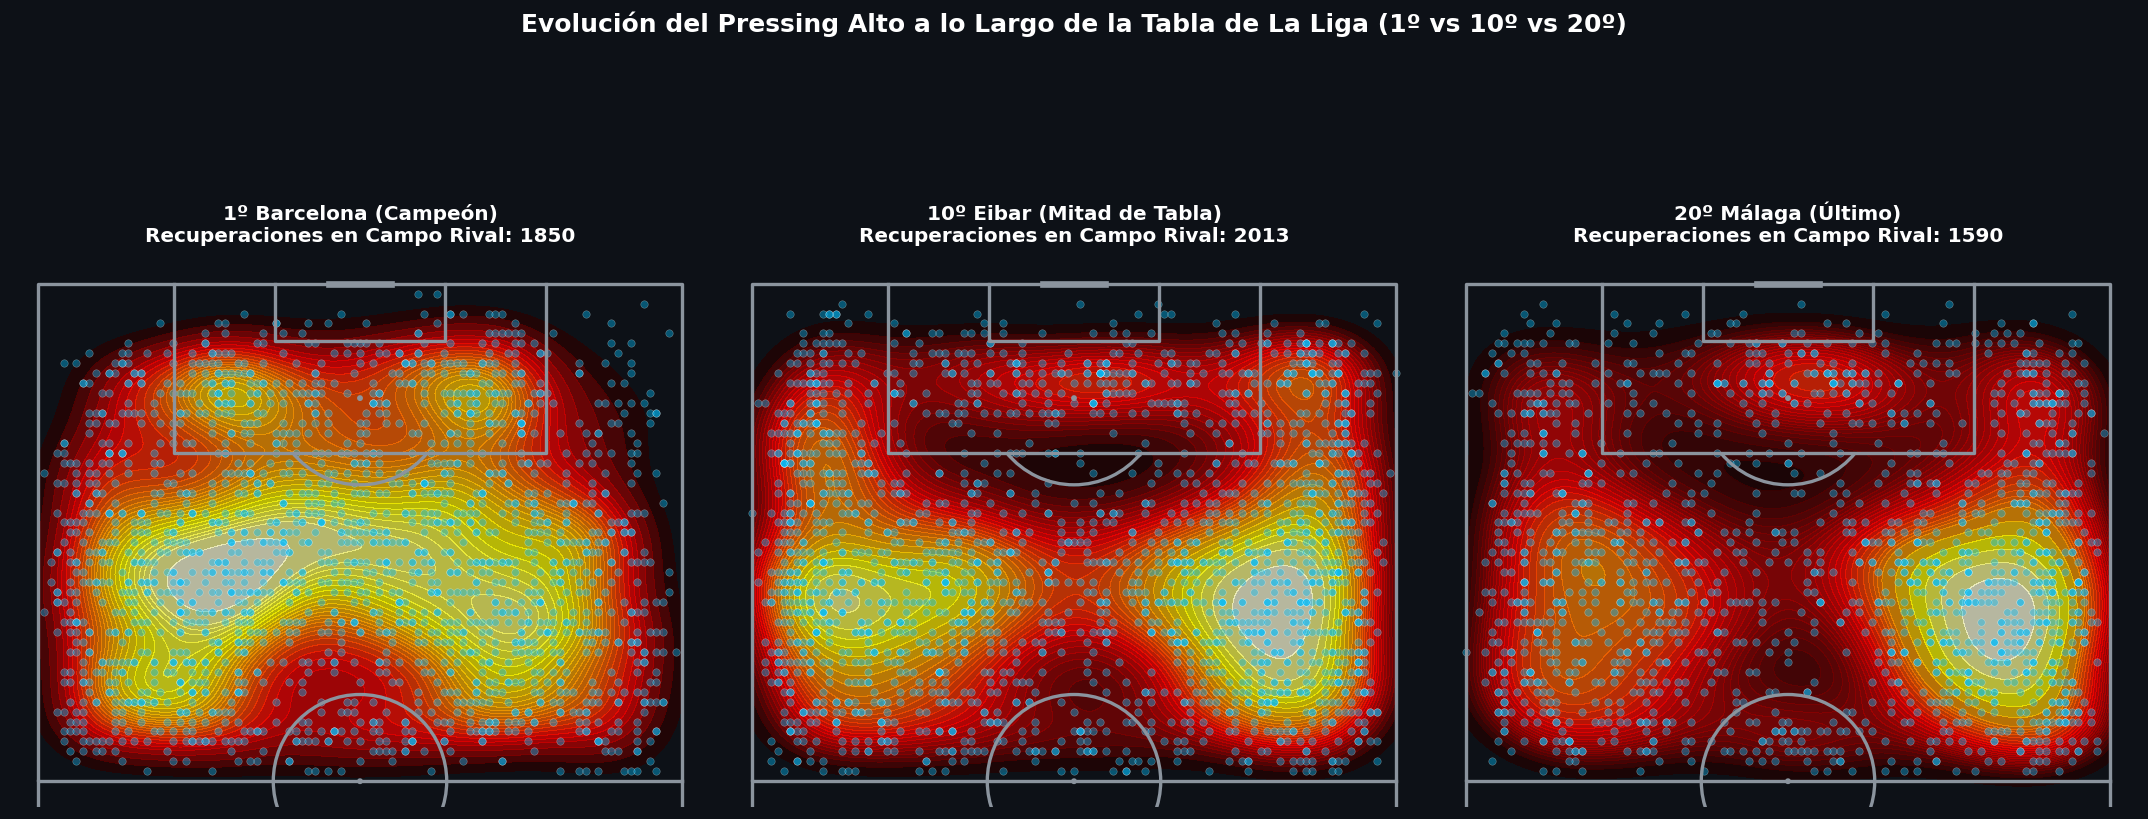

In [65]:
TAG_WON = 703

# Filtramos recuperaciones en campo rival (x > 50)
df_pressing = df_events[
   (df_events['x'] > 50) &
   (df_events['tag_ids'].apply(lambda tags: TAG_WON in tags))
].copy()

team_names = {
   676: "1º Barcelona (Campeón)",
   701: "10º Eibar (Mitad de Tabla)",
   683: "20º Málaga (Último)"
}

df_pressing_3 = df_pressing[df_pressing['teamId'].isin(team_names.keys())].copy()
df_pressing_3['team_name'] = df_pressing_3['teamId'].map(team_names)

equipos = [
   "1º Barcelona (Campeón)",
   "10º Eibar (Mitad de Tabla)",
   "20º Málaga (Último)"
]


fig, axes = plt.subplots(1, 3, figsize=(18, 8), facecolor='#0d1117')


pitch = VerticalPitch(
   pitch_type='opta',
   pitch_color='#0d1117',
   line_color='#8b949e',
   half=True,    # Muestra medio campo rival (x > 50)
   line_zorder=2
)

for ax, team_name in zip(axes, equipos):
   pitch.draw(ax=ax)
   df_team = df_pressing_3[df_pressing_3['team_name'] == team_name]
  
   pitch.kdeplot(
       df_team['x'], df_team['y'],
       ax=ax,
       cmap='hot',
       fill=True,
       thresh=0.05,
       n_levels=30,
       alpha=0.7
   )
  
   pitch.scatter(
       df_team['x'], df_team['y'],
       s=20, c='#00BFFF', alpha=0.4, edgecolors='white', linewidth=0.3, ax=ax
   )
  
   ax.set_title(
       f"{team_name}\nRecuperaciones en Campo Rival: {len(df_team)}",
       color='white', fontsize=12, fontweight='bold', pad=10
   )

plt.suptitle('Evolución del Pressing Alto a lo Largo de la Tabla de La Liga (1º vs 10º vs 20º)',
            color='white', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### Conclusiones

- **Presionar alto no depende de la posición en la tabla.** Barcelona (56,0 %) y Eibar
  (56,2 %) recuperan la pelota igual de arriba, aunque uno salió campeón y el otro quedó
  a mitad de tabla.

- **Todos los equipos recuperan una cantidad parecida** (entre ~3090 y ~3580). Lo que
  cambia no es *cuánto*, sino *dónde*: el pressing es una cuestión de estilo, no de nivel.

- **La altura del pressing (% en campo rival) es lo que separa perfiles.** Va de 43,8 %
  (Betis, recupera atrás) a 56,2 % (Eibar, recupera arriba).

- **Los heatmaps confirman los estilos:** Barça reparte recuperaciones por todo el campo
  con foco alto, Eibar muestra dos zonas intensas (defiende y presiona arriba), y los
  equipos de bloque bajo concentran en su propia mitad.

- **El heatmap muestra la forma, no la cantidad** (es densidad normalizada por equipo).
  Para comparar volumen se usa el gráfico de barras.


---
**Criterios de evaluación**: calidad visual, correctitud del análisis, insights relevantes y comentarios en el código.